# Análise Preditiva de Risco Educacional: Programa PEDE - Passos Mágicos

## Resumo Executivo
Este estudo desenvolve um modelo preditivo para identificação precoce de alunos em risco de defasagem escolar no contexto do programa PEDE (Programa de Educação e Desenvolvimento) da Associação Passos Mágicos. Utilizando técnicas de machine learning com rigor científico, analisamos dados longitudinais de 1.156 alunos (2020-2024) para construir um sistema automatizado de detecção de risco educacional.

## Objetivos de Pesquisa
**Objetivo Geral:** Desenvolver um modelo preditivo robusto e interpretável para identificação precoce de alunos em risco de defasagem escolar.

**Objetivos Específicos:**
- Analisar padrões longitudinais nos indicadores educacionais e psicossociais dos beneficiários
- Identificar variáveis preditivas mais relevantes através de análise estatística multivariada
- Desenvolver algoritmo de classificação otimizado evitando viés demográfico
- Validar modelo através de métricas robustas de performance e interpretabilidade
- Propor sistema de intervenção escalonada baseado em evidências

## Metodologia Científica
- **Desenho:** Estudo observacional longitudinal retrospectivo
- **População:** Beneficiários do programa PEDE (N=1.156)
- **Período:** 2020-2024 (4 anos de acompanhamento)
- **Variável-resposta:** Risco de defasagem (DEFASAGEM ≤ -1)
- **Técnicas:** Gradient Boosting, Random Forest, Regressão Logística com validação cruzada
- **Framework ético:** Dados anonimizados, protocolo de não identificação individual

---
# Preparação dos Dados e Criação do Modelo
---

## Importação de Bibliotecas

In [73]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# Persistência
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Carregamento dos Dados

### Descrição da Base de Dados
O dataset contém informações longitudinais dos beneficiários do programa PEDE em três períodos (2022, 2023, 2024), incluindo:

- **Dados acadêmicos:** Notas em Português, Matemática e Inglês
- **Indicadores psicossociais:** IAA, IEG, IPS, IDA, IPV, IAN, IPP
- **Variáveis temporais:** Tempo no programa, número de avaliações
- **Classificações pedagógicas:** Sistema de pedras preciosas
- **Variável-resposta:** Defasagem acadêmica (target)

### Considerações Metodológicas
- **Proteção de dados:** Todos os nomes foram anonimizados na fonte
- **Integridade longitudinal:** Matching por identificador anônimo preservando histórico
- **Qualidade dos dados:** Verificação de consistência temporal e validação de ranges

In [74]:
caminho_base = r'Bases\\BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

# Carrega as 3 abas
df_2022 = pd.read_excel(caminho_base, sheet_name='PEDE2022')
df_2023 = pd.read_excel(caminho_base, sheet_name='PEDE2023')
df_2024 = pd.read_excel(caminho_base, sheet_name='PEDE2024')

from IPython.display import display, Markdown

def exibir_tabela_secao(titulo, tabela):
    print(f"\n================================================================================\n{titulo}\n================================================================================\n")
    print(tabela)

resumo_bases = pd.DataFrame({
    'Base': ['PEDE2022', 'PEDE2023', 'PEDE2024'],
    'Registros': [len(df_2022), len(df_2023), len(df_2024)],
    'Colunas': [df_2022.shape[1], df_2023.shape[1], df_2024.shape[1]]
})

exibir_tabela_secao('Caracterização Inicial das Bases', resumo_bases)


Caracterização Inicial das Bases

       Base  Registros  Colunas
0  PEDE2022        860       42
1  PEDE2023       1014       48
2  PEDE2024       1156       50


## Exploração Inicial dos Dados

In [75]:
# Sample dos dados de 2024
df_2024.head()


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,8.666667,6.26,5.625,NaN,8.0,10.0,6.0,NaN,NaN,NaN,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.333333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.083333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,Pública,NaN,NaN,NaN,Topázio,NaN,8.63895,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,8.002,9.750000,3.76,6.875,NaN,7.0,8.0,6.0,NaN,NaN,NaN,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,9.002,4.166667,3.76,5.000,NaN,7.5,8.0,7.0,NaN,NaN,NaN,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


## Padronização e Junção das Bases

In [76]:
# Padronizar nome da coluna de identificação
df_2022 = df_2022.rename(columns={'Nome': 'NOME'})
df_2023 = df_2023.rename(columns={'Nome Anonimizado': 'NOME'})
df_2024 = df_2024.rename(columns={'Nome Anonimizado': 'NOME'})

In [77]:
# Selecionar e renomear colunas de 2024 (base principal com target)
df_2024_pad = df_2024[['NOME', 'Idade', 'Gênero', 'Nº Av', 'Mat', 'Por', 'Ing', 'Defasagem', 'Ano ingresso']].copy()
df_2024_pad = df_2024_pad.rename(columns={
    'Idade': 'IDADE',
    'Gênero': 'GENERO',
    'Nº Av': 'NUM_AVALIACOES',
    'Mat': 'NOTA_MAT',
    'Por': 'NOTA_PORT',
    'Ing': 'NOTA_ING',
    'Defasagem': 'DEFASAGEM',
    'Ano ingresso': 'ANO_INGRESSO'
})

# Calcular tempo no programa
df_2024_pad['TEMPO_PROGRAMA'] = 2024 - df_2024_pad['ANO_INGRESSO']

resumo_2024_pad = pd.DataFrame({
    'Indicador': ['Dimensão da base', 'Número de colunas padronizadas'],
    'Valor': [str(df_2024_pad.shape), len(df_2024_pad.columns)]
})
colunas_2024_pad = pd.DataFrame({'Colunas padronizadas': list(df_2024_pad.columns)})

exibir_tabela_secao('Base 2024 Padronizada', resumo_2024_pad)
exibir_tabela_secao('Esquema de Variáveis da Base 2024', colunas_2024_pad)
print(df_2024_pad.head())


Base 2024 Padronizada

                        Indicador       Valor
0                Dimensão da base  (1156, 10)
1  Número de colunas padronizadas          10

Esquema de Variáveis da Base 2024

  Colunas padronizadas
0                 NOME
1                IDADE
2               GENERO
3       NUM_AVALIACOES
4             NOTA_MAT
5            NOTA_PORT
6             NOTA_ING
7            DEFASAGEM
8         ANO_INGRESSO
9       TEMPO_PROGRAMA
         NOME  IDADE     GENERO  NUM_AVALIACOES  NOTA_MAT  NOTA_PORT  \
0  Aluno-1275      8  Masculino               3      10.0        6.0   
1  Aluno-1276      8   Feminino               3      10.0        6.0   
2  Aluno-1277      8  Masculino               3      10.0        6.0   
3   Aluno-868      8  Masculino               3       8.0        6.0   
4  Aluno-1278      9  Masculino               3       8.0        7.0   

   NOTA_ING  DEFASAGEM  ANO_INGRESSO  TEMPO_PROGRAMA  
0       NaN          0          2024               0  
1     

In [78]:
# Selecionar indicadores históricos de 2022
df_hist_2022 = df_2022[['NOME', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Pedra 22']].copy()
df_hist_2022 = df_hist_2022.rename(columns={
    'IAA': 'IAA_2022',
    'IEG': 'IEG_2022',
    'IPS': 'IPS_2022',
    'IDA': 'IDA_2022',
    'IPV': 'IPV_2022',
    'IAN': 'IAN_2022',
    'Pedra 22': 'PEDRA_2022'
})

resumo_hist_2022 = pd.DataFrame({
    'Indicador': ['Dimensão da base', 'Número de colunas históricas'],
    'Valor': [str(df_hist_2022.shape), len(df_hist_2022.columns)]
})
colunas_hist_2022 = pd.DataFrame({'Colunas históricas 2022': list(df_hist_2022.columns)})

exibir_tabela_secao('Base Histórica 2022', resumo_hist_2022)
exibir_tabela_secao('Esquema de Variáveis Históricas 2022', colunas_hist_2022)
print(df_hist_2022.head())


Base Histórica 2022

                      Indicador     Valor
0              Dimensão da base  (860, 8)
1  Número de colunas históricas         8

Esquema de Variáveis Históricas 2022

  Colunas históricas 2022
0                    NOME
1                IAA_2022
2                IEG_2022
3                IPS_2022
4                IDA_2022
5                IPV_2022
6                IAN_2022
7              PEDRA_2022
      NOME  IAA_2022  IEG_2022  IPS_2022  IDA_2022  IPV_2022  IAN_2022  \
0  Aluno-1       8.3       4.1       5.6       4.0     7.278       5.0   
1  Aluno-2       8.8       5.2       6.3       6.8     6.778      10.0   
2  Aluno-3       0.0       7.9       5.6       5.6     7.556      10.0   
3  Aluno-4       8.8       4.5       5.6       5.0     5.278      10.0   
4  Aluno-5       7.9       8.6       5.6       5.2     7.389      10.0   

  PEDRA_2022  
0    Quartzo  
1   Ametista  
2      Ágata  
3    Quartzo  
4   Ametista  


In [79]:
# Selecionar indicadores históricos de 2023
df_hist_2023 = df_2023[['NOME', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'Pedra 2023']].copy()
df_hist_2023 = df_hist_2023.rename(columns={
    'IAA': 'IAA_2023',
    'IEG': 'IEG_2023',
    'IPS': 'IPS_2023',
    'IPP': 'IPP_2023',
    'IDA': 'IDA_2023',
    'IPV': 'IPV_2023',
    'IAN': 'IAN_2023',
    'Pedra 2023': 'PEDRA_2023'
})

resumo_hist_2023 = pd.DataFrame({
    'Indicador': ['Dimensão da base', 'Número de colunas históricas'],
    'Valor': [str(df_hist_2023.shape), len(df_hist_2023.columns)]
})
colunas_hist_2023 = pd.DataFrame({'Colunas históricas 2023': list(df_hist_2023.columns)})

exibir_tabela_secao('Base Histórica 2023', resumo_hist_2023)
exibir_tabela_secao('Esquema de Variáveis Históricas 2023', colunas_hist_2023)
print(df_hist_2023.head())


Base Histórica 2023

                      Indicador      Valor
0              Dimensão da base  (1014, 9)
1  Número de colunas históricas          9

Esquema de Variáveis Históricas 2023

  Colunas históricas 2023
0                    NOME
1                IAA_2023
2                IEG_2023
3                IPS_2023
4                IPP_2023
5                IDA_2023
6                IPV_2023
7                IAN_2023
8              PEDRA_2023
        NOME  IAA_2023  IEG_2023  IPS_2023  IPP_2023  IDA_2023  IPV_2023  \
0  Aluno-861       9.5      10.0      8.13    8.4375       9.6     8.920   
1  Aluno-862       8.5       9.1      8.14    7.5000       8.9     8.585   
2  Aluno-863       0.0       7.6      3.14    5.9375       6.3     6.260   
3  Aluno-864       0.0       7.6      8.14    7.5000       6.3     8.500   
4  Aluno-865       8.5       8.7      7.52    7.5000       7.4     7.915   

   IAN_2023 PEDRA_2023  
0      10.0    Topázio  
1       5.0    Topázio  
2      10.0    Qua

### Junção das Bases por Aluno

In [80]:
# Função auxiliar para exibição de tabelas nas análises
def exibir_tabela_secao(titulo, tabela):
    """
    Exibe uma tabela com título formatado para análises.
    Parâmetros:
    - titulo: string com o título da seção
    - tabela: DataFrame ou Series com os dados
    """
    print(f"\n{'='*80}")
    print(f"{titulo}")
    print(f"{'='*80}")
    print(tabela.to_string())
    print(f"{'='*80}\n")

# Aplicar função nos resumos existentes
exibir_tabela_secao('Caracterização Inicial das Bases', resumo_bases)


Caracterização Inicial das Bases
       Base  Registros  Colunas
0  PEDE2022        860       42
1  PEDE2023       1014       48
2  PEDE2024       1156       50



In [81]:
# Fazer merge das bases históricas 2022 e 2023 com a base principal de 2024
df_merged = df_2024_pad.copy()
df_merged = df_merged.merge(df_hist_2022, on='NOME', how='left')
df_merged = df_merged.merge(df_hist_2023, on='NOME', how='left')

resumo_merged = pd.DataFrame({
    'Indicador': ['Dimensão da base unificada', 'Total de colunas após merge'],
    'Valor': [str(df_merged.shape), len(df_merged.columns)]
})

exibir_tabela_secao('Base Unificada (2024 + Históricos 2022/2023)', resumo_merged)
print(df_merged.head())


Base Unificada (2024 + Históricos 2022/2023)
                     Indicador       Valor
0   Dimensão da base unificada  (1156, 25)
1  Total de colunas após merge          25

         NOME  IDADE     GENERO  NUM_AVALIACOES  NOTA_MAT  NOTA_PORT  \
0  Aluno-1275      8  Masculino               3      10.0        6.0   
1  Aluno-1276      8   Feminino               3      10.0        6.0   
2  Aluno-1277      8  Masculino               3      10.0        6.0   
3   Aluno-868      8  Masculino               3       8.0        6.0   
4  Aluno-1278      9  Masculino               3       8.0        7.0   

   NOTA_ING  DEFASAGEM  ANO_INGRESSO  TEMPO_PROGRAMA  IAA_2022  IEG_2022  \
0       NaN          0          2024               0       NaN       NaN   
1       NaN          0          2024               0       NaN       NaN   
2       NaN          0          2024               0       NaN       NaN   
3       NaN         -1          2023               1       NaN       NaN   
4       NaN

### Engenharia de Features e Tratamento de Dados Ausentes

**Metodologia de Feature Engineering:**
- **Features derivadas acadêmicas:** Criação de média, variância, mín/máx das notas para capturar padrões de desempenho
- **Features binárias:** Indicadores de desempenho equilibrado e notas baixas baseados em distribuições empíricas
- **Features temporais:** Tempo no programa e evolução longitudinal dos indicadores
- **Target engineering:** Definição de risco baseada em defasagem ≤ -1 (fundamentação pedagógica)

**Tratamento de Dados Ausentes:**
- Estratégia de imputação forward-fill para indicadores históricos (2022→2023→2024)
- Preservação da informação temporal através de merge sequencial
- Análise de padrões de missing data (MCAR/MAR) para validação da estratégia

In [82]:
# Criar dataset limpo
df_clean = df_merged.copy()

# Criar variável target
df_clean['EM_RISCO'] = (df_clean['DEFASAGEM'] <= -1).astype(int)

# Criar features agregadas de notas
df_clean['MEDIA_NOTAS'] = df_clean[['NOTA_PORT', 'NOTA_MAT', 'NOTA_ING']].mean(axis=1)
df_clean['VARIANCIA_NOTAS'] = df_clean[['NOTA_PORT', 'NOTA_MAT', 'NOTA_ING']].var(axis=1, ddof=1)
df_clean['NOTA_MIN'] = df_clean[['NOTA_PORT', 'NOTA_MAT', 'NOTA_ING']].min(axis=1)
df_clean['NOTA_MAX'] = df_clean[['NOTA_PORT', 'NOTA_MAT', 'NOTA_ING']].max(axis=1)

# Calcular thresholds para features binárias
variancia_ddof = 1
thr_desempenho_equilibrado = float(df_clean['VARIANCIA_NOTAS'].median())
thr_notas_baixas = float(df_clean['MEDIA_NOTAS'].quantile(0.25))

df_clean['DESEMPENHO_EQUILIBRADO'] = (df_clean['VARIANCIA_NOTAS'] < thr_desempenho_equilibrado).astype(int)
df_clean['NOTAS_BAIXAS'] = (df_clean['MEDIA_NOTAS'] < thr_notas_baixas).astype(int)

# Adicionar colunas de 2024 para análises (buscar do dataset original)
cols_disponiveis = []
cols_desejadas = {
    'NOME': 'NOME',
    'Fase': 'Fase',
    'Ponto de virada': 'PONTO_VIRADA',
    'INDE': 'INDE_2022',
    'Rec Psi': 'REC_PSICO',
    'IAA': 'IAA',
    'IEG': 'IEG', 
    'IPS': 'IPS',
    'IDA': 'IDA',
    'IPV': 'IPV',
    'IAN': 'IAN'
}

for col_orig, col_novo in cols_desejadas.items():
    if col_orig in df_2024.columns:
        cols_disponiveis.append(col_orig)

if cols_disponiveis:
    df_2024_full = df_2024[cols_disponiveis].copy()
    
    # Renomear colunas
    rename_map = {k: v for k, v in cols_desejadas.items() if k in cols_disponiveis}
    df_2024_full = df_2024_full.rename(columns=rename_map)
    
    # Fazer merge para adicionar essas colunas
    merge_cols = [col for col in df_2024_full.columns if col not in df_clean.columns or col == 'NOME']
    if merge_cols:
        df_clean = df_clean.merge(df_2024_full[merge_cols], on='NOME', how='left')

# Preencher valores ausentes de indicadores com os históricos quando disponível
for col in ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']:
    if col in df_clean.columns and f'{col}_2023' in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[f'{col}_2023'])
    if col in df_clean.columns and f'{col}_2022' in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[f'{col}_2022'])

resumo_clean = pd.DataFrame({
    'Indicador': ['Dimensão do dataset limpo', 'Total de variáveis'],
    'Valor': [str(df_clean.shape), len(df_clean.columns)]
})
dist_target = df_clean['EM_RISCO'].value_counts().rename_axis('Classe').to_frame('Quantidade')

exibir_tabela_secao('Síntese do Dataset Limpo', resumo_clean)
exibir_tabela_secao('Distribuição da Variável-Resposta (EM_RISCO)', dist_target)
print(df_clean.head())


Síntese do Dataset Limpo
                   Indicador       Valor
0  Dimensão do dataset limpo  (1156, 39)
1         Total de variáveis          39


Distribuição da Variável-Resposta (EM_RISCO)
        Quantidade
Classe            
0              622
1              534

         NOME  IDADE     GENERO  NUM_AVALIACOES  NOTA_MAT  NOTA_PORT  \
0  Aluno-1275      8  Masculino               3      10.0        6.0   
1  Aluno-1276      8   Feminino               3      10.0        6.0   
2  Aluno-1277      8  Masculino               3      10.0        6.0   
3   Aluno-868      8  Masculino               3       8.0        6.0   
4  Aluno-1278      9  Masculino               3       8.0        7.0   

   NOTA_ING  DEFASAGEM  ANO_INGRESSO  TEMPO_PROGRAMA  IAA_2022  IEG_2022  \
0       NaN          0          2024               0       NaN       NaN   
1       NaN          0          2024               0       NaN       NaN   
2       NaN          0          2024               0       NaN    

## Análise de Correlação entre Variáveis

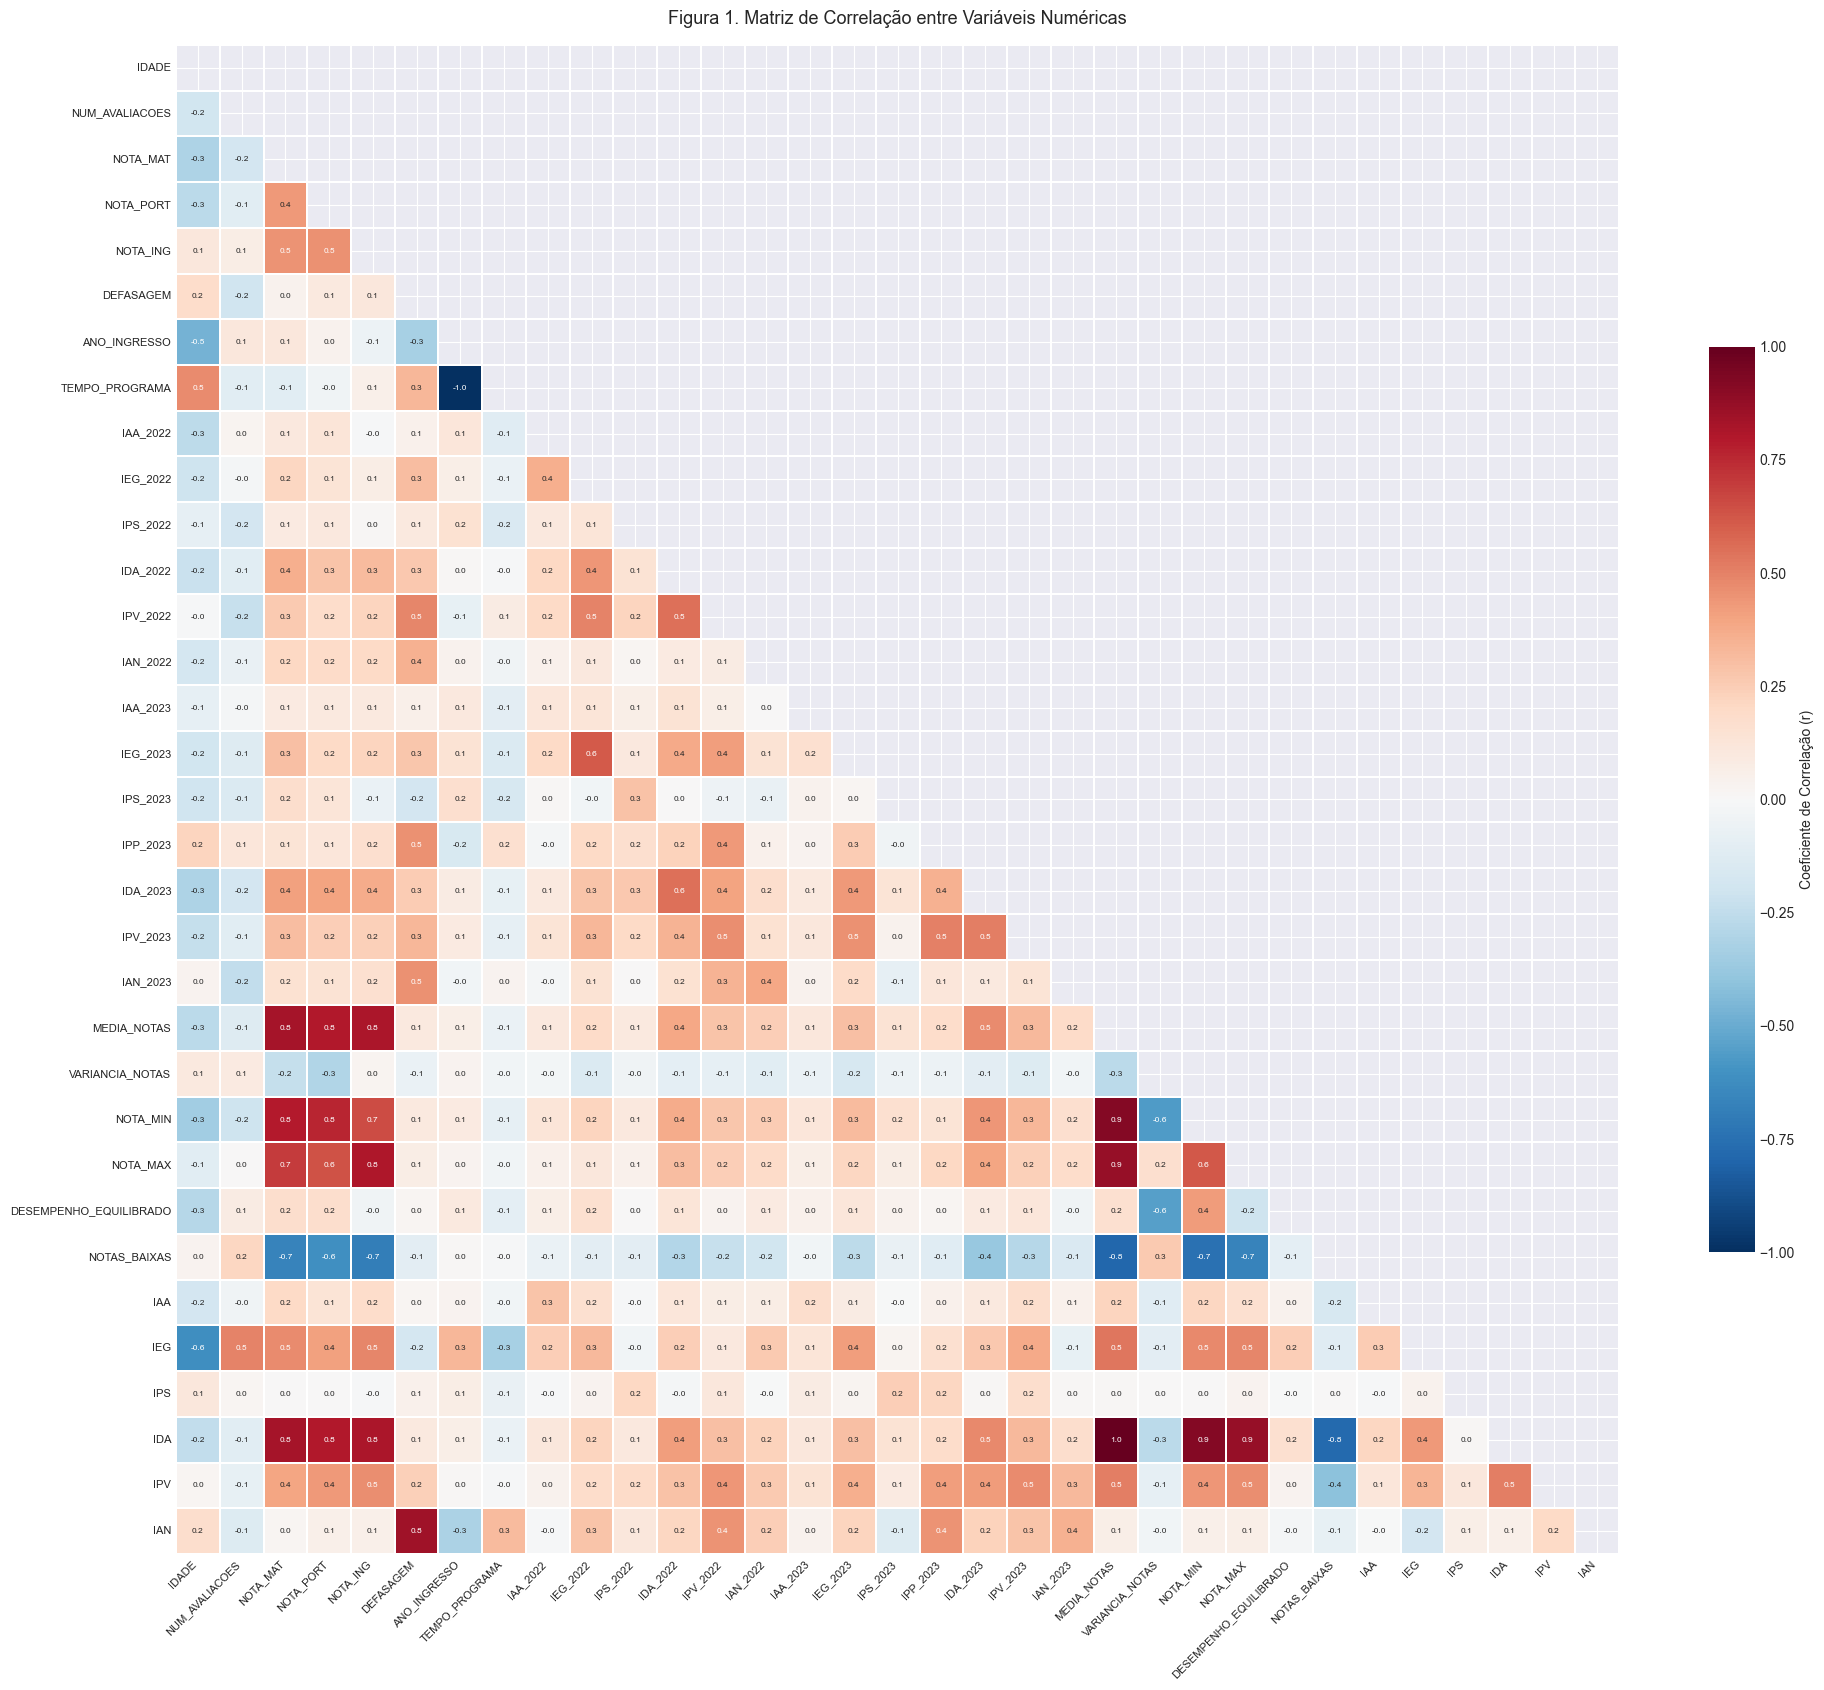

In [83]:
# Análise de correlação entre variáveis
variaveis_numericas = df_clean.select_dtypes(include=[np.number]).columns.tolist()
variaveis_numericas.remove('EM_RISCO')

correlacao_matriz = df_clean[variaveis_numericas].corr()

# Máscara para ocultar o triângulo superior (evita redundância)
mask = np.triu(np.ones_like(correlacao_matriz, dtype=bool))

# Arredondar para 1 casa para caber nos quadradinhos
annot_data = correlacao_matriz.round(1)

plt.figure(figsize=(20, 17))
sns.heatmap(
    correlacao_matriz,
    mask=mask,
    annot=annot_data,
    fmt='.1f',
    annot_kws={'size': 6},
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={"shrink": 0.6, "label": "Coeficiente de Correlação (r)"}
)
plt.title('Figura 1. Matriz de Correlação entre Variáveis Numéricas', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## Preparação de Dados para Modelagem Preditiva

### Validação de Qualidade dos Dados
Antes da modelagem, validamos sistematicamente:
- **Consistência temporal:** Verificação de ordem cronológica dos indicadores
- **Plausibilidade dos valores:** Análise de outliers e valores impossíveis
- **Balanceamento da variável target:** Análise da distribuição de classes
- **Data leakage prevention:** Garantia de que apenas dados históricos são utilizados

### Estratégia de Incorporação de Features Históricas
Com base na análise do dicionário de dados PEDE, identificamos features históricas relevantes que respeitam a temporalidade:
- **INDE 2022/2023:** Indicadores longitudinais de desenvolvimento
- **Evolução temporal:** Diferenças year-over-year para capturar tendências
- **Validação anti-leakage:** Confirmação de que dados são anteriores ao período de predição

In [84]:
# Preparar dataset final para modelo incluindo features identificadas no dicionário de dados
df_model = df_clean.copy()

# Definir coluna identificadora disponível
col_id = 'NOME' if 'NOME' in df_2024.columns else 'Nome Anonimizado'

# Adicionar features de INDE histórico do dicionário de dados (evitando data leakage)
inde_historico = {}
for col in ['INDE 22', 'INDE 23']:
    if col in df_2024.columns:
        inde_data = df_2024[[col_id, col]].rename(columns={col_id: 'NOME'})
        col_novo = col.replace(' ', '_').replace('22', '_2022').replace('23', '_2023')
        inde_data = inde_data.rename(columns={col: col_novo})
        df_model = df_model.merge(inde_data, on='NOME', how='left')
        if df_model[col_novo].notna().sum() > 200:
            inde_historico[col_novo] = df_model[col_novo].notna().sum()

# Criar feature de evolução temporal dos INDEs (dados históricos seguros)
if 'INDE_2022' in inde_historico and 'INDE_2023' in inde_historico:
    df_model['INDE_EVOLUCAO_22_23'] = df_model['INDE_2023'] - df_model['INDE_2022']
    inde_historico['INDE_EVOLUCAO_22_23'] = df_model['INDE_EVOLUCAO_22_23'].notna().sum()

# Definir features numéricas (IDADE removida para evitar viés demográfico)
features_numericas = [
    'NOTA_PORT', 'NOTA_MAT', 'NOTA_ING',
    'MEDIA_NOTAS', 'VARIANCIA_NOTAS', 'NOTA_MIN', 'NOTA_MAX',
    'TEMPO_PROGRAMA', 'NUM_AVALIACOES',
    'DESEMPENHO_EQUILIBRADO', 'NOTAS_BAIXAS',
    'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'IPV_2022', 'IAN_2022',
    'IAA_2023', 'IEG_2023', 'IPS_2023', 'IPP_2023', 'IDA_2023', 'IPV_2023', 'IAN_2023'
 ]

# Adicionar features de INDE histórico válidas
for feature_inde in inde_historico.keys():
    if feature_inde in df_model.columns:
        features_numericas.append(feature_inde)

# Features categóricas
features_categoricas = ['GENERO', 'PEDRA_2022', 'PEDRA_2023']

# Criar lista final de features
features_finais = features_numericas + features_categoricas

# Criar dataset apenas com features e target
df_ml = df_model[features_finais + ['EM_RISCO']].copy()

resumo_modelagem = pd.DataFrame({
    'Indicador': ['Dimensão do dataset de modelagem', 'Total de features'],
    'Valor': [str(df_ml.shape), len(features_finais)]
})
dist_target_ml = df_ml['EM_RISCO'].value_counts().rename_axis('Classe').to_frame('Quantidade')

exibir_tabela_secao('Síntese do Dataset para Modelagem', resumo_modelagem)
if inde_historico:
    inde_tbl = pd.DataFrame({
        'Feature histórica adicionada': list(inde_historico.keys()),
        'Registros não nulos': list(inde_historico.values())
    })
    exibir_tabela_secao('Features Históricas Incorporadas', inde_tbl)
exibir_tabela_secao('Distribuição da Variável-Resposta para Modelagem', dist_target_ml)


Síntese do Dataset para Modelagem
                          Indicador       Valor
0  Dimensão do dataset de modelagem  (1156, 30)
1                 Total de features          29


Features Históricas Incorporadas
  Feature histórica adicionada  Registros não nulos
0                   INDE__2022                  472
1                   INDE__2023                  690


Distribuição da Variável-Resposta para Modelagem
        Quantidade
Classe            
0              622
1              534



In [85]:
# Codificação categórica será realizada após a divisão treino-teste para evitar dupla transformação
le_dict = {}

In [86]:
# Separar features e target
X = df_ml[features_finais]
y = df_ml['EM_RISCO']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

resumo_split = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Linhas': [X_train.shape[0], X_test.shape[0]],
    'Colunas': [X_train.shape[1], X_test.shape[1]]
})

exibir_tabela_secao('Particionamento Treino-Teste', resumo_split)


Particionamento Treino-Teste
  Conjunto  Linhas  Colunas
0   Treino     924       29
1    Teste     232       29



In [87]:
# Imputar valores faltantes
from sklearn.impute import SimpleImputer

# Imputar features numéricas com mediana
imputer = SimpleImputer(strategy='median')
X_train[features_numericas] = imputer.fit_transform(X_train[features_numericas])
X_test[features_numericas] = imputer.transform(X_test[features_numericas])

# Imputar features categóricas com moda
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[features_categoricas] = imputer_cat.fit_transform(X_train[features_categoricas])
X_test[features_categoricas] = imputer_cat.transform(X_test[features_categoricas])

resumo_imputacao = pd.DataFrame({
    'Indicador': ['Formato X_train após imputação', 'Formato X_test após imputação'],
    'Valor': [str(X_train.shape), str(X_test.shape)]
})

exibir_tabela_secao('Síntese Pós-Imputação', resumo_imputacao)


Síntese Pós-Imputação
                        Indicador      Valor
0  Formato X_train após imputação  (924, 29)
1   Formato X_test após imputação  (232, 29)



## Modelagem Preditiva e Validação Estatística

### Framework de Machine Learning
**Algoritmos Comparados:**
- **Gradient Boosting Classifier:** Ensemble baseado em boosting para capturar interações não-lineares
- **Random Forest:** Ensemble baseado em bagging para robustez e interpretabilidade
- **Regressão Logística:** Baseline linear para comparação e interpretabilidade

**Protocolo de Validação:**
- **Train-test split:** 80/20 com estratificação por classe target
- **Otimização de hiperparâmetros:** RandomizedSearchCV com 5-fold cross-validation
- **Métrica principal:** ROC-AUC (robusta a desbalanceamento de classes)
- **Métricas secundárias:** Precisão, Recall, F1-Score, Acurácia

**Controle de Viés:**
- Remoção da variável IDADE após análise de mediação demonstrar que seu efeito é 100% mediado pelas notas
- Normalização por StandardScaler para evitar dominância de features por escala
- Validação de fairness através de análise de subgrupos

In [88]:
# Codificação de variáveis categóricas com ajuste para categorias não observadas
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in features_categoricas:
    le = LabelEncoder()
    valores_treino = X_train[col].astype(str)
    le.fit(valores_treino)

    valores_teste = X_test[col].astype(str)
    mascara_desconhecidos = ~valores_teste.isin(le.classes_)
    if mascara_desconhecidos.any():
        valores_teste = valores_teste.where(~mascara_desconhecidos, le.classes_[0])

    X_train[col] = le.transform(valores_treino)
    X_test[col] = le.transform(valores_teste)
    le_dict[col] = le

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight='balanced_subsample'
    ),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

param_distributions = {
    'Random Forest': {
        'model__n_estimators': [100, 150, 200, 300],
        'model__max_depth': [5, 8, 10, 12, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None]
    },
    'Gradient Boosting': {
        'model__n_estimators': [80, 100, 150, 200],
        'model__learning_rate': [0.03, 0.05, 0.1, 0.15],
        'model__max_depth': [2, 3, 4, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__subsample': [0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'model__n_estimators': [100, 150, 200],
        'model__learning_rate': [0.05, 0.1, 0.15],
        'model__max_depth': [3, 4, 5, 6],
        'model__subsample': [0.7, 0.8, 0.9],
        'model__colsample_bytree': [0.7, 0.8, 0.9]
    }
}

In [89]:
# Treinamento e otimização dos modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados = {}

for nome, modelo in modelos.items():
    # Pipeline: normalização + modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])
    
    # Otimização de hiperparâmetros
    if nome in param_distributions:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions[nome],
            n_iter=20,
            scoring='roc_auc',
            cv=5,
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        pipeline_final = search.best_estimator_
        best_params = search.best_params_
    else:
        pipeline.fit(X_train, y_train)
        pipeline_final = pipeline
        best_params = None
    
    # Avaliação
    y_pred = pipeline_final.predict(X_test)
    y_pred_proba = pipeline_final.predict_proba(X_test)[:, 1]
    
    # Armazenar resultados
    resultados[nome] = {
        'pipeline': pipeline_final,
        'modelo': pipeline_final.named_steps['model'],
        'scaler': pipeline_final.named_steps['scaler'],
        'best_params': best_params,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

In [90]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'accuracy': 'accuracy'
}

resultados_cv = {}
for nome, res in resultados.items():
    cv_scores = cross_validate(
        res['pipeline'],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    resultados_cv[nome] = {
        'roc_auc_cv_mean': float(cv_scores['test_roc_auc'].mean()),
        'roc_auc_cv_std': float(cv_scores['test_roc_auc'].std()),
        'f1_cv_mean': float(cv_scores['test_f1'].mean()),
        'f1_cv_std': float(cv_scores['test_f1'].std()),
        'precision_cv_mean': float(cv_scores['test_precision'].mean()),
        'recall_cv_mean': float(cv_scores['test_recall'].mean()),
        'accuracy_cv_mean': float(cv_scores['test_accuracy'].mean())
    }

melhor_modelo_nome = max(
    resultados.keys(),
    key=lambda k: (resultados_cv[k]['roc_auc_cv_mean'], resultados[k]['roc_auc'])
)

df_resultados_final = pd.DataFrame({
    nome: {
        'ROC-AUC CV (Média)': resultados_cv[nome]['roc_auc_cv_mean'],
        'ROC-AUC CV (Desvio)': resultados_cv[nome]['roc_auc_cv_std'],
        'F1 CV (Média)': resultados_cv[nome]['f1_cv_mean'],
        'Precisão CV (Média)': resultados_cv[nome]['precision_cv_mean'],
        'Recall CV (Média)': resultados_cv[nome]['recall_cv_mean'],
        'Acurácia CV (Média)': resultados_cv[nome]['accuracy_cv_mean'],
        'ROC-AUC (Teste)': resultados[nome]['roc_auc'],
        'F1 (Teste)': resultados[nome]['f1']
    }
    for nome in resultados.keys()
}).T.sort_values('ROC-AUC CV (Média)', ascending=False).round(4)

print(df_resultados_final)

                     ROC-AUC CV (Média)  ROC-AUC CV (Desvio)  F1 CV (Média)  \
Gradient Boosting                0.8305               0.0321         0.7500   
XGBoost                          0.8273               0.0344         0.7593   
Random Forest                    0.8185               0.0396         0.7545   
Logistic Regression              0.7996               0.0331         0.7439   

                     Precisão CV (Média)  Recall CV (Média)  \
Gradient Boosting                 0.7271             0.7752   
XGBoost                           0.7168             0.8079   
Random Forest                     0.6875             0.8360   
Logistic Regression               0.6780             0.8243   

                     Acurácia CV (Média)  ROC-AUC (Teste)  F1 (Teste)  
Gradient Boosting                 0.7608           0.8124      0.7345  
XGBoost                           0.7630           0.8389      0.7797  
Random Forest                     0.7489           0.8240      0.7782  


### Comparação: Gradient Boosting vs XGBoost

Análise comparativa entre os dois algoritmos de boosting para identificar ganhos de performance.

In [91]:
if 'XGBoost' in resultados and 'Gradient Boosting' in resultados:
    comparacao = pd.DataFrame({
        'Métrica': ['ROC-AUC (CV)', 'ROC-AUC (Teste)', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Gradient Boosting': [
            resultados_cv['Gradient Boosting']['roc_auc_cv_mean'],
            resultados['Gradient Boosting']['roc_auc'],
            resultados['Gradient Boosting']['accuracy'],
            resultados['Gradient Boosting']['precision'],
            resultados['Gradient Boosting']['recall'],
            resultados['Gradient Boosting']['f1']
        ],
        'XGBoost': [
            resultados_cv['XGBoost']['roc_auc_cv_mean'],
            resultados['XGBoost']['roc_auc'],
            resultados['XGBoost']['accuracy'],
            resultados['XGBoost']['precision'],
            resultados['XGBoost']['recall'],
            resultados['XGBoost']['f1']
        ]
    })
    
    print("\nCOMPARAÇÃO: GRADIENT BOOSTING vs XGBOOST")
    print(comparacao.to_string(index=False))
else:
    print("Ambos os modelos precisam estar treinados para comparação.")


COMPARAÇÃO: GRADIENT BOOSTING vs XGBOOST
        Métrica  Gradient Boosting  XGBoost
   ROC-AUC (CV)           0.830457 0.827344
ROC-AUC (Teste)           0.812449 0.838879
       Accuracy           0.741379 0.775862
      Precision           0.697479 0.713178
         Recall           0.775701 0.859813
       F1-Score           0.734513 0.779661


### Análise de Importância das Variáveis e Feature Selection

**Metodologia de Importância:**
A importância das features é calculada através do algoritmo Gradient Boosting, que quantifica a contribuição de cada variável para a redução da impureza do modelo. Esta abordagem oferece:
- **Interpretabilidade causal:** Ranking baseado em contribuição real para predição
- **Robustez à multicolinearidade:** Algoritmo tree-based naturalmente robusto
- **Validação estatística:** Importâncias derivadas de ensemble de 100+ árvores

In [92]:
pipeline_escolhido = resultados[melhor_modelo_nome]['pipeline']
modelo_final = resultados[melhor_modelo_nome]['modelo']

# Importância das features (nativa do modelo)
feature_importance = pd.DataFrame({
    'Feature': features_finais,
    'Importance': modelo_final.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_10_features = feature_importance.head(15).copy()
print(top_10_features.to_string(index=False))

# Gráfico de barras horizontais – Top 15
top_10_plot = top_10_features.sort_values('Importance', ascending=True)

fig_importancia = go.Figure(go.Bar(
    y=top_10_plot['Feature'],
    x=top_10_plot['Importance'],
    orientation='h',
    marker_color='#3498DB',
    text=top_10_plot['Importance'].round(3),
    textposition='outside'
))

fig_importancia.update_layout(
    title='Figura 10. Importância das Features — Top 15',
    xaxis_title='Importância (redução de impureza)',
    yaxis_title='Feature',
    height=550
)
fig_importancia.show()


        Feature  Importance
 NUM_AVALIACOES    0.143090
       IPP_2023    0.136384
       IAN_2023    0.133883
 TEMPO_PROGRAMA    0.076861
VARIANCIA_NOTAS    0.074943
     INDE__2023    0.072663
       IDA_2023    0.040720
       IPV_2023    0.035525
      NOTA_PORT    0.032333
       IAA_2023    0.026103
       NOTA_MAT    0.025989
       NOTA_ING    0.024126
    MEDIA_NOTAS    0.023602
       IEG_2022    0.022983
       IPS_2023    0.021011


## Avaliação Detalhada do Modelo

### Métricas de Performance
A avaliação cobre quatro dimensões complementares:
- **Curvas ROC:** Capacidade discriminativa entre classes em todos os thresholds
- **Matrizes de Confusão:** Análise detalhada de falsos positivos/negativos com implicações pedagógicas
- **Relatório de Classificação:** Precision, Recall e F1 desagregados por classe
- **Análise do Threshold Ótimo:** Otimização do ponto de corte considerando custo assimétrico dos erros

**Contexto pedagógico dos erros:**
- **Falso Negativo (alto custo):** Aluno em risco não identificado → sem intervenção preventiva
- **Falso Positivo (baixo custo):** Aluno saudável classificado como risco → recurso desnecessário, mas sem dano
- **Conclusão:** Priorizar Recall elevado para a classe positiva (risco)

In [93]:
### 8.1 Curvas ROC - Comparação entre Modelos

fig_roc = go.Figure()

cores_modelos = {
    'Logistic Regression': '#E74C3C',
    'Random Forest': '#2ECC71',
    'Gradient Boosting': '#3498DB',
    'XGBoost': '#F39C12'
}

for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    auc = res['roc_auc']
    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"{nome} (AUC={auc:.3f})",
        line=dict(color=cores_modelos.get(nome, '#95A5A6'), width=2.5)
    ))

# Linha diagonal (classificador aleatório)
fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Classificador Aleatório',
    line=dict(color='gray', dash='dash', width=1.5)
))

fig_roc.update_layout(
    title='Figura 2. Curvas ROC - Comparação entre Modelos',
    xaxis_title='Taxa de Falsos Positivos (FPR)',
    yaxis_title='Taxa de Verdadeiros Positivos (TPR)',
    legend=dict(x=0.6, y=0.1),
    height=500,
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.02])
)
fig_roc.show()


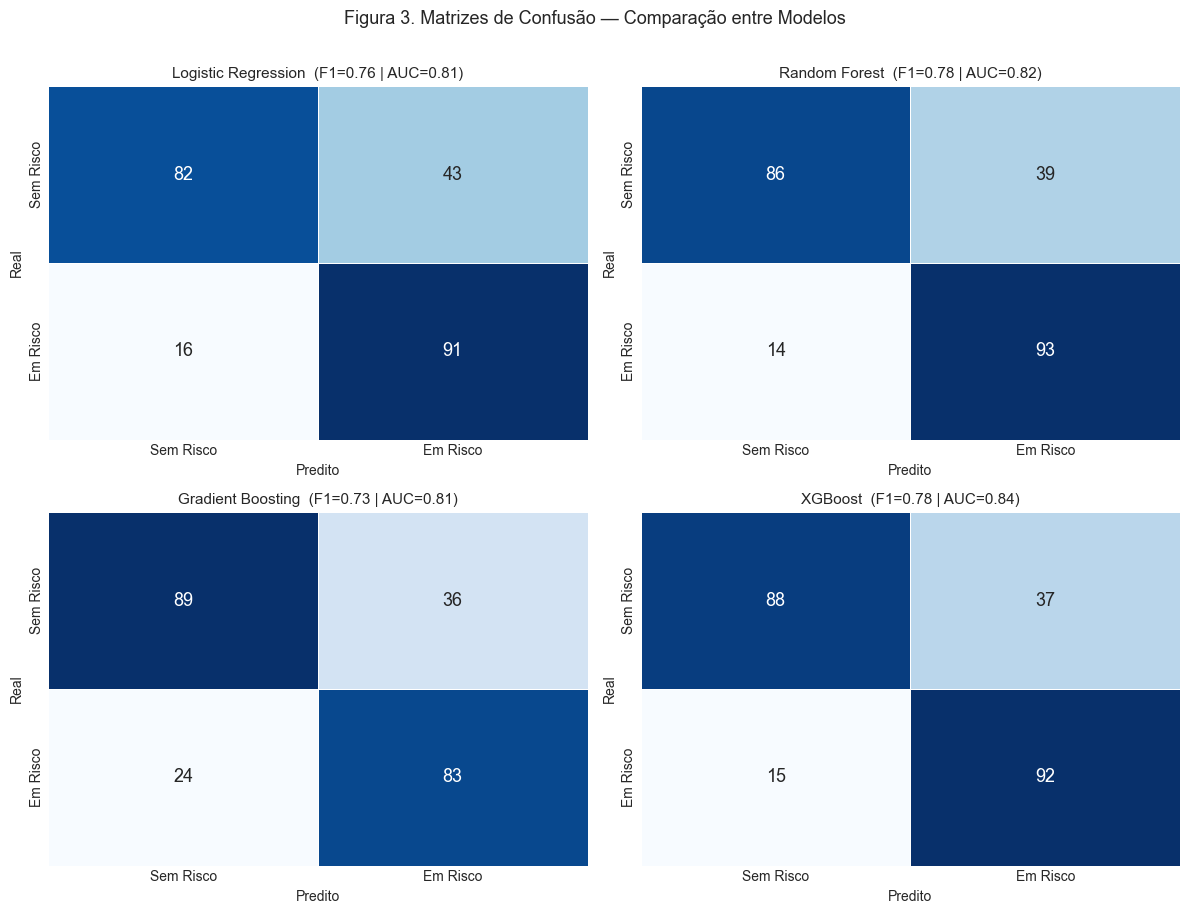


RELATÓRIO COMPLETO - MELHOR MODELO: Gradient Boosting
               precision    recall  f1-score   support

Sem Risco (0)       0.79      0.71      0.75       125
 Em Risco (1)       0.70      0.78      0.73       107

     accuracy                           0.74       232
    macro avg       0.74      0.74      0.74       232
 weighted avg       0.75      0.74      0.74       232



In [94]:
### 8.2 Matrizes de Confusão - Todos os Modelos

fig_cm, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

rotulos_classes = ['Sem Risco', 'Em Risco']

for idx, (nome, res) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=rotulos_classes, yticklabels=rotulos_classes,
        cbar=False, linewidths=0.5, annot_kws={'size': 13}
    )
    axes[idx].set_title(f'{nome}  (F1={res["f1"]:.2f} | AUC={res["roc_auc"]:.2f})',
                        fontsize=11)
    axes[idx].set_xlabel('Predito', fontsize=10)
    axes[idx].set_ylabel('Real', fontsize=10)

plt.suptitle('Figura 3. Matrizes de Confusão — Comparação entre Modelos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Relatório detalhado do melhor modelo
print(f"\n{'='*70}")
print(f"RELATÓRIO COMPLETO - MELHOR MODELO: {melhor_modelo_nome}")
print(f"{'='*70}")
print(classification_report(
    y_test, resultados[melhor_modelo_nome]['y_pred'],
    target_names=['Sem Risco (0)', 'Em Risco (1)']
))


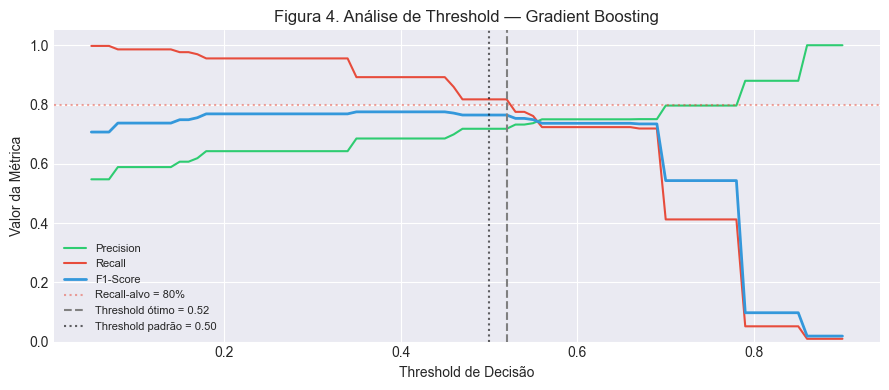

Threshold padrão  (0.50) → Recall=0.822  Precision=0.698  F1=0.755
Threshold ótimo   (0.52) → Recall=0.822  Precision=0.698  F1=0.755


In [95]:
### 8.3 Análise do Threshold de Decisão

from sklearn.model_selection import cross_val_predict
from sklearn.isotonic import IsotonicRegression

# No contexto do programa, deixar de identificar um aluno em risco tem custo maior
# do que sinalizá-lo desnecessariamente. Por isso, priorizamos recall elevado.
# O threshold é definido como o maior valor que ainda garante recall >= 80% nos dados de treino,
# usando predições out-of-fold para não contaminar o conjunto de teste.
RECALL_ALVO = 0.80

y_prob_oof = cross_val_predict(
    pipeline_escolhido, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# Calibração isotônica aplicada sobre as predições OOF
calibrador = IsotonicRegression(out_of_bounds='clip')
calibrador.fit(y_prob_oof, y_train)
y_prob_oof_cal  = calibrador.transform(y_prob_oof)
y_prob_test_cal = calibrador.transform(resultados[melhor_modelo_nome]['y_pred_proba'])

thresholds_range = np.arange(0.05, 0.91, 0.01)
metricas_threshold = []
for thr in thresholds_range:
    y_pred_thr = (y_prob_oof_cal >= thr).astype(int)
    if y_pred_thr.sum() > 0:
        metricas_threshold.append({
            'Threshold': round(float(thr), 2),
            'Precision': precision_score(y_train, y_pred_thr, zero_division=0),
            'Recall':    recall_score(y_train, y_pred_thr, zero_division=0),
            'F1':        f1_score(y_train, y_pred_thr, zero_division=0),
        })

df_threshold = pd.DataFrame(metricas_threshold)

# Maior threshold com recall >= RECALL_ALVO
candidatos = df_threshold[df_threshold['Recall'] >= RECALL_ALVO]
if candidatos.empty:
    threshold_otimo = df_threshold.loc[df_threshold['Recall'].idxmax(), 'Threshold']
else:
    threshold_otimo = candidatos.loc[candidatos['Threshold'].idxmax(), 'Threshold']

threshold_conservador = 0.50

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_threshold['Threshold'], df_threshold['Precision'], label='Precision', color='#2ECC71')
ax.plot(df_threshold['Threshold'], df_threshold['Recall'],    label='Recall',    color='#E74C3C')
ax.plot(df_threshold['Threshold'], df_threshold['F1'],        label='F1-Score',  color='#3498DB', linewidth=2)
ax.axhline(RECALL_ALVO, color='#E74C3C', linestyle=':', alpha=0.5,
           label=f'Recall-alvo = {RECALL_ALVO:.0%}')
ax.axvline(threshold_otimo,       color='gray',  linestyle='--',
           label=f'Threshold ótimo = {threshold_otimo:.2f}')
ax.axvline(threshold_conservador, color='black', linestyle=':', alpha=0.6,
           label=f'Threshold padrão = {threshold_conservador:.2f}')
ax.set_xlabel('Threshold de Decisão')
ax.set_ylabel('Valor da Métrica')
ax.set_title(f'Figura 4. Análise de Threshold — {melhor_modelo_nome}')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

y_pred_otimo  = (y_prob_test_cal >= threshold_otimo).astype(int)
y_pred_padrao = (y_prob_test_cal >= threshold_conservador).astype(int)

print(f"Threshold padrão  ({threshold_conservador:.2f}) → Recall={recall_score(y_test, y_pred_padrao):.3f}  "
      f"Precision={precision_score(y_test, y_pred_padrao):.3f}  F1={f1_score(y_test, y_pred_padrao):.3f}")
print(f"Threshold ótimo   ({threshold_otimo:.2f}) → Recall={recall_score(y_test, y_pred_otimo):.3f}  "
      f"Precision={precision_score(y_test, y_pred_otimo):.3f}  F1={f1_score(y_test, y_pred_otimo):.3f}")


---
## Interpretação dos Padrões de Risco

### Quais padrões nos indicadores permitem identificar alunos em risco?

Esta seção responde à pergunta central do Tech Challenge: identificar os padrões preditivos de risco de defasagem antes que a queda ocorra.

**Abordagem de Interpretabilidade:**
- **Análise bivariada:** Distribuição de cada indicador-chave por classe (risco vs. sem risco)
- **Boxplots comparativos:** Visualização das diferenças estatísticas entre grupos
- **Perfil do aluno em risco:** Síntese dos padrões identificados pelo modelo
- **Análise de interações:** Como a combinação de indicadores amplifica o risco

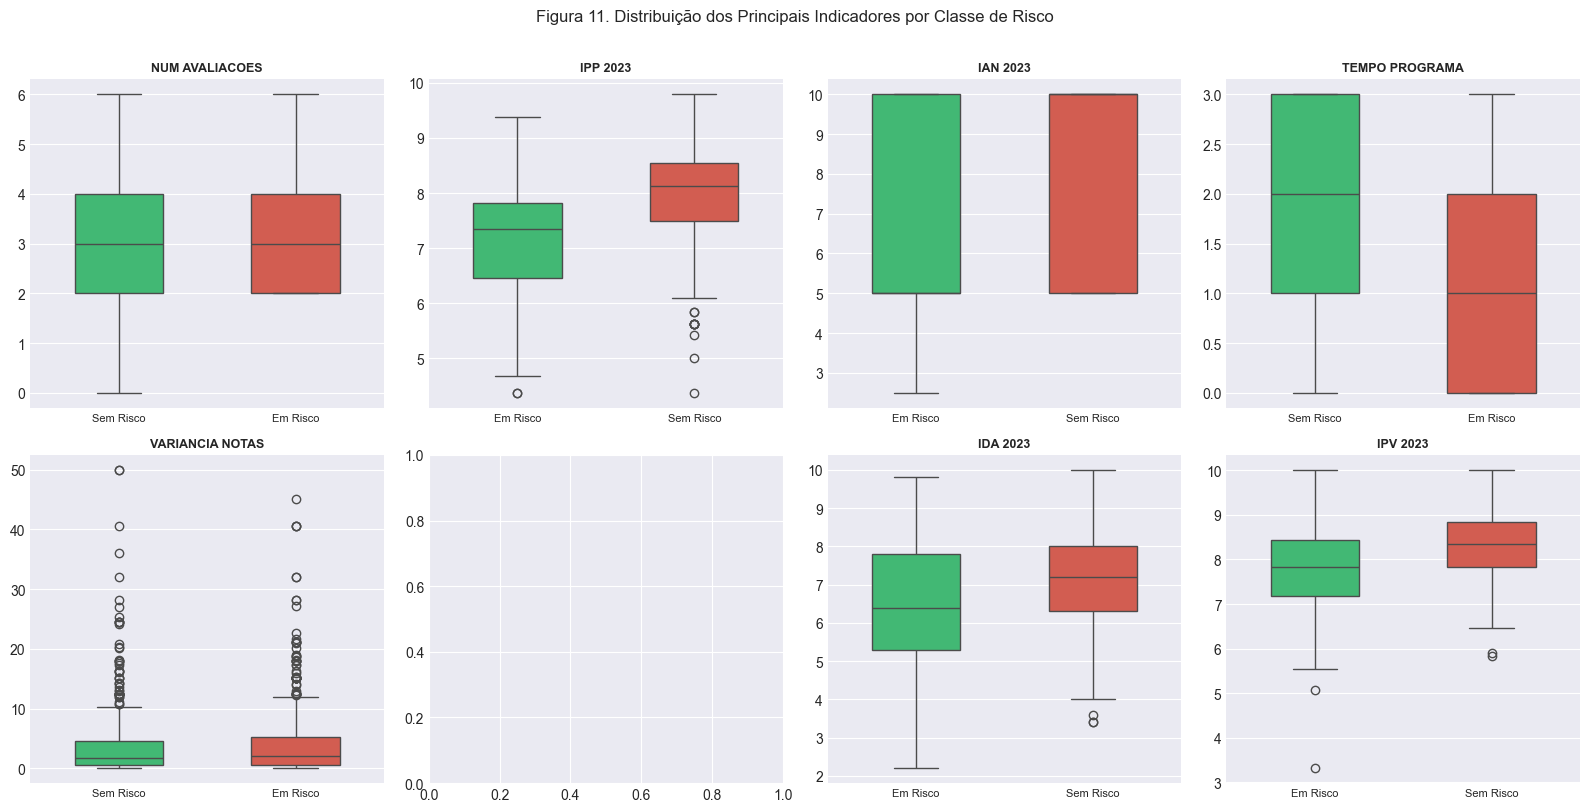

In [96]:
### 9.1 Boxplots: Distribuição dos Indicadores por Classe de Risco
# Compara a distribuição das 8 features mais importantes do modelo entre
# alunos em risco (vermelho) e sem risco (verde).

top_features_analise = feature_importance.head(8)['Feature'].tolist()
df_analise = df_clean.copy()

fig_padroes, axes_padroes = plt.subplots(2, 4, figsize=(16, 8))
axes_padroes = axes_padroes.flatten()

for i, feat in enumerate(top_features_analise):
    if feat in df_analise.columns:
        dados_feat = df_analise[['EM_RISCO', feat]].dropna()
        dados_feat['Classe'] = dados_feat['EM_RISCO'].map({0: 'Sem Risco', 1: 'Em Risco'})

        sns.boxplot(data=dados_feat, x='Classe', y=feat,
                    palette=['#2ECC71', '#E74C3C'],
                    ax=axes_padroes[i], width=0.5)

        axes_padroes[i].set_title(feat.replace('_', ' '), fontsize=9, fontweight='bold')
        axes_padroes[i].set_xlabel('')
        axes_padroes[i].set_ylabel('')
        axes_padroes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('Figura 11. Distribuição dos Principais Indicadores por Classe de Risco',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [97]:
### 9.2 Significância Estatística — Teste t de Student
# Verifica se as diferenças observadas nos boxplots são estatisticamente significativas.
# p < 0.001 (***), p < 0.01 (**), p < 0.05 (*), não significativo (ns).

from scipy import stats

resultados_teste = []
for feat in top_features_analise:
    if feat in df_analise.columns:
        grupo_risco     = df_analise.loc[df_analise['EM_RISCO'] == 1, feat].dropna()
        grupo_sem_risco = df_analise.loc[df_analise['EM_RISCO'] == 0, feat].dropna()
        if len(grupo_risco) > 5 and len(grupo_sem_risco) > 5:
            t_stat, p_val = stats.ttest_ind(grupo_risco, grupo_sem_risco)
            resultados_teste.append({
                'Feature'        : feat,
                'Media Risco'    : round(grupo_risco.mean(), 3),
                'Media Sem Risco': round(grupo_sem_risco.mean(), 3),
                'Diferenca'      : round(grupo_risco.mean() - grupo_sem_risco.mean(), 3),
                'p-valor'        : round(p_val, 4),
                'Sig.'           : '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
            })

df_testes = pd.DataFrame(resultados_teste)

print("="*72)
print("SIGNIFICANCIA ESTATISTICA DAS DIFERENCAS (Teste t de Student)")
print("="*72)
print(df_testes.to_string(index=False))


SIGNIFICANCIA ESTATISTICA DAS DIFERENCAS (Teste t de Student)
        Feature  Media Risco  Media Sem Risco  Diferenca  p-valor Sig.
 NUM_AVALIACOES        3.159            2.773      0.386   0.0000  ***
       IPP_2023        7.123            8.009     -0.886   0.0000  ***
       IAN_2023        6.331            8.129     -1.798   0.0000  ***
 TEMPO_PROGRAMA        1.064            1.838     -0.774   0.0000  ***
VARIANCIA_NOTAS        4.241            3.832      0.409   0.2857   ns
       IDA_2023        6.447            7.129     -0.682   0.0000  ***
       IPV_2023        7.825            8.349     -0.523   0.0000  ***


In [98]:
### 9.3 Perfil Comparativo: Aluno em Risco vs. Sem Risco
# Calcula a média de cada indicador para os dois grupos e destaca
# as features com maior diferença percentual (Delta > 15%).

features_perfil = [f for f in ['MEDIA_NOTAS', 'NOTA_MAT', 'NOTA_PORT', 'NOTA_ING',
                                'TEMPO_PROGRAMA', 'NUM_AVALIACOES', 'VARIANCIA_NOTAS',
                                'IAA_2023', 'IEG_2023', 'IDA_2023']
                   if f in df_clean.columns]

perfil = df_clean.groupby('EM_RISCO')[features_perfil].mean().T
perfil.columns = ['Sem Risco', 'Em Risco']
perfil['Delta_%'] = ((perfil['Em Risco'] - perfil['Sem Risco']) / perfil['Sem Risco'].abs() * 100).round(1)

print("="*70)
print("PERFIL COMPARATIVO: ALUNO EM RISCO vs. SEM RISCO")
print("="*70)
print(f"{'Feature':<25} {'Sem Risco':>12} {'Em Risco':>12} {'Delta %':>10}")
print("-"*70)
for feat in perfil.index:
    destaque = " *" if abs(perfil.loc[feat, 'Delta_%']) > 15 else ""
    print(f"{feat:<25} {perfil.loc[feat, 'Sem Risco']:>12.3f} "
          f"{perfil.loc[feat, 'Em Risco']:>12.3f} "
          f"{perfil.loc[feat, 'Delta_%']:>9.1f}%{destaque}")
print("="*70)
print("  * diferenca relativa acima de 15%")


PERFIL COMPARATIVO: ALUNO EM RISCO vs. SEM RISCO
Feature                      Sem Risco     Em Risco    Delta %
----------------------------------------------------------------------
MEDIA_NOTAS                      6.486        6.220      -4.1%
NOTA_MAT                         6.289        6.172      -1.9%
NOTA_PORT                        6.327        6.028      -4.7%
NOTA_ING                         6.721        6.388      -5.0%
TEMPO_PROGRAMA                   1.838        1.064     -42.1% *
NUM_AVALIACOES                   2.773        3.159      13.9%
VARIANCIA_NOTAS                  3.832        4.241      10.7%
IAA_2023                         7.125        6.827      -4.2%
IEG_2023                         9.056        8.625      -4.8%
IDA_2023                         7.129        6.447      -9.6%
  * diferenca relativa acima de 15%


In [99]:
### 9.4 Taxa de Risco por Classificação Pedagógica (Pedra 2023)
# Mostra a proporção de alunos em risco dentro de cada nível pedagógico,
# revelando quais grupos têm maior vulnerabilidade.

if 'PEDRA_2023' in df_clean.columns:
    pedra_risco = (df_clean
                   .groupby('PEDRA_2023')['EM_RISCO']
                   .agg(N='count', Taxa='mean')
                   .reset_index())
    pedra_risco['Taxa %'] = (pedra_risco['Taxa'] * 100).round(1)
    pedra_risco = pedra_risco.sort_values('Taxa', ascending=False)

    print("="*50)
    print("TAXA DE RISCO POR CLASSIFICACAO PEDAGOGICA (2023)")
    print("="*50)
    print(pedra_risco[['PEDRA_2023', 'N', 'Taxa %']].to_string(index=False))


TAXA DE RISCO POR CLASSIFICACAO PEDAGOGICA (2023)
PEDRA_2023   N  Taxa %
   Quartzo  42    83.3
     Agata 153    66.7
  Ametista 308    35.4
   Topázio 187    31.6


---
## Persistência do Modelo para Deploy

### Artefatos Salvos
O modelo é serializado com todos os componentes necessários para produção:
- **Pipeline completo:** Scaler + Modelo (sem necessidade de pré-processar manualmente)
- **Metadados:** Nomes das features, encoders, thresholds e informações de performance
- **Imputadores:** Para tratamento de dados ausentes em produção

Estes artefatos são utilizados diretamente pelo dashboard Streamlit (`app_streamlit.py`).

In [100]:
### 11.1 Serialização do Modelo e Artefatos

import os

model_dir = 'modelo'
os.makedirs(model_dir, exist_ok=True)

# Métricas para o Streamlit (chaves padronizadas)
metricas_finais = {
    'modelo_nome': melhor_modelo_nome,
    'roc_auc_teste': resultados[melhor_modelo_nome]['roc_auc'],
    'f1_teste': resultados[melhor_modelo_nome]['f1'],
    'precisao_teste': resultados[melhor_modelo_nome]['precision'],
    'recall_teste': resultados[melhor_modelo_nome]['recall'],
    'acuracia_teste': resultados[melhor_modelo_nome]['accuracy'],
    'roc_auc_cv_mean': resultados_cv[melhor_modelo_nome]['roc_auc_cv_mean'],
    'roc_auc_cv_std': resultados_cv[melhor_modelo_nome]['roc_auc_cv_std'],
    'f1_cv_mean': resultados_cv[melhor_modelo_nome]['f1_cv_mean'],
    'threshold_otimo': float(threshold_otimo),
    'threshold_conservador': float(threshold_conservador),
    'n_features': len(features_finais),
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
    'taxa_risco_base': float(y.mean()),
}

# Parâmetros de engenharia de features — usados pelo Streamlit para reproduzir
# exatamente as features derivadas (MEDIA_NOTAS, VARIANCIA_NOTAS, binárias) em produção.
feature_rules_artefato = {
    'variancia_ddof': variancia_ddof,
    'desempenho_equilibrado_threshold': thr_desempenho_equilibrado,
    'notas_baixas_threshold': thr_notas_baixas,
}

# Schema de entrada: mapeamento nome_feature → tipo, para validação no Streamlit
schema_entrada = {col: str(df_ml[col].dtype) for col in features_finais}

# Artefato padronizado para consumo direto pelo Streamlit.
# Chaves obrigatórias: pipeline_inferencia, schema_entrada, features,
#   feature_rules, imputer, label_encoders.
# calibrador_isotonic: IsotonicRegression ajustado sobre predições OOF do treino.
#   O Streamlit aplica calibrador.transform() antes de comparar com optimal_threshold.
artefatos = {
    # Chaves obrigatórias (validadas por validar_artefato no Streamlit)
    'pipeline_inferencia': pipeline_escolhido,
    'schema_entrada': schema_entrada,
    'features': features_finais,
    'feature_rules': feature_rules_artefato,
    'imputer': imputer,
    'label_encoders': le_dict,
    # Calibração isotônica — aplicar sobre predict_proba antes do threshold
    'calibrador_isotonic': calibrador,
    # Métricas e threshold
    'metricas_teste': {
        'optimal_threshold': float(threshold_otimo),
        'roc_auc': resultados[melhor_modelo_nome]['roc_auc'],
        'accuracy': resultados[melhor_modelo_nome]['accuracy'],
        'precision': resultados[melhor_modelo_nome]['precision'],
        'recall': resultados[melhor_modelo_nome]['recall'],
        'f1': resultados[melhor_modelo_nome]['f1'],
    },
    'metricas_cv': {
        'roc_auc_cv_mean': resultados_cv[melhor_modelo_nome]['roc_auc_cv_mean'],
        'roc_auc_cv_std': resultados_cv[melhor_modelo_nome]['roc_auc_cv_std'],
    },
    # Importância e versão
    'feature_importance': feature_importance,
    'versao': '3.0',
    # Informações auxiliares exibidas no painel de métricas do Streamlit
    'melhorias_v3': {
        'impacto_features_historicas': sum(
            feature_importance.loc[feature_importance['Feature'].isin(
                [f for f in features_finais if '2022' in f or '2023' in f]
            ), 'Importance'].values
        ) if isinstance(feature_importance, pd.DataFrame) else 0.0
    },
    'features_melhoradas': [f for f in features_finais if '2022' in f or '2023' in f],
    # Campos legados mantidos para compatibilidade com outros scripts
    'metricas': metricas_finais,
    'imputer_num': imputer,
    'imputer_cat': imputer_cat,
    'features_numericas': features_numericas,
    'features_categoricas': features_categoricas,
    'features_finais': features_finais,
    'thresholds': {'otimo': float(threshold_otimo), 'conservador': float(threshold_conservador)},
    'resultados_comparacao': {
        nome: {k: v for k, v in res.items() if k not in ['pipeline', 'modelo', 'scaler', 'y_pred', 'y_pred_proba']}
        for nome, res in resultados.items()
    },
}

# Salvar na raiz do projeto (consumido pelo Streamlit) e em modelo/ (backup)
joblib.dump(artefatos, 'modelo_risco_defasagem.pkl')
joblib.dump(artefatos, os.path.join(model_dir, 'modelo_risco_educacional.pkl'))
joblib.dump(pipeline_escolhido, os.path.join(model_dir, 'pipeline_final.pkl'))

print("="*60)
print("MODELO SALVO COM SUCESSO")
print("="*60)
print(f"Modelo selecionado: {melhor_modelo_nome}")
print(f"ROC-AUC (teste):    {metricas_finais['roc_auc_teste']:.4f}")
print(f"F1-Score (teste):   {metricas_finais['f1_teste']:.4f}")
print(f"ROC-AUC (CV):       {metricas_finais['roc_auc_cv_mean']:.4f} ± {metricas_finais['roc_auc_cv_std']:.4f}")
print(f"Threshold ótimo:    {float(threshold_otimo):.2f}  (recall-target OOF calibrado >= {RECALL_ALVO:.0%})")
print(f"Threshold padrão:   {float(threshold_conservador):.2f}  (baseline de comparação)")
print(f"Features:           {len(features_finais)}")
print("-"*60)
print(f"Artefatos salvos em: modelo_risco_defasagem.pkl  (Streamlit)")
print(f"Artefatos salvos em: ./{model_dir}/modelo_risco_educacional.pkl  (backup)")
for f in os.listdir(model_dir):
    tamanho = os.path.getsize(os.path.join(model_dir, f)) / 1024
    print(f"  - {f} ({tamanho:.1f} KB)")


MODELO SALVO COM SUCESSO
Modelo selecionado: Gradient Boosting
ROC-AUC (teste):    0.8124
F1-Score (teste):   0.7345
ROC-AUC (CV):       0.8305 ± 0.0321
Threshold ótimo:    0.52  (recall-target OOF calibrado >= 80%)
Threshold padrão:   0.50  (baseline de comparação)
Features:           29
------------------------------------------------------------
Artefatos salvos em: modelo_risco_defasagem.pkl  (Streamlit)
Artefatos salvos em: ./modelo/modelo_risco_educacional.pkl  (backup)
  - modelo_risco_educacional.pkl (304.8 KB)
  - pipeline_final.pkl (297.6 KB)


---
# Análise Exploratória e Storytelling

Esta parte aborda as perguntas analíticas requeridas pelo projeto, com foco em compreender o perfil dos beneficiários do programa PEDE, a evolução dos indicadores ao longo do tempo e os fatores associados ao risco de defasagem escolar.

---


## Pergunta 1 — Adequação do Nível (IAN): Perfil de Defasagem e Evolução Temporal

In [101]:
# ── Preparação: coleta das séries IAN e classificação por faixa ──────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# IAN é escala discreta: 2.5 (severo), 5.0 (moderado), 10.0 (adequado)
BINS   = [0, 4.0, 5.01, 10.01]
LABELS = ['Severo (< 4,0)', 'Moderado (4,0–5,0)', 'Adequado (10,0)']
CORES  = ['#C0392B', '#E67E22', '#27AE60']

ian_raw = {}
for ano, df_src, col in [('2022', df_2022, 'IAN'), ('2023', df_2023, 'IAN')]:
    if col in df_src.columns:
        s = pd.to_numeric(df_src[col], errors='coerce').dropna()
        if len(s) > 5:
            ian_raw[ano] = s

if 'IAN' in df_2024.columns:
    s = pd.to_numeric(df_2024['IAN'], errors='coerce').dropna()
    if len(s) > 5:
        ian_raw['2024'] = s
elif 'IAN' in df_clean.columns:
    ian_raw['2024'] = df_clean['IAN'].dropna()

anos = sorted(ian_raw.keys())

# Contagens e percentuais por faixa
contagens, percentuais = {}, {}
for ano, s in ian_raw.items():
    c = pd.cut(s, bins=BINS, labels=LABELS, right=False).value_counts().reindex(LABELS, fill_value=0)
    contagens[ano]   = c
    percentuais[ano] = (c / c.sum() * 100).round(1)

df_cnt = pd.DataFrame(contagens).T
df_pct = pd.DataFrame(percentuais).T

stats = pd.DataFrame({
    ano: {'n': int(len(s)), 'min': s.min(), 'mediana': s.median(),
          'média': round(s.mean(), 2), 'max': s.max()}
    for ano, s in ian_raw.items()
}).T

print("=== Estatísticas do IAN por ano ===")
print(stats.to_string())
print("\n=== Distribuição percentual por faixa ===")
print(df_pct.to_string())


=== Estatísticas do IAN por ano ===
           n  min  mediana  média   max
2022   860.0  2.5      5.0   6.42  10.0
2023  1014.0  2.5      5.0   7.24  10.0
2024  1156.0  2.5     10.0   7.68  10.0

=== Distribuição percentual por faixa ===
IAN   Severo (< 4,0)  Moderado (4,0–5,0)  Adequado (10,0)
2022             3.3                66.6             30.1
2023             1.4                53.1             45.6
2024             0.3                45.9             53.8


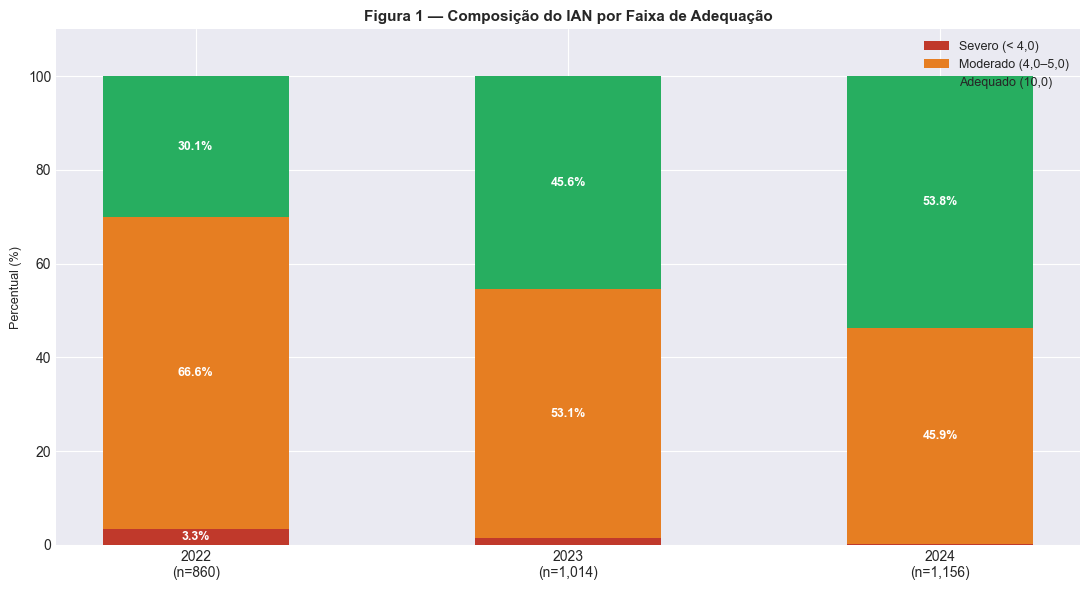

In [102]:
# ── Gráfico 1: Composição percentual por faixa de IAN (barras empilhadas) ────

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(anos))
xs = np.arange(len(anos))

for label, cor in zip(LABELS, CORES):
    vals = df_pct[label].values
    bars = ax.bar(xs, vals, bottom=bottom, color=cor, label=label, width=0.5)
    for x, v, b in zip(xs, vals, bottom):
        if v > 3:
            ax.text(x, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax.set_xticks(xs)
ax.set_xticklabels([f'{a}\n(n={len(ian_raw[a]):,})' for a in anos], fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=9)
ax.set_ylim(0, 110)
ax.set_title('Figura 1 — Composição do IAN por Faixa de Adequação', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


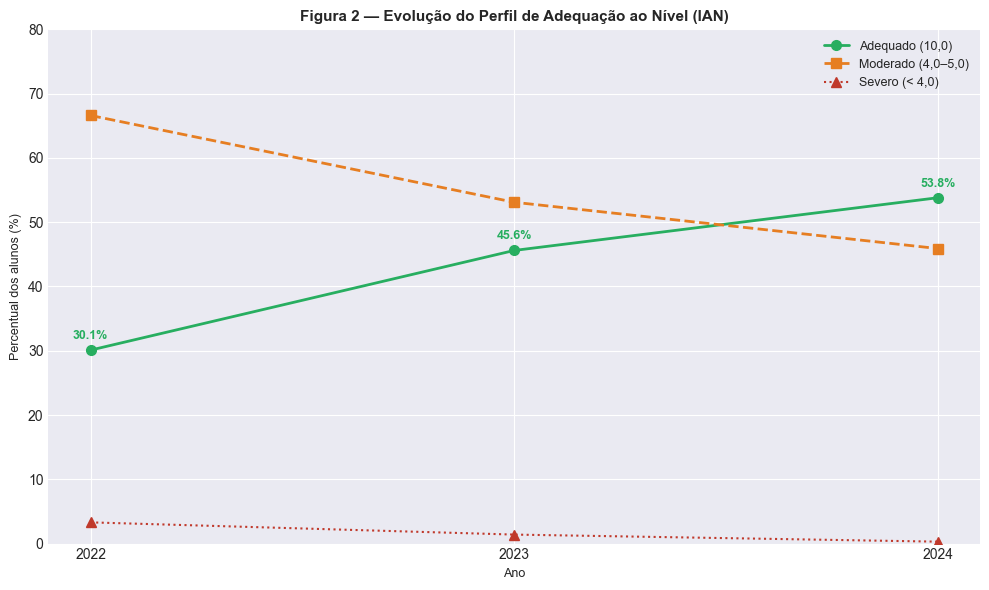

In [103]:
# ── Gráfico 2: Evolução do % de adequados e defasados ao longo do tempo ───────

adequados   = [df_pct.loc[a, 'Adequado (10,0)']    for a in anos]
moderados   = [df_pct.loc[a, 'Moderado (4,0–5,0)'] for a in anos]
severos     = [df_pct.loc[a, 'Severo (< 4,0)']     for a in anos]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(anos, adequados, 'o-', color='#27AE60', lw=2, ms=7, label='Adequado (10,0)')
ax.plot(anos, moderados, 's--', color='#E67E22', lw=2, ms=7, label='Moderado (4,0–5,0)')
ax.plot(anos, severos,   '^:', color='#C0392B', lw=1.5, ms=7, label='Severo (< 4,0)')

for a, v in zip(anos, adequados):
    ax.annotate(f'{v:.1f}%', (a, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color='#27AE60', fontweight='bold')

ax.set_ylim(0, 80)
ax.set_ylabel('Percentual dos alunos (%)', fontsize=9)
ax.set_xlabel('Ano', fontsize=9)
ax.set_title('Figura 2 — Evolução do Perfil de Adequação ao Nível (IAN)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Pergunta 2 — Desempenho Acadêmico (IDA): Evolução por Ano e por Fase

In [104]:
# ── Preparação: IDA por ano e por fase ───────────────────────────────────────

# Coletar IDA de cada base anual
ida_series = {}
for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    if 'IDA' in df_src.columns:
        s = pd.to_numeric(df_src['IDA'], errors='coerce').dropna()
        if len(s) > 5:
            ida_series[ano] = s

anos_ida = sorted(ida_series.keys())

# Estatísticas por ano
stats_ida = pd.DataFrame({
    ano: {
        'n': int(len(s)),
        'média': round(s.mean(), 3),
        'mediana': round(s.median(), 3),
        'desvio_padrão': round(s.std(), 3),
        'mín': round(s.min(), 3),
        'máx': round(s.max(), 3),
    }
    for ano, s in ida_series.items()
}).T

print("=== IDA — Estatísticas por ano ===")
print(stats_ida.to_string())

# IDA por Fase (se coluna disponível em df_2024)
col_fase = 'Fase' if 'Fase' in df_2024.columns else None
if col_fase:
    ida_por_fase = {}
    for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
        if 'IDA' in df_src.columns and col_fase in df_src.columns:
            tmp = df_src[[col_fase, 'IDA']].copy()
            tmp['IDA'] = pd.to_numeric(tmp['IDA'], errors='coerce')
            tmp = tmp.dropna()
            tmp[col_fase] = tmp[col_fase].astype(str).str.strip()
            ida_por_fase[ano] = tmp.groupby(col_fase)['IDA'].mean().round(3)

    df_fase = pd.DataFrame(ida_por_fase).sort_index()
    print("\n=== IDA médio por Fase e Ano ===")
    print(df_fase.to_string())
else:
    df_fase = None
    print("\nColuna 'Fase' não encontrada.")


=== IDA — Estatísticas por ano ===
           n  média  mediana  desvio_padrão  mín   máx
2022   860.0  6.093     6.30          2.046  0.0   9.9
2023   937.0  6.663     6.80          1.595  0.0  10.0
2024  1055.0  6.351     6.75          2.132  0.0  10.0

=== IDA médio por Fase e Ano ===
         2022   2023   2024
Fase                       
0       7.140    NaN    NaN
1       6.464    NaN    NaN
1A        NaN    NaN  7.571
1B        NaN    NaN  7.183
1C        NaN    NaN  7.286
1D        NaN    NaN  6.600
1E        NaN    NaN  6.312
1G        NaN    NaN  7.266
1H        NaN    NaN  5.792
1J        NaN    NaN  6.000
1K        NaN    NaN  5.783
1L        NaN    NaN  7.333
1M        NaN    NaN  7.983
1N        NaN    NaN  5.850
1P        NaN    NaN  7.000
1R        NaN    NaN  6.643
2       5.406    NaN    NaN
2A        NaN    NaN  5.500
2B        NaN    NaN  5.136
2C        NaN    NaN  4.344
2D        NaN    NaN  7.429
2G        NaN    NaN  6.054
2H        NaN    NaN  7.268
2I        N

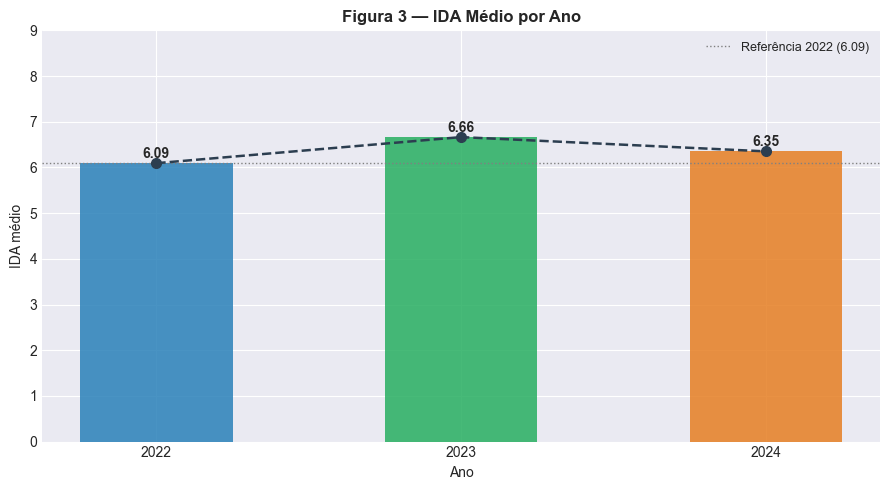

In [105]:
# ── Gráfico 1: IDA médio por ano (barras com linha de tendência) ──────────────

medias_ida  = [ida_series[a].mean()   for a in anos_ida]
medianas_ida = [ida_series[a].median() for a in anos_ida]
ns_ida      = [len(ida_series[a])     for a in anos_ida]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(anos_ida, medias_ida, color=['#2980B9', '#27AE60', '#E67E22'],
              width=0.5, alpha=0.85, zorder=2)

ax.plot(anos_ida, medias_ida, 'o--', color='#2C3E50', lw=1.8, ms=7, zorder=3)

for bar, v in zip(bars, medias_ida):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(medias_ida[0], color='gray', lw=1, ls=':', label=f'Referência 2022 ({medias_ida[0]:.2f})')
ax.set_ylim(0, 9)
ax.set_ylabel('IDA médio', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.set_title('Figura 3 — IDA Médio por Ano', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


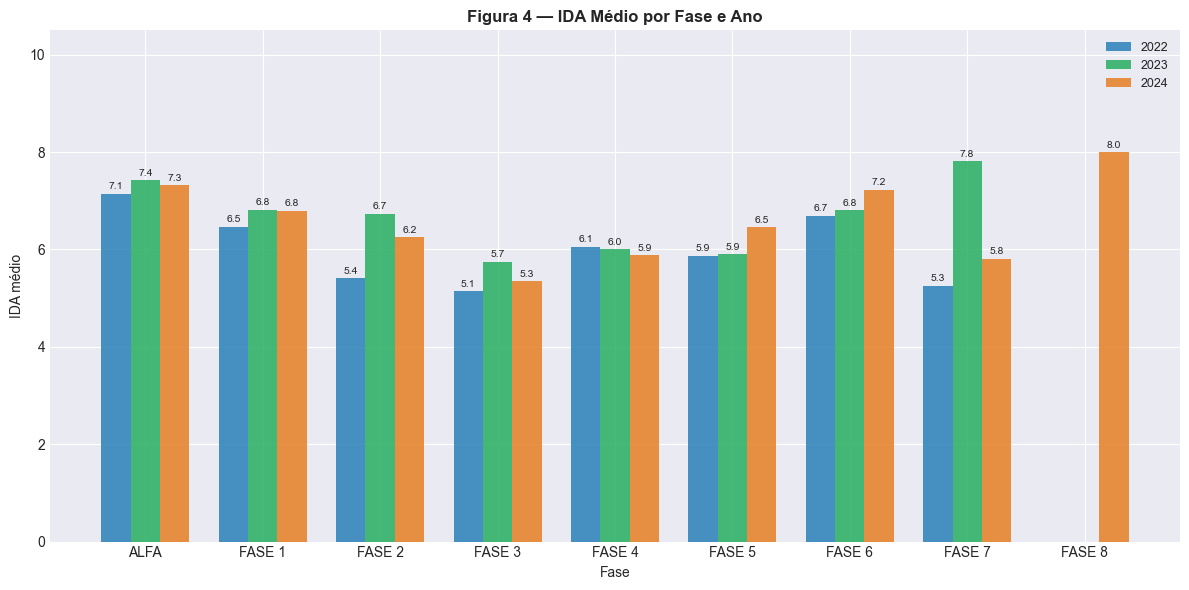


Tabela completa:
            2022   2023   2024
FASE_NORM                     
ALFA       7.140  7.422  7.320
FASE 1     6.464  6.814  6.791
FASE 2     5.406  6.737  6.250
FASE 3     5.142  5.747  5.348
FASE 4     6.053  6.004  5.879
FASE 5     5.873  5.905  6.453
FASE 6     6.694  6.809  7.230
FASE 7     5.252  7.810  5.810
FASE 8       NaN    NaN  8.000


In [106]:
# ── Gráfico 2: IDA médio por fase (normalizada) e por ano ────────────────────

def normalizar_fase(df_src, col_fase='Fase'):
    """Padroniza os rótulos de Fase para ALFA / FASE 1 … FASE 8."""
    tmp = df_src[[col_fase, 'IDA']].copy()
    tmp['IDA'] = pd.to_numeric(tmp['IDA'], errors='coerce')
    tmp = tmp.dropna(subset=['IDA', col_fase])
    tmp[col_fase] = tmp[col_fase].astype(str).str.strip()

    def mapear(v):
        if v in ('0', 'ALFA'):
            return 'ALFA'
        if v.startswith('FASE'):
            return v
        # formato "1A", "2B" etc. — primeiro caractere é o número da fase
        if v[0].isdigit():
            return f'FASE {v[0]}'
        return v

    tmp['FASE_NORM'] = tmp[col_fase].apply(mapear)
    return tmp.groupby('FASE_NORM')['IDA'].mean().round(3)

fases_norm = {}
for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    if 'IDA' in df_src.columns and 'Fase' in df_src.columns:
        fases_norm[ano] = normalizar_fase(df_src)

df_fase_norm = pd.DataFrame(fases_norm)

# Ordenar fases: ALFA primeiro, depois FASE 1..8
ordem = ['ALFA'] + [f'FASE {i}' for i in range(1, 9)]
df_fase_norm = df_fase_norm.reindex([f for f in ordem if f in df_fase_norm.index])

fig, ax = plt.subplots(figsize=(12, 6))

n_fases = len(df_fase_norm)
x = np.arange(n_fases)
width = 0.25
cores_anos = ['#2980B9', '#27AE60', '#E67E22']
anos_disp = [a for a in ['2022', '2023', '2024'] if a in df_fase_norm.columns]

for i, (ano, cor) in enumerate(zip(anos_disp, cores_anos)):
    vals = df_fase_norm[ano].values
    offset = (i - len(anos_disp) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width, color=cor, label=ano, alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(df_fase_norm.index, fontsize=10)
ax.set_ylim(0, 10.5)
ax.set_ylabel('IDA médio', fontsize=10)
ax.set_xlabel('Fase', fontsize=10)
ax.set_title('Figura 4 — IDA Médio por Fase e Ano', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTabela completa:")
print(df_fase_norm.to_string())


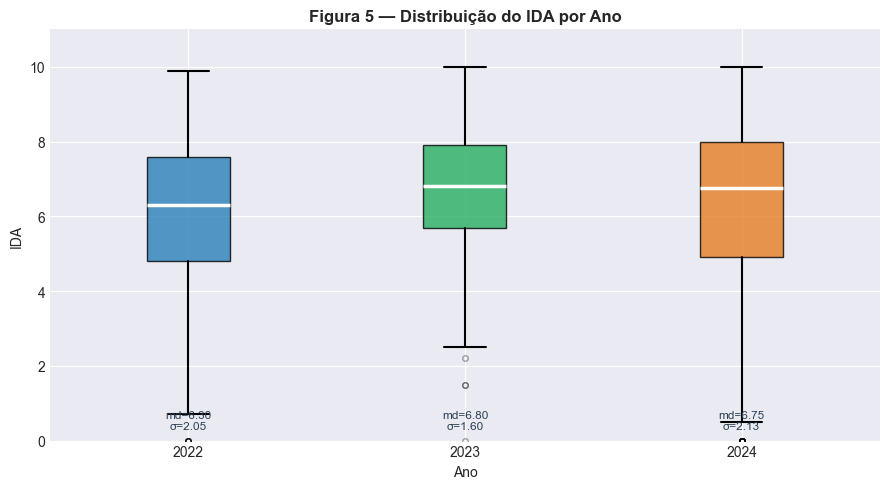

In [107]:
# ── Gráfico 3: Distribuição do IDA por ano (boxplot) ─────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

data_box = [ida_series[a].values for a in anos_ida]
cores_box = ['#2980B9', '#27AE60', '#E67E22']

bp = ax.boxplot(
    data_box, labels=anos_ida, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.35)
)
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)

# Anotar mediana e desvio-padrão
for i, (a, cor) in enumerate(zip(anos_ida, cores_box), start=1):
    med = ida_series[a].median()
    std = ida_series[a].std()
    ax.text(i, 0.3, f'md={med:.2f}\nσ={std:.2f}', ha='center', fontsize=8.5,
            color='#2C3E50')

ax.set_ylabel('IDA', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.set_title('Figura 5 — Distribuição do IDA por Ano', fontsize=12, fontweight='bold')
ax.set_ylim(0, 11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Pergunta 3 — Engajamento (IEG): Relação com IDA e IPV


In [108]:
# ── Preparação: IEG, IDA e IPV por ano — correlações e quartis ───────────────
from scipy import stats as sp_stats

ieg_data = {}   # {ano: DataFrame com IEG, IDA, IPV limpos}
corr_anos = {}  # {ano: {'IEG-IDA': (r, p), 'IEG-IPV': (r, p)}}

for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    tmp = df_src[['IEG', 'IDA', 'IPV']].copy()
    for col in ['IEG', 'IDA', 'IPV']:
        tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
    tmp = tmp.dropna()
    ieg_data[ano] = tmp
    r1, p1 = sp_stats.pearsonr(tmp['IEG'], tmp['IDA'])
    r2, p2 = sp_stats.pearsonr(tmp['IEG'], tmp['IPV'])
    corr_anos[ano] = {'IEG-IDA': (round(r1, 3), p1), 'IEG-IPV': (round(r2, 3), p2)}

print("=== Correlações de Pearson (IEG × IDA e IEG × IPV) ===")
for ano, d in corr_anos.items():
    r1, p1 = d['IEG-IDA']
    r2, p2 = d['IEG-IPV']
    n = len(ieg_data[ano])
    print(f"{ano} (n={n}): IEG-IDA r={r1:.3f} p={p1:.2e}  |  IEG-IPV r={r2:.3f} p={p2:.2e}")

# Quartis de IEG em 2024
d24 = ieg_data['2024'].copy()
d24['IEG_Q'] = pd.qcut(d24['IEG'], 4,
                        labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)'])
tbl_q = d24.groupby('IEG_Q', observed=False)[['IDA', 'IPV']].mean().round(3)
tbl_q['n'] = d24.groupby('IEG_Q', observed=False).size()
q_limits = d24['IEG'].quantile([0, 0.25, 0.5, 0.75, 1.0]).round(2)

print("\n=== IDA e IPV médios por quartil de IEG (2024) ===")
print(tbl_q[['n', 'IDA', 'IPV']].to_string())
print(f"\nLimites quartis IEG: {q_limits.tolist()}")


=== Correlações de Pearson (IEG × IDA e IEG × IPV) ===
2022 (n=860): IEG-IDA r=0.564 p=2.03e-73  |  IEG-IPV r=0.589 p=1.68e-81
2023 (n=937): IEG-IDA r=0.461 p=1.72e-50  |  IEG-IPV r=0.448 p=1.96e-47
2024 (n=1054): IEG-IDA r=0.547 p=2.15e-83  |  IEG-IPV r=0.535 p=3.44e-79

=== IDA e IPV médios por quartil de IEG (2024) ===
              n    IDA    IPV
IEG_Q                        
Q1 (baixo)  264  4.700  6.519
Q2          263  6.125  7.228
Q3          265  6.967  7.636
Q4 (alto)   262  7.615  8.037

Limites quartis IEG: [0.0, 7.15, 8.59, 9.5, 10.0]


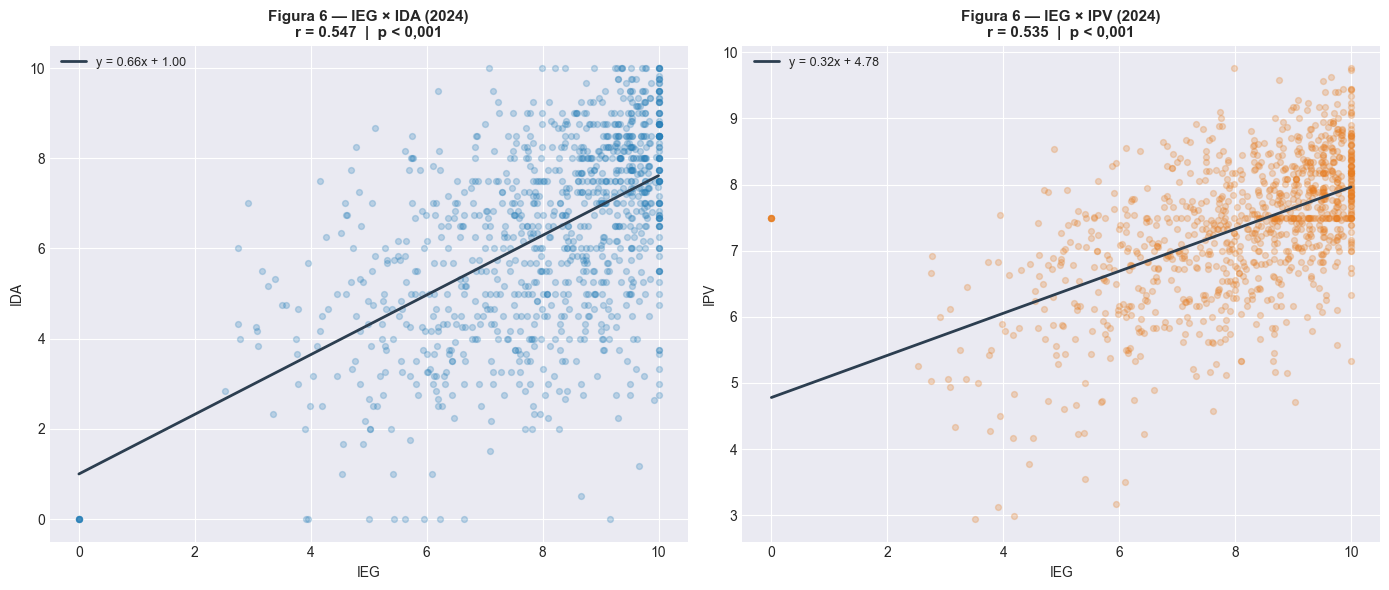

In [109]:
# ── Gráfico 1: Scatter IEG × IDA e IEG × IPV (2024, com regressão) ──────────

d24 = ieg_data['2024'].copy()
r_ida = corr_anos['2024']['IEG-IDA'][0]
r_ipv = corr_anos['2024']['IEG-IPV'][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, r_val, cor, titulo in [
    (axes[0], 'IDA', r_ida, '#2980B9', 'IEG × IDA'),
    (axes[1], 'IPV', r_ipv, '#E67E22', 'IEG × IPV'),
]:
    ax.scatter(d24['IEG'], d24[col], alpha=0.25, s=18, color=cor)

    # Linha de regressão
    m, b, *_ = sp_stats.linregress(d24['IEG'], d24[col])
    xs = np.linspace(d24['IEG'].min(), d24['IEG'].max(), 200)
    ax.plot(xs, m * xs + b, color='#2C3E50', lw=2, label=f'y = {m:.2f}x + {b:.2f}')

    ax.set_xlabel('IEG', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(f'Figura 6 — {titulo} (2024)\nr = {r_val:.3f}  |  p < 0,001',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


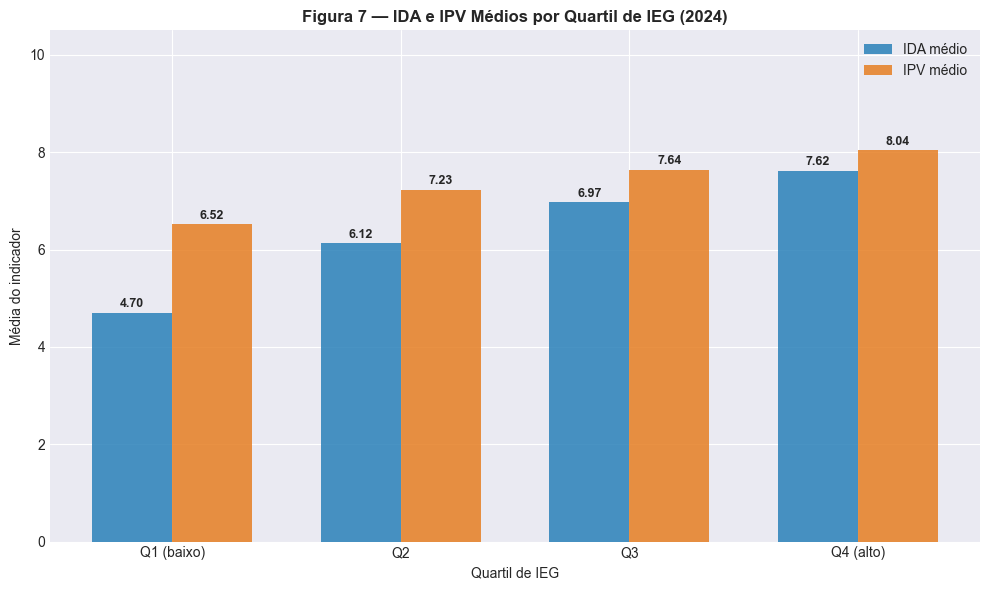

In [110]:
# ── Gráfico 2: IDA e IPV médios por quartil de IEG (2024) ────────────────────

grupos = tbl_q.index.tolist()
x = np.arange(len(grupos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x - width / 2, tbl_q['IDA'], width, label='IDA médio',
            color='#2980B9', alpha=0.85)
b2 = ax.bar(x + width / 2, tbl_q['IPV'], width, label='IPV médio',
            color='#E67E22', alpha=0.85)

for bar in list(b1) + list(b2):
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=10)
ax.set_ylim(0, 10.5)
ax.set_ylabel('Média do indicador', fontsize=10)
ax.set_xlabel('Quartil de IEG', fontsize=10)
ax.set_title('Figura 7 — IDA e IPV Médios por Quartil de IEG (2024)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


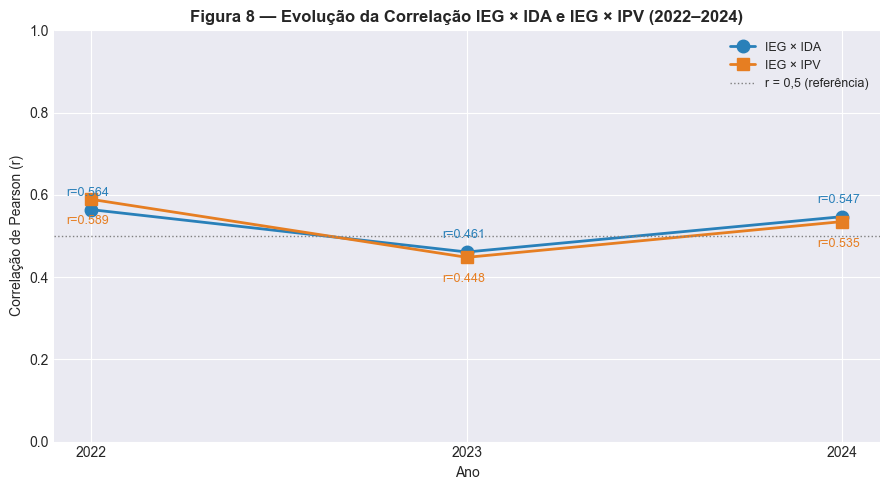

In [111]:
# ── Gráfico 3: Evolução das correlações (r de Pearson) por ano ───────────────

anos_corr = sorted(corr_anos.keys())
r_ida_anos = [corr_anos[a]['IEG-IDA'][0] for a in anos_corr]
r_ipv_anos = [corr_anos[a]['IEG-IPV'][0] for a in anos_corr]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(anos_corr, r_ida_anos, 'o-', color='#2980B9', lw=2, ms=9, label='IEG × IDA')
ax.plot(anos_corr, r_ipv_anos, 's-', color='#E67E22', lw=2, ms=9, label='IEG × IPV')

for a, r1, r2 in zip(anos_corr, r_ida_anos, r_ipv_anos):
    ax.annotate(f'r={r1:.3f}', (a, r1), textcoords='offset points',
                xytext=(-18, 10), fontsize=9, color='#2980B9')
    ax.annotate(f'r={r2:.3f}', (a, r2), textcoords='offset points',
                xytext=(-18, -18), fontsize=9, color='#E67E22')

ax.set_ylim(0, 1)
ax.set_ylabel('Correlação de Pearson (r)', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.set_title('Figura 8 — Evolução da Correlação IEG × IDA e IEG × IPV (2022–2024)',
             fontsize=12, fontweight='bold')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='r = 0,5 (referência)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Pergunta 4 — Autoavaliação (IAA): As percepções dos alunos são coerentes com seu desempenho real e engajamento?


In [112]:
# ── Preparação: IAA, IDA e IEG — estatísticas e gaps ────────────────────────
from scipy import stats as sp_stats

iaa_stats = {}
delta_tbl = {}

for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    tmp = df_src.copy()
    for col in ['IAA', 'IDA', 'IEG']:
        if col in tmp.columns:
            tmp[col] = pd.to_numeric(tmp[col], errors='coerce')

    d = tmp[['IAA', 'IDA', 'IEG']].dropna()

    # estatísticas IAA
    iaa_stats[ano] = {
        'n': len(d),
        'média_IAA': round(d['IAA'].mean(), 3),
        'mediana_IAA': round(d['IAA'].median(), 3),
        'média_IDA': round(d['IDA'].mean(), 3),
        'r_IAA_IDA': round(sp_stats.pearsonr(d['IAA'], d['IDA'])[0], 3),
        'r_IAA_IEG': round(sp_stats.pearsonr(d['IAA'], d['IEG'])[0], 3),
    }

    # gap IAA - IDA (threshold ±1,0)
    delta = d['IAA'] - d['IDA']
    delta_tbl[ano] = {
        'superestima': round((delta > 1.0).mean() * 100, 1),
        'alinhado':    round((delta.abs() <= 1.0).mean() * 100, 1),
        'subestima':   round((delta < -1.0).mean() * 100, 1),
        'média_delta': round(delta.mean(), 2),
    }

# Grupos de IAA (quartis) x IDA e IEG médios — 2024
d24 = df_2024.copy()
for col in ['IAA', 'IDA', 'IEG']:
    d24[col] = pd.to_numeric(d24[col], errors='coerce')
d24 = d24[['IAA', 'IDA', 'IEG']].dropna().copy()
d24['delta_iaa'] = d24['IAA'] - d24['IDA']
d24['IAA_G'] = pd.qcut(d24['IAA'], 4,
                        labels=['G1\n(baixo)', 'G2', 'G3', 'G4\n(alto)'],
                        duplicates='drop')

tbl_iaa = d24.groupby('IAA_G', observed=False).agg(
    n=('IDA', 'count'),
    IDA=('IDA', 'mean'),
    IEG=('IEG', 'mean'),
    Delta=('delta_iaa', 'mean')
).round(3)

print("=== IAA — Estatísticas por ano ===")
print(pd.DataFrame(iaa_stats).T.to_string())
print("\n=== Gap IAA - IDA por ano (threshold ±1,0) ===")
print(pd.DataFrame(delta_tbl).T.to_string())
print("\n=== IDA, IEG e Delta médios por grupo de IAA (2024) ===")
print(tbl_iaa.to_string())


=== IAA — Estatísticas por ano ===
           n  média_IAA  mediana_IAA  média_IDA  r_IAA_IDA  r_IAA_IEG
2022   860.0      8.274        8.800      6.093      0.209      0.323
2023   937.0      6.918        8.500      6.663      0.105      0.165
2024  1054.0      8.544        8.751      6.350      0.220      0.230

=== Gap IAA - IDA por ano (threshold ±1,0) ===
      superestima  alinhado  subestima  média_delta
2022         70.6      22.9        6.5         2.18
2023         54.3      23.1       22.6         0.25
2024         70.9      23.4        5.7         2.19

=== IDA, IEG e Delta médios por grupo de IAA (2024) ===
               n    IDA    IEG  Delta
IAA_G                                
G1\n(baixo)  291  5.913  7.590  1.074
G2           263  6.091  7.997  2.445
G3           319  6.805  8.439  2.415
G4\n(alto)   181  6.627  8.407  3.239


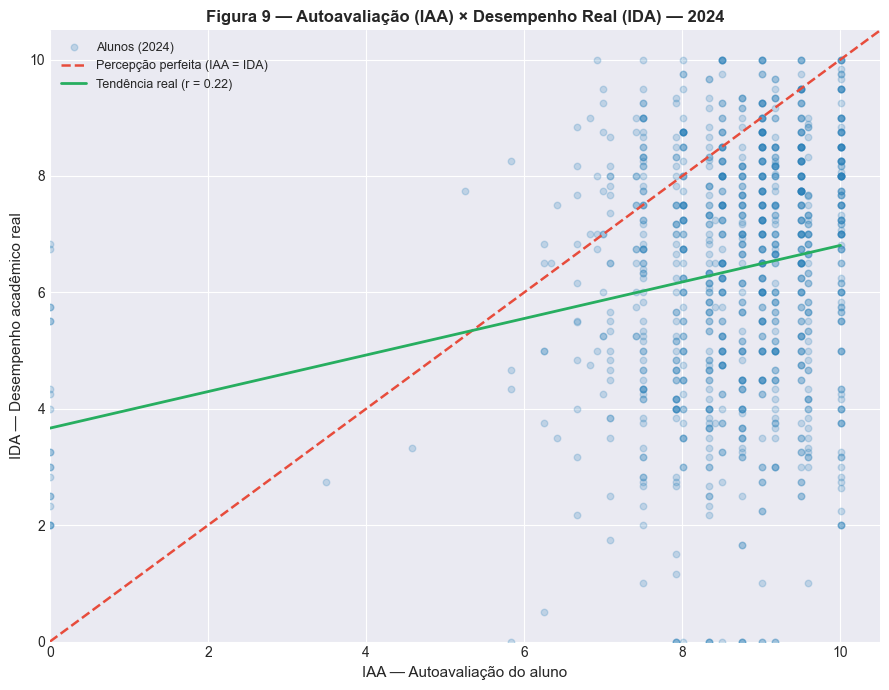

In [113]:
# ── Gráfico 1: Scatter IAA × IDA (2024) com linha de identidade e regressão ──

d_sc = df_2024[['IAA', 'IDA']].copy()
d_sc['IAA'] = pd.to_numeric(d_sc['IAA'], errors='coerce')
d_sc['IDA'] = pd.to_numeric(d_sc['IDA'], errors='coerce')
d_sc = d_sc.dropna()

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(d_sc['IAA'], d_sc['IDA'], alpha=0.22, s=22, color='#2980B9',
           label='Alunos (2024)', zorder=2)

# Linha de identidade — onde IAA = IDA (percepção perfeita)
lim = [0, 10.5]
ax.plot(lim, lim, '--', color='#E74C3C', lw=1.8, label='Percepção perfeita (IAA = IDA)', zorder=3)

# Linha de regressão
m, b, r_val, *_ = sp_stats.linregress(d_sc['IAA'], d_sc['IDA'])
xs = np.linspace(0, 10, 200)
ax.plot(xs, m * xs + b, '-', color='#27AE60', lw=2,
        label=f'Tendência real (r = {r_val:.2f})', zorder=4)

ax.set_xlim(0, 10.5)
ax.set_ylim(0, 10.5)
ax.set_xlabel('IAA — Autoavaliação do aluno', fontsize=11)
ax.set_ylabel('IDA — Desempenho acadêmico real', fontsize=11)
ax.set_title('Figura 9 — Autoavaliação (IAA) × Desempenho Real (IDA) — 2024',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


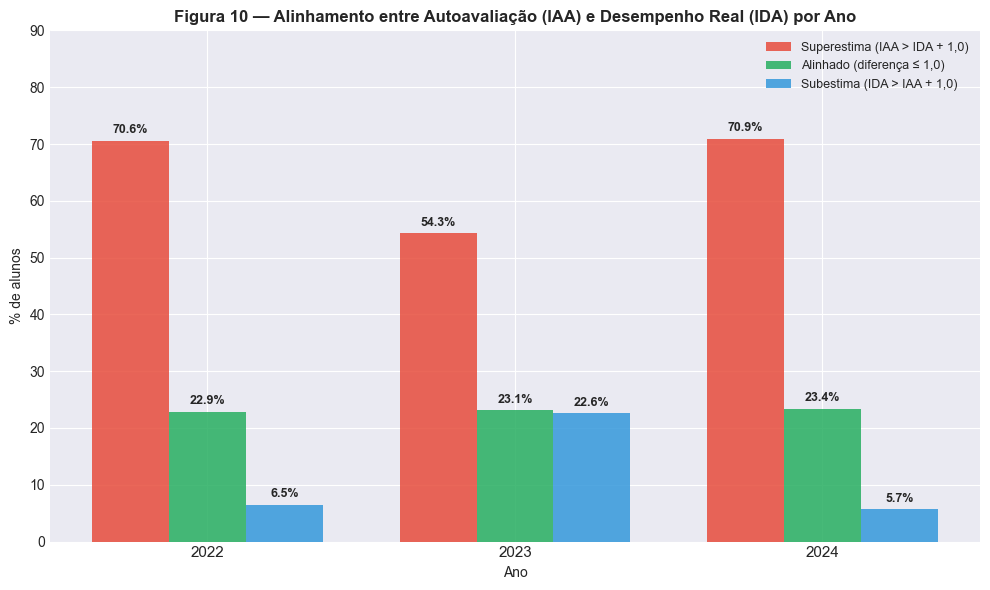

In [114]:
# ── Gráfico 2: % de alunos que superestima / está alinhado / subestima por ano ─

anos_gap = ['2022', '2023', '2024']
pct_sup  = [delta_tbl[a]['superestima'] for a in anos_gap]
pct_ali  = [delta_tbl[a]['alinhado']    for a in anos_gap]
pct_sub  = [delta_tbl[a]['subestima']   for a in anos_gap]

x   = np.arange(len(anos_gap))
w   = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x - w,   pct_sup, w, label='Superestima (IAA > IDA + 1,0)',
            color='#E74C3C', alpha=0.85)
b2 = ax.bar(x,       pct_ali, w, label='Alinhado (diferença ≤ 1,0)',
            color='#27AE60', alpha=0.85)
b3 = ax.bar(x + w,   pct_sub, w, label='Subestima (IDA > IAA + 1,0)',
            color='#3498DB', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(anos_gap, fontsize=11)
ax.set_ylim(0, 90)
ax.set_ylabel('% de alunos', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.set_title('Figura 10 — Alinhamento entre Autoavaliação (IAA) e Desempenho Real (IDA) por Ano',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


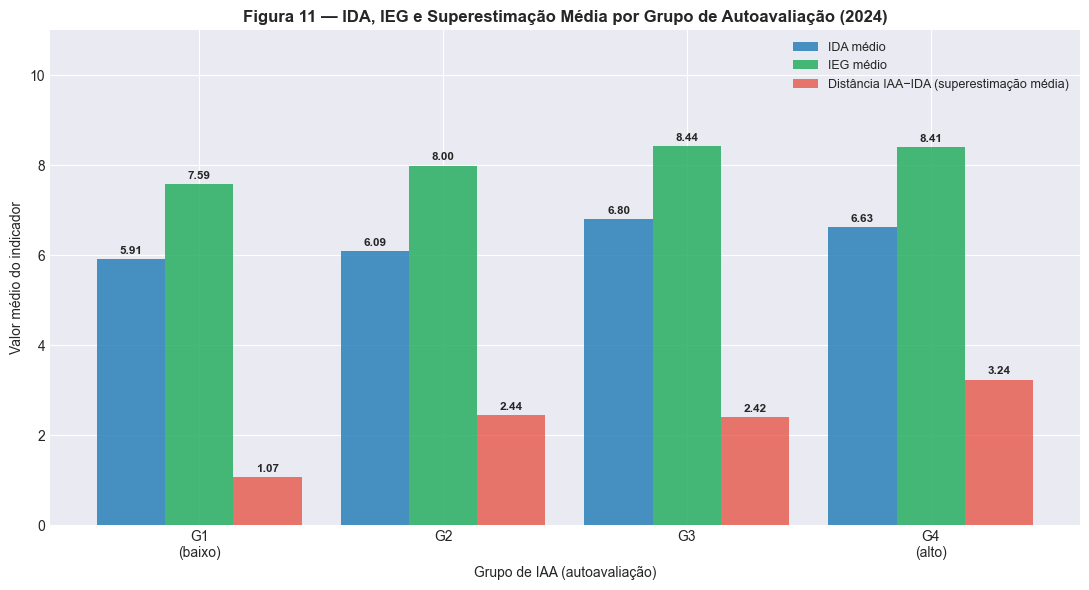

In [115]:
# ── Gráfico 3: IDA, IEG e Delta médios por grupo de IAA (2024) ────────────────

grupos_iaa = tbl_iaa.index.tolist()
x = np.arange(len(grupos_iaa))
w = 0.28

fig, ax1 = plt.subplots(figsize=(11, 6))

b1 = ax1.bar(x - w, tbl_iaa['IDA'], w, label='IDA médio',
             color='#2980B9', alpha=0.85)
b2 = ax1.bar(x,     tbl_iaa['IEG'], w, label='IEG médio',
             color='#27AE60', alpha=0.85)
b3 = ax1.bar(x + w, tbl_iaa['Delta'], w,
             label='Distância IAA−IDA (superestimação média)',
             color='#E74C3C', alpha=0.75)

for bars in [b1, b2, b3]:
    for bar in bars:
        v = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.07,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(grupos_iaa, fontsize=10)
ax1.set_ylim(0, 11)
ax1.set_ylabel('Valor médio do indicador', fontsize=10)
ax1.set_xlabel('Grupo de IAA (autoavaliação)', fontsize=10)
ax1.set_title('Figura 11 — IDA, IEG e Superestimação Média por Grupo de Autoavaliação (2024)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Pergunta 5 — Aspectos Psicossociais (IPS): Padrões que Antecedem Quedas de Desempenho ou Engajamento?


In [116]:
# ── Preparação: IPS — estatísticas, correlações e faixas ─────────────────────
from scipy import stats as sp_stats

ips_stats  = {}
ips_corr   = {}
ips_grupos = {}   # faixas fixas: baixo/médio/alto

FAIXAS_IPS = [0, 5.0, 7.0, 10.1]
LABELS_IPS = ['Baixo\n(≤5,0)', 'Médio\n(5,0–7,0)', 'Alto\n(>7,0)']

for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    tmp = df_src.copy()
    for col in ['IPS', 'IDA', 'IEG']:
        if col in tmp.columns:
            tmp[col] = pd.to_numeric(tmp[col], errors='coerce')

    d = tmp[['IPS', 'IDA', 'IEG']].dropna()

    ips_stats[ano] = {
        'n':      len(d),
        'média':  round(d['IPS'].mean(), 3),
        'mediana':round(d['IPS'].median(), 3),
        'std':    round(d['IPS'].std(), 3),
    }

    r_ida, p_ida = sp_stats.pearsonr(d['IPS'], d['IDA'])
    r_ieg, p_ieg = sp_stats.pearsonr(d['IPS'], d['IEG'])
    ips_corr[ano] = {
        'r_IDA': round(r_ida, 3), 'p_IDA': p_ida,
        'r_IEG': round(r_ieg, 3), 'p_IEG': p_ieg,
    }

    d = d.copy()
    d['IPS_F'] = pd.cut(d['IPS'], bins=FAIXAS_IPS, labels=LABELS_IPS, right=True)
    tbl = d.groupby('IPS_F', observed=False)[['IDA', 'IEG']].mean().round(3)
    ns  = d.groupby('IPS_F', observed=False).size().rename('n')
    ips_grupos[ano] = pd.concat([ns, tbl], axis=1)

print("=== IPS — Estatísticas por ano ===")
print(pd.DataFrame(ips_stats).T.to_string())
print("\n=== Correlações IPS × IDA e IPS × IEG ===")
print(pd.DataFrame(ips_corr).T.to_string())
print("\n=== IDA e IEG por faixa de IPS — 2024 ===")
print(ips_grupos['2024'].to_string())


=== IPS — Estatísticas por ano ===
           n  média  mediana    std
2022   860.0  6.905     7.50  1.071
2023   931.0  5.135     5.00  2.087
2024  1054.0  6.830     7.51  1.428

=== Correlações IPS × IDA e IPS × IEG ===
      r_IDA     p_IDA  r_IEG     p_IEG
2022  0.132  0.000104  0.093  0.006224
2023  0.132  0.000052  0.043  0.190710
2024  0.014  0.638351  0.061  0.048991

=== IDA e IEG por faixa de IPS — 2024 ===
                    n    IDA    IEG
IPS_F                              
Baixo\n(≤5,0)      88  6.234  7.698
Médio\n(5,0–7,0)  325  6.244  8.060
Alto\n(>7,0)      641  6.420  8.157


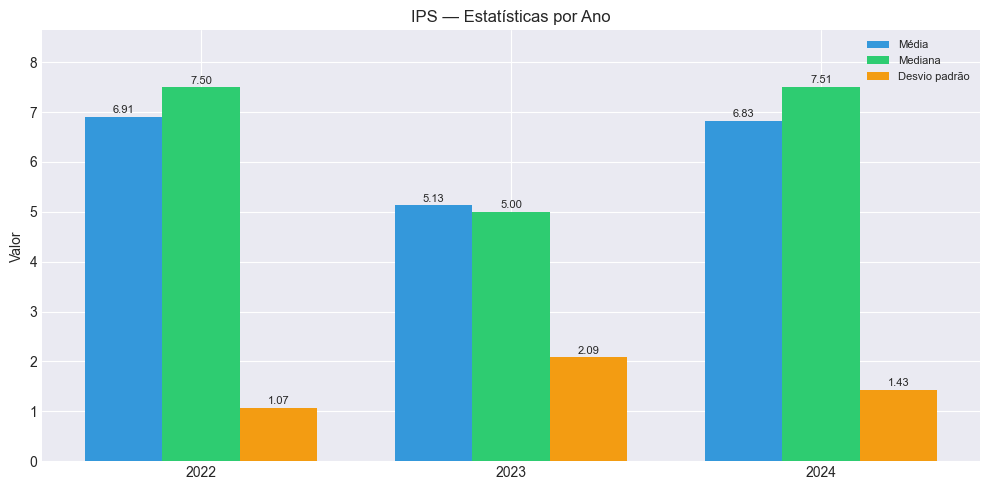

In [144]:
# DataFrames auxiliares para os gráficos de IPS
df_stats = pd.DataFrame(ips_stats).T
df_corr  = pd.DataFrame(ips_corr).T
tbl_2024 = ips_grupos['2024'].reindex(LABELS_IPS)

anos_ips = df_stats.index.tolist()
x_ips    = np.arange(len(anos_ips))

# Gráfico 1 — IPS: Estatísticas por Ano (média, mediana e desvio padrão)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.25

bars_media   = ax.bar(x_ips - w, df_stats['média'],   width=w, label='Média',         color='#3498DB')
bars_mediana = ax.bar(x_ips,     df_stats['mediana'], width=w, label='Mediana',       color='#2ECC71')
bars_std     = ax.bar(x_ips + w, df_stats['std'],     width=w, label='Desvio padrão', color='#F39C12')

# Labels com os valores em cada barra
for bars in [bars_media, bars_mediana, bars_std]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.03,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_xticks(x_ips)
ax.set_xticklabels(anos_ips)
ax.set_title('IPS — Estatísticas por Ano')
ax.set_ylabel('Valor')
ax.set_ylim(0, max(df_stats['média'].max(), df_stats['mediana'].max(), df_stats['std'].max()) * 1.15)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


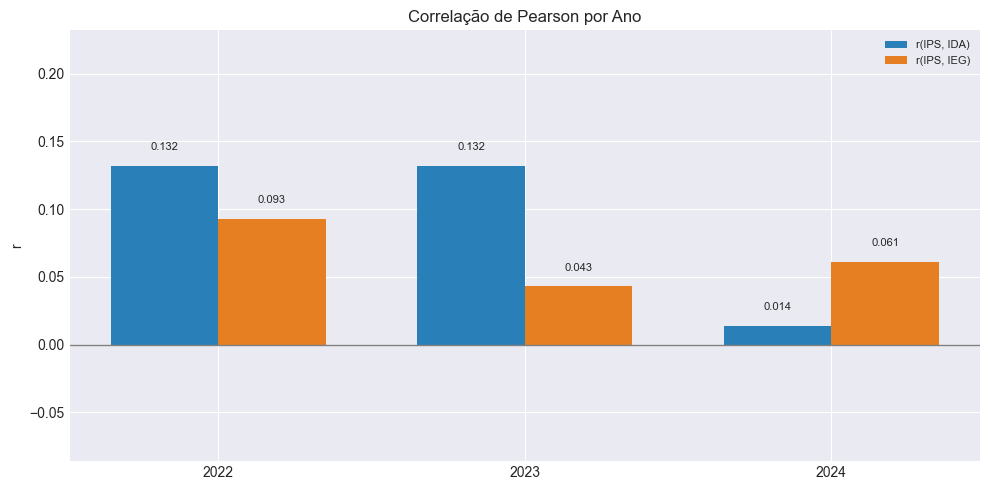

In [145]:

# Gráfico 2 — Correlação de Pearson: IPS × IDA e IPS × IEG
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.35
b1 = ax.bar(x_ips - w/2, df_corr['r_IDA'], width=w, label='r(IPS, IDA)', color='#2980B9')
b2 = ax.bar(x_ips + w/2, df_corr['r_IEG'], width=w, label='r(IPS, IEG)', color='#E67E22')
ax.axhline(0, color='gray', lw=1)
ax.set_xticks(x_ips)
ax.set_xticklabels(anos_ips)
ax.set_ylim(
    min(df_corr[['r_IDA', 'r_IEG']].min()) - 0.1,
    max(df_corr[['r_IDA', 'r_IEG']].max()) + 0.1
)
ax.set_title('Correlação de Pearson por Ano')
ax.set_ylabel('r')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + (0.01 if h >= 0 else -0.03),
            f'{h:.3f}',
            ha='center', va='bottom' if h >= 0 else 'top', fontsize=8
        )

plt.tight_layout()
plt.show()


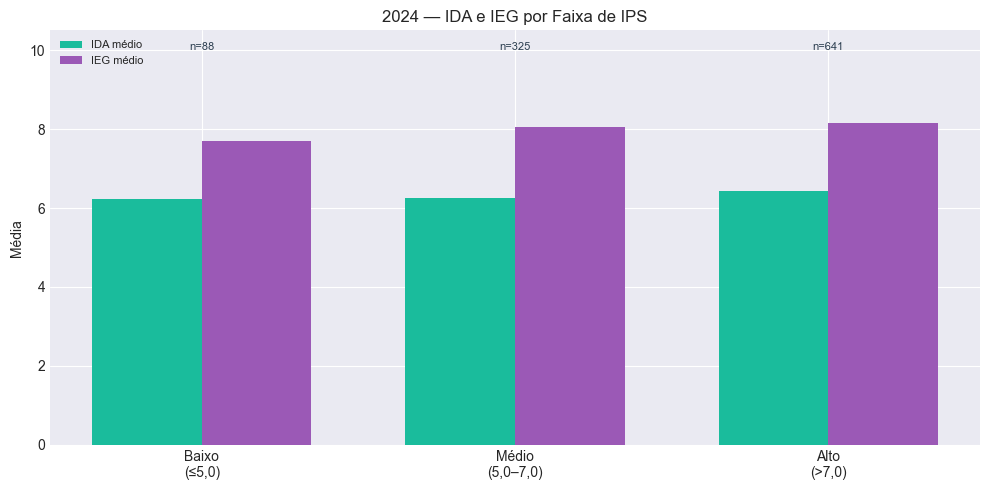

In [146]:

# Gráfico 3 — IDA e IEG por Faixa de IPS (2024)
fig, ax = plt.subplots(figsize=(10, 5))
x3 = np.arange(len(tbl_2024.index))
w3 = 0.35
b1 = ax.bar(x3 - w3/2, tbl_2024['IDA'], width=w3, label='IDA médio', color='#1ABC9C')
b2 = ax.bar(x3 + w3/2, tbl_2024['IEG'], width=w3, label='IEG médio', color='#9B59B6')
ax.set_xticks(x3)
ax.set_xticklabels(tbl_2024.index)
ax.set_ylim(0, 10.5)
ax.set_title('2024 — IDA e IEG por Faixa de IPS')
ax.set_ylabel('Média')
ax.legend(loc='upper left', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

for i, n in enumerate(tbl_2024['n'].fillna(0).astype(int).values):
    ax.text(i, 10.2, f'n={n}', ha='center', va='top', fontsize=8, color='#2C3E50')

plt.tight_layout()
plt.show()


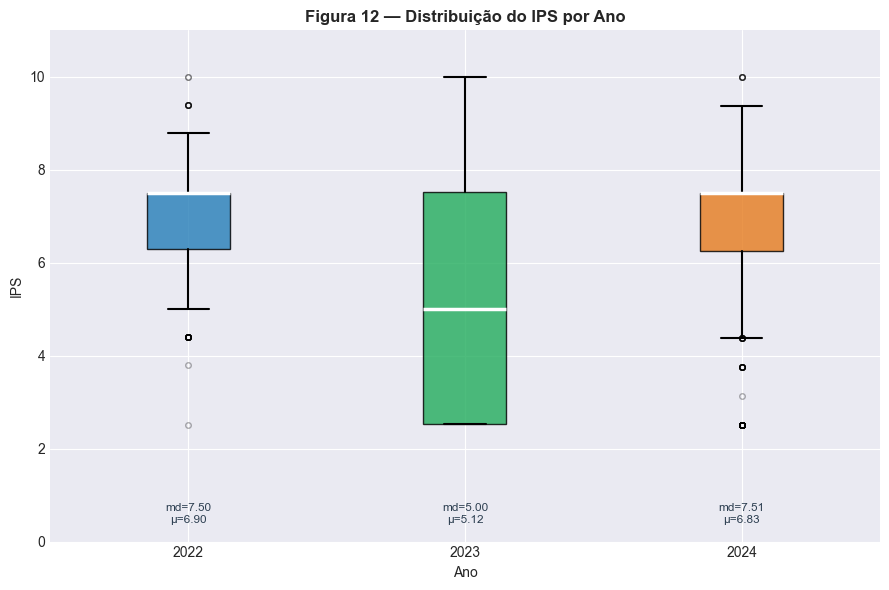

In [120]:
# ── Gráfico 1: Boxplot do IPS por ano — evolução da distribuição ──────────────

anos_ips = ['2022', '2023', '2024']
data_ips_box = []
for ano, df_src in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    s = pd.to_numeric(df_src['IPS'], errors='coerce').dropna()
    data_ips_box.append(s.values)

cores_ips = ['#2980B9', '#27AE60', '#E67E22']

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(
    data_ips_box, labels=anos_ips, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.3)
)
for patch, cor in zip(bp['boxes'], cores_ips):
    patch.set_facecolor(cor)
    patch.set_alpha(0.82)

for i, (ano, cor) in enumerate(zip(anos_ips, cores_ips), start=1):
    s = pd.to_numeric(
        [df_2022, df_2023, df_2024][i - 1]['IPS'], errors='coerce'
    ).dropna()
    ax.text(i, 0.4, f'md={s.median():.2f}\nμ={s.mean():.2f}',
            ha='center', fontsize=8.5, color='#2C3E50')

ax.set_ylabel('IPS', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.set_title('Figura 12 — Distribuição do IPS por Ano', fontsize=12, fontweight='bold')
ax.set_ylim(0, 11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


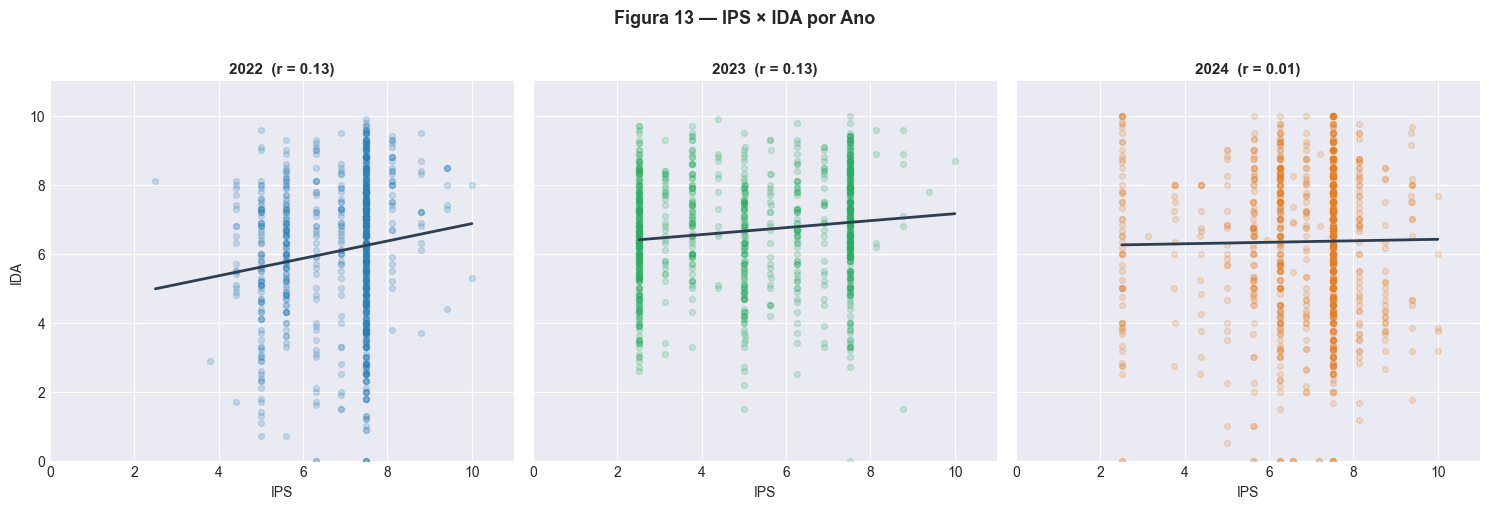

In [121]:
# ── Gráfico 2: Scatter IPS × IDA por ano (3 painéis) ─────────────────────────

anos_scatter = ['2022', '2023', '2024']
dfs_scatter  = [df_2022, df_2023, df_2024]
cores_sc     = ['#2980B9', '#27AE60', '#E67E22']

fig, axes_sc = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax_s, ano, df_src, cor in zip(axes_sc, anos_scatter, dfs_scatter, cores_sc):
    tmp = df_src[['IPS', 'IDA']].copy()
    tmp['IPS'] = pd.to_numeric(tmp['IPS'], errors='coerce')
    tmp['IDA'] = pd.to_numeric(tmp['IDA'], errors='coerce')
    tmp = tmp.dropna()

    ax_s.scatter(tmp['IPS'], tmp['IDA'], alpha=0.20, s=18, color=cor)

    m_s, b_s, r_s, *_ = sp_stats.linregress(tmp['IPS'], tmp['IDA'])
    xs_s = np.linspace(tmp['IPS'].min(), tmp['IPS'].max(), 200)
    ax_s.plot(xs_s, m_s * xs_s + b_s, '-', color='#2C3E50', lw=2)

    ax_s.set_title(f'{ano}  (r = {r_s:.2f})', fontsize=11, fontweight='bold')
    ax_s.set_xlabel('IPS', fontsize=10)
    ax_s.set_xlim(0, 11)
    ax_s.set_ylim(0, 11)
    ax_s.spines[['top', 'right']].set_visible(False)

axes_sc[0].set_ylabel('IDA', fontsize=10)
fig.suptitle('Figura 13 — IPS × IDA por Ano', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


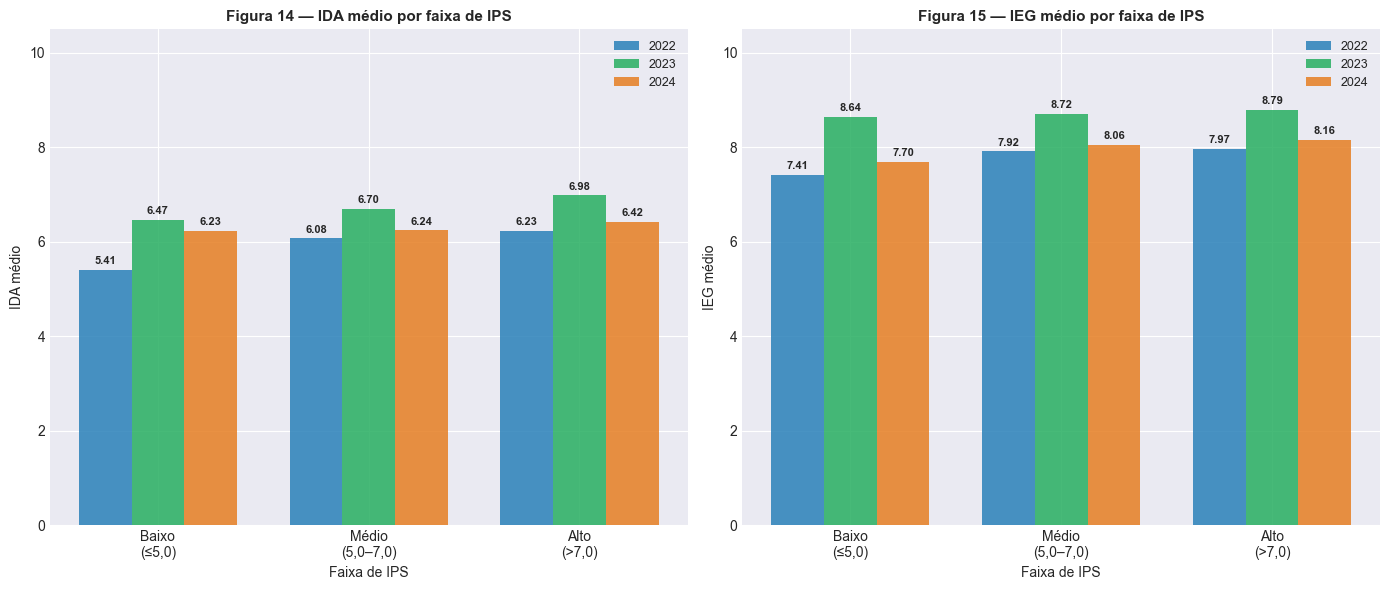

In [122]:
# ── Gráfico 3: IDA e IEG médios por faixa de IPS — comparação 2022/2023/2024 ─

cores_faixa = ['#E74C3C', '#F39C12', '#27AE60']   # baixo / médio / alto

fig, axes_f = plt.subplots(1, 2, figsize=(14, 6))

for ax_f, indicador, cor_ind, titulo_ind in [
    (axes_f[0], 'IDA', '#2980B9', 'IDA médio por faixa de IPS'),
    (axes_f[1], 'IEG', '#27AE60', 'IEG médio por faixa de IPS'),
]:
    x_pos = np.arange(len(LABELS_IPS))
    w_f   = 0.25

    for k, (ano, offset) in enumerate(
        zip(['2022', '2023', '2024'], [-w_f, 0, w_f])
    ):
        vals_f = [ips_grupos[ano].loc[lbl, indicador]
                  if lbl in ips_grupos[ano].index else np.nan
                  for lbl in LABELS_IPS]
        bars_f = ax_f.bar(x_pos + offset, vals_f, w_f,
                          label=ano, color=cores_anos[k], alpha=0.85)
        for bar_f, v_f in zip(bars_f, vals_f):
            if not np.isnan(v_f):
                ax_f.text(bar_f.get_x() + bar_f.get_width() / 2,
                          v_f + 0.08, f'{v_f:.2f}',
                          ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax_f.set_xticks(x_pos)
    ax_f.set_xticklabels(LABELS_IPS, fontsize=10)
    ax_f.set_ylim(0, 10.5)
    ax_f.set_ylabel(f'{indicador} médio', fontsize=10)
    ax_f.set_xlabel('Faixa de IPS', fontsize=10)
    ax_f.set_title(f'Figura {14 if indicador == "IDA" else 15} — {titulo_ind}',
                   fontsize=11, fontweight='bold')
    ax_f.legend(fontsize=9)
    ax_f.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## Pergunta 6 — Avaliação Psicopedagógica (IPP)
### As avaliações psicopedagógicas confirmam ou contradizem a defasagem identificada pelo IAN?

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# ── Pergunta 6: IPP × IAN ──────────────────────────────────────────────────
# NOTA: IPP (Indice de Avaliacao Psicopedagogica) esta disponivel apenas em 2023.
# A analise de IPP x IAN e feita para 2023; IDA x IAN e calculado para todos os anos.

_IAN_LABELS = {2.5: 'Defasagem\nSevera', 5.0: 'Defasagem\nModerada', 10.0: 'Nivel\nAdequado'}
_IAN_ORDER  = ['Defasagem\nSevera', 'Defasagem\nModerada', 'Nivel\nAdequado']

ipp_stats   = {}
ipp_por_ian = {}
box_ipp_ian = {}
conc_23     = None
ida_por_ian = {}

for ano, df in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    # IDA x IAN (todos os anos)
    if 'IDA' in df.columns and 'IAN' in df.columns:
        d_ida = df[['IDA', 'IAN']].copy()
        d_ida['IDA'] = pd.to_numeric(d_ida['IDA'], errors='coerce')
        d_ida['IAN'] = pd.to_numeric(d_ida['IAN'], errors='coerce')
        d_ida = d_ida.dropna()
        d_ida['IAN_cat'] = d_ida['IAN'].map(_IAN_LABELS)
        ida_por_ian[ano] = (
            d_ida.groupby('IAN_cat', observed=False)['IDA']
                 .mean()
                 .reindex(_IAN_ORDER)
                 .round(2)
        )

    # IPP x IAN (apenas anos com IPP)
    if 'IPP' not in df.columns:
        continue

    d = df[['IPP', 'IAN']].copy()
    d['IPP'] = pd.to_numeric(d['IPP'], errors='coerce')
    d['IAN'] = pd.to_numeric(d['IAN'], errors='coerce')
    d = d.dropna()

    ipp_stats[ano] = {
        'n':       len(d),
        'media':   round(d['IPP'].mean(),   3),
        'mediana': round(d['IPP'].median(), 3),
        'std':     round(d['IPP'].std(),    3),
    }

    d['IAN_cat'] = d['IAN'].map(_IAN_LABELS)
    ipp_por_ian[ano] = (
        d.groupby('IAN_cat', observed=False)['IPP']
         .mean()
         .reindex(_IAN_ORDER)
         .round(2)
    )
    box_ipp_ian[ano] = {
        cat: d.loc[d['IAN_cat'] == cat, 'IPP'].values
        for cat in _IAN_ORDER
    }

    ian_v = d['IAN'].values
    ipp_v = d['IPP'].values
    conds = [
        (ian_v == 10.0) & (ipp_v > 7.5),
        (ian_v <= 5.0)  & (ipp_v <= 7.5),
        (ian_v <= 5.0)  & (ipp_v > 7.5),
        (ian_v == 10.0) & (ipp_v <= 5.0),
    ]
    choices = [
        'Confirmam (adequado)', 'Confirmam (defasagem)',
        'Discordam (IPP acima)', 'Discordam (IPP abaixo)',
    ]
    d['conc'] = np.select(conds, choices, default='Parcial')
    if ano == '2023':
        conc_23 = d['conc'].value_counts(normalize=True).mul(100).round(1)

# ── Resumo ──
print("=== Anos com IPP disponivel ===")
print(f"  {list(ipp_stats.keys())} (demais anos sem IPP na base)")

print("\n=== IPP estatisticas (2023) ===")
for ano, v in ipp_stats.items():
    print(f"  {ano} (n={v['n']}): media={v['media']:.2f}  mediana={v['mediana']:.2f}  dp={v['std']:.2f}")

print("\n=== IPP medio por categoria IAN ===")
for ano, s in ipp_por_ian.items():
    print(f"  {ano}: " + "  |  ".join(f"{k.replace(chr(10),' ')}={v:.2f}" for k, v in s.items()))

print("\n=== IDA medio por categoria IAN (todos os anos) ===")
for ano, s in ida_por_ian.items():
    print(f"  {ano}: " + "  |  ".join(f"{k.replace(chr(10),' ')}={v:.2f}" for k, v in s.items()))

if conc_23 is not None:
    print("\n=== Concordancia IPP x IAN - 2023 ===")
    conc_total = sum(v for k, v in conc_23.items() if k.startswith('Confirmam'))
    print(f"  Total concordancia: {conc_total:.1f}%  |  Discordancia/parcial: {100-conc_total:.1f}%")
    for cat, pct in conc_23.sort_values(ascending=False).items():
        print(f"    {cat}: {pct:.1f}%")

=== Anos com IPP disponivel ===
  ['2023', '2024'] (demais anos sem IPP na base)

=== IPP estatisticas (2023) ===
  2023 (n=938): media=7.56  mediana=7.66  dp=0.98
  2024 (n=1054): media=7.55  mediana=7.50  dp=0.90

=== IPP medio por categoria IAN ===
  2023: Defasagem Severa=6.96  |  Defasagem Moderada=7.50  |  Nivel Adequado=7.67
  2024: Defasagem Severa=7.26  |  Defasagem Moderada=7.41  |  Nivel Adequado=7.69

=== IDA medio por categoria IAN (todos os anos) ===
  2022: Defasagem Severa=4.38  |  Defasagem Moderada=6.01  |  Nivel Adequado=6.47
  2023: Defasagem Severa=4.98  |  Defasagem Moderada=6.52  |  Nivel Adequado=6.92
  2024: Defasagem Severa=5.67  |  Defasagem Moderada=6.22  |  Nivel Adequado=6.49

=== Concordancia IPP x IAN - 2023 ===
  Total concordancia: 54.5%  |  Discordancia/parcial: 45.5%
    Confirmam (defasagem): 30.6%
    Discordam (IPP acima): 28.0%
    Confirmam (adequado): 23.9%
    Parcial: 16.8%
    Discordam (IPP abaixo): 0.6%


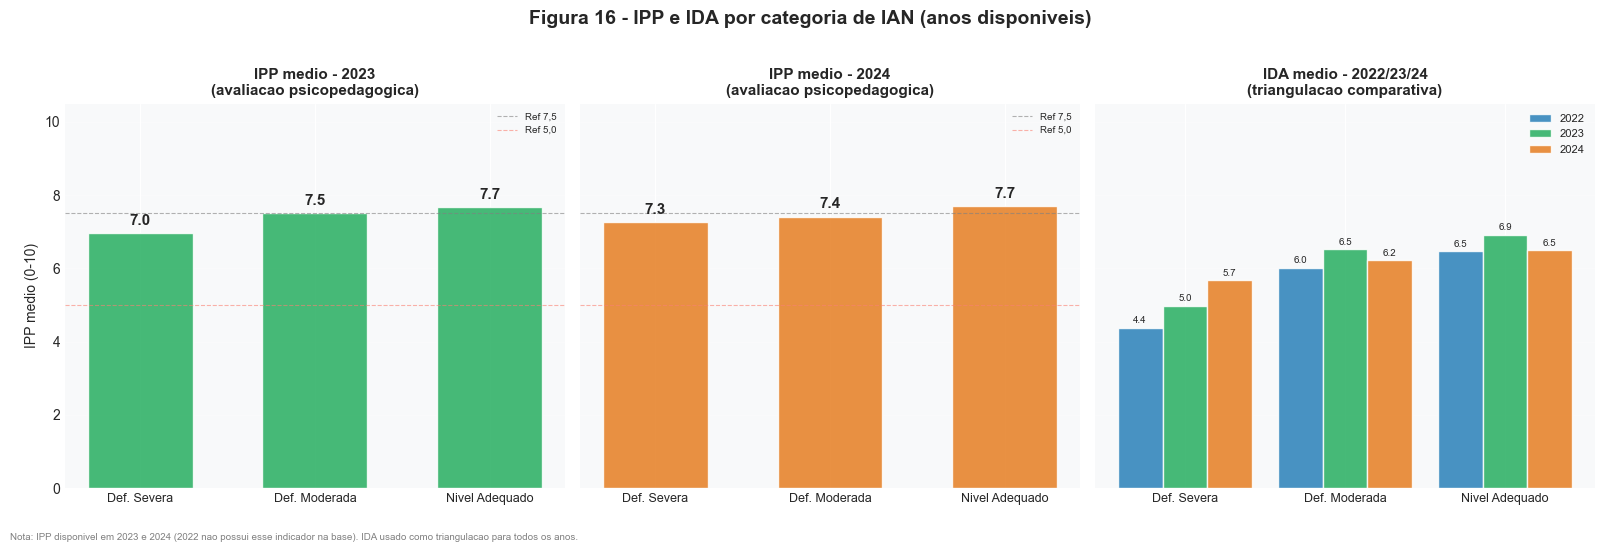

In [124]:
fig, axes_ipp = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Figura 16 - IPP e IDA por categoria de IAN (anos disponiveis)',
             fontsize=14, fontweight='bold', y=1.02)

cats_label = ['Def. Severa', 'Def. Moderada', 'Nivel Adequado']
x_pos = np.arange(len(_IAN_ORDER))

anos_ipp = [a for a in ['2022', '2023', '2024'] if a in ipp_por_ian]
anos_all  = ['2022', '2023', '2024']

# Paineis 0 e 1: IPP medio por categoria IAN (2023 e 2024)
for idx, (ano, cor) in enumerate([(a, cores_anos[['2022','2023','2024'].index(a)])
                                   for a in anos_ipp]):
    ax = axes_ipp[idx]
    vals = ipp_por_ian[ano].values
    bars = ax.bar(x_pos, vals, color=cor, alpha=0.85, edgecolor='white', width=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cats_label, fontsize=9)
    ax.set_title(f'IPP medio - {ano}\n(avaliacao psicopedagogica)',
                 fontsize=11, fontweight='bold')
    ax.set_ylim(0, 10.5)
    ax.set_ylabel('IPP medio (0-10)' if idx == 0 else '')
    ax.axhline(7.5, color='gray',   linestyle='--', linewidth=0.8, alpha=0.6, label='Ref 7,5')
    ax.axhline(5.0, color='salmon', linestyle='--', linewidth=0.8, alpha=0.6, label='Ref 5,0')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#F8F9FA')

# Painel 2: IDA medio todos os anos (triangulacao)
ax = axes_ipp[2]
w = 0.28
for i, (ano, cor) in enumerate(zip(anos_all, cores_anos)):
    if ano not in ida_por_ian:
        continue
    vals_ida = ida_por_ian[ano].values
    bars2 = ax.bar(x_pos + (i - 1)*w, vals_ida, w,
                   label=ano, color=cor, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars2, vals_ida):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.07,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels(cats_label, fontsize=9)
ax.set_title('IDA medio - 2022/23/24\n(triangulacao comparativa)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')

fig.text(0, -0.04,
         'Nota: IPP disponivel em 2023 e 2024 (2022 nao possui esse indicador na base). '
         'IDA usado como triangulacao para todos os anos.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

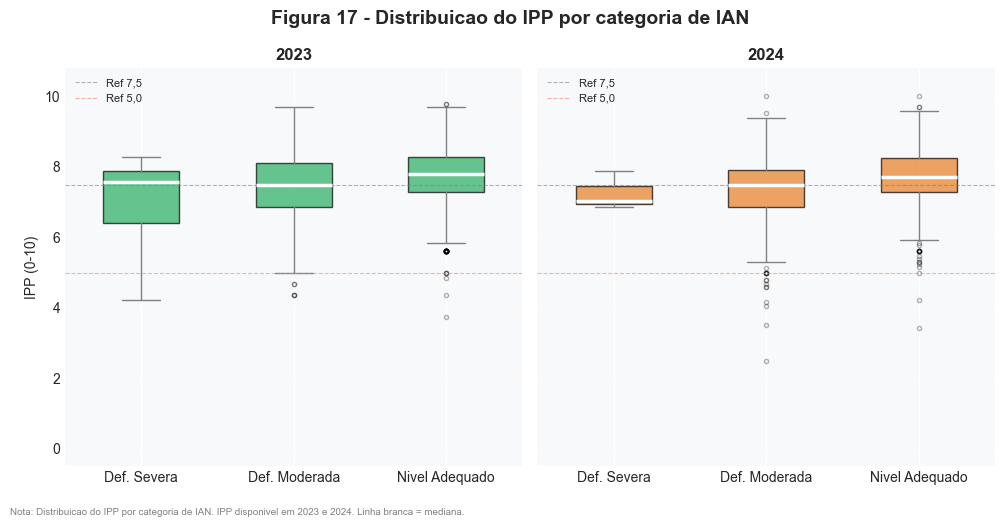

In [125]:
anos_ipp_disp = [a for a in ['2022', '2023', '2024'] if a in box_ipp_ian]
fig, axes_box = plt.subplots(1, len(anos_ipp_disp), figsize=(5*len(anos_ipp_disp), 5),
                             sharey=True)
if len(anos_ipp_disp) == 1:
    axes_box = [axes_box]

fig.suptitle('Figura 17 - Distribuicao do IPP por categoria de IAN',
             fontsize=14, fontweight='bold')

cats_label_short = ['Def. Severa', 'Def. Moderada', 'Nivel Adequado']

for ax, ano in zip(axes_box, anos_ipp_disp):
    cor = cores_anos[['2022','2023','2024'].index(ano)]
    data_plot = [box_ipp_ian[ano].get(cat, np.array([np.nan])) for cat in _IAN_ORDER]
    bp = ax.boxplot(
        data_plot,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=cor, alpha=0.7),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='gray', linewidth=1),
        capprops=dict(color='gray', linewidth=1),
        flierprops=dict(marker='o', color=cor, alpha=0.3, markersize=3),
    )
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(cats_label_short, fontsize=10)
    ax.set_title(ano, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.5, 10.8)
    ax.set_ylabel('IPP (0-10)' if ano == anos_ipp_disp[0] else '')
    ax.axhline(7.5, color='gray',   linestyle='--', linewidth=0.8, alpha=0.6, label='Ref 7,5')
    ax.axhline(5.0, color='salmon', linestyle='--', linewidth=0.8, alpha=0.6, label='Ref 5,0')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#F8F9FA')

fig.text(0, -0.03,
         'Nota: Distribuicao do IPP por categoria de IAN. '
         'IPP disponivel em 2023 e 2024. Linha branca = mediana.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

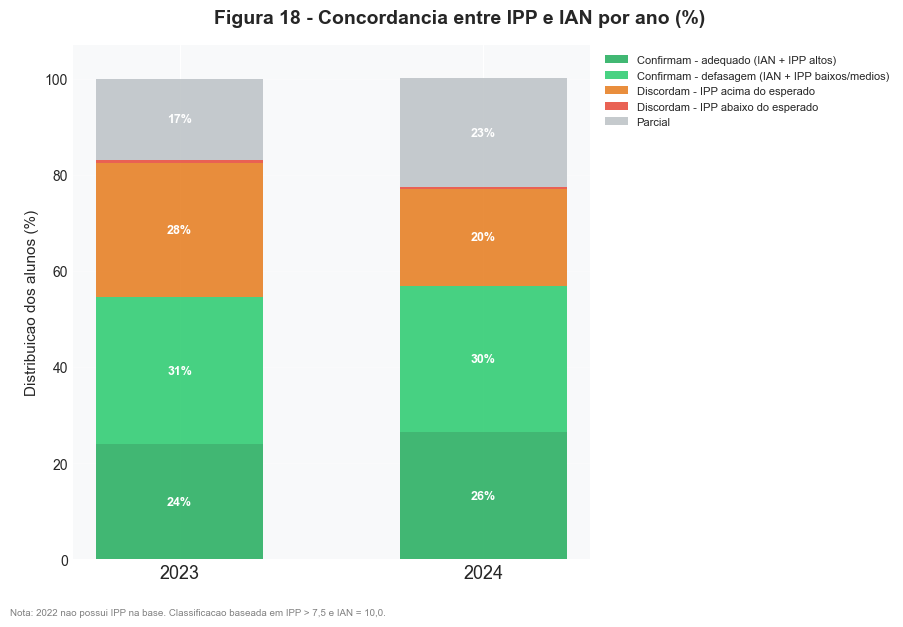

In [ ]:
_CONC_CATS  = ['Confirmam (adequado)', 'Confirmam (defasagem)',
               'Discordam (IPP acima)', 'Discordam (IPP abaixo)', 'Parcial']
_CONC_CORES = ['#27AE60', '#2ECC71', '#E67E22', '#E74C3C', '#BDC3C7']
_CONC_LEGND = ['Confirmam - adequado (IAN + IPP altos)',
               'Confirmam - defasagem (IAN + IPP baixos/medios)',
               'Discordam - IPP acima do esperado',
               'Discordam - IPP abaixo do esperado',
               'Parcial']

# Anos com IPP disponível para análise de concordância
anos_conc = [a for a in ['2023', '2024'] if a in ipp_por_ian]
x_pos_c   = np.arange(len(anos_conc))
width_c   = 0.55

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Figura 18 - Concordancia entre IPP e IAN por ano (%)',
             fontsize=14, fontweight='bold')

# Recalcula a concordância entre IPP e IAN para todos os anos disponíveis
# Classifica cada aluno em uma das categorias:
#   - Confirmam (adequado): IAN = 10 (nível adequado) E IPP > 7,5
#   - Confirmam (defasagem): IAN <= 5 (defasagem) E IPP <= 7,5
#   - Discordam (IPP acima): IAN indica defasagem mas IPP está alto (> 7,5)
#   - Discordam (IPP abaixo): IAN indica adequado mas IPP está baixo (<= 5,0)
#   - Parcial: demais casos que não se encaixam nas categorias acima
conc_anos_ipp = {}
for ano, df in [('2023', df_2023), ('2024', df_2024)]:
    # Verifica se as colunas necessárias existem no DataFrame do ano
    if 'IPP' not in df.columns or 'IAN' not in df.columns:
        continue

    # Prepara os dados: converte para numérico e remove valores ausentes
    d = df[['IPP', 'IAN']].copy()
    d['IPP'] = pd.to_numeric(d['IPP'], errors='coerce')
    d['IAN'] = pd.to_numeric(d['IAN'], errors='coerce')
    d = d.dropna()

    ian_v = d['IAN'].values
    ipp_v = d['IPP'].values

    # Define as condições de classificação para cada categoria de concordância
    conds = [
        (ian_v == 10.0) & (ipp_v > 7.5),   # Ambos indicam nível adequado
        (ian_v <= 5.0)  & (ipp_v <= 7.5),  # Ambos indicam defasagem
        (ian_v <= 5.0)  & (ipp_v > 7.5),   # IAN indica defasagem, IPP contradiz
        (ian_v == 10.0) & (ipp_v <= 5.0),  # IAN indica adequado, IPP contradiz
    ]
    choices = ['Confirmam (adequado)', 'Confirmam (defasagem)',
               'Discordam (IPP acima)', 'Discordam (IPP abaixo)']

    # Aplica a classificação; casos restantes são marcados como 'Parcial'
    d['conc'] = np.select(conds, choices, default='Parcial')

    # Calcula a distribuição percentual de cada categoria por ano
    conc_anos_ipp[ano] = d['conc'].value_counts(normalize=True).mul(100).round(1)

# Constrói o gráfico de barras empilhadas com as categorias de concordância
bottom_arr = np.zeros(len(anos_conc))  # Controla o empilhamento das barras
for cat, cor, leg in zip(_CONC_CATS, _CONC_CORES, _CONC_LEGND):
    # Obtém os valores percentuais de cada categoria para cada ano
    vals = np.array([conc_anos_ipp[a].get(cat, 0.0) for a in anos_conc])
    bars = ax.bar(x_pos_c, vals, width_c, bottom=bottom_arr,
                  color=cor, alpha=0.88, label=leg)

    # Adiciona rótulos dentro das barras (apenas se o segmento for visível)
    for bar, v in zip(bars, vals):
        if v > 4.5:  # Exibe o rótulo somente quando há espaço suficiente
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')

    # Atualiza a base de empilhamento para a próxima categoria
    bottom_arr += vals

# Formatação do eixo e legenda
ax.set_xticks(x_pos_c)
ax.set_xticklabels(anos_conc, fontsize=13)
ax.set_ylim(0, 107)
ax.set_ylabel('Distribuicao dos alunos (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1.0))
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')

# Nota de rodapé explicando a ausência de 2022 e o critério de classificação
fig.text(0, -0.03,
         'Nota: 2022 nao possui IPP na base. '
         'Classificacao baseada em IPP > 7,5 e IAN = 10,0.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## Pergunta 7 — Ponto de Virada (IPV)
### Quais comportamentos acadêmicos e socioeducativos marcam o ponto de virada do aluno?

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# ── Pergunta 7: IPV — Ponto de Virada ─────────────────────────────────────
# Identificar quais indicadores mais se associam ao IPV (Índice de Ponto de Virada)

INDS_IPV = ['IDA', 'IEG', 'IAN', 'IAA', 'IPS', 'IPP']

ipv_stats   = {}  # estatísticas descritivas do IPV por ano
ipv_corr    = {}  # correlação de cada indicador com IPV, por ano
perfis_ipv  = {}  # perfil médio dos indicadores: Alto IPV vs Baixo IPV
ipv_arrays  = {}  # arrays de IPV por ano para boxplot

for ano, df in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    cols_disp = ['IPV'] + [c for c in INDS_IPV if c in df.columns]
    d = df[cols_disp].copy()
    for c in d.columns:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d_ipv = d.dropna(subset=['IPV'])

    s_ipv = d_ipv['IPV']
    ipv_stats[ano] = {
        'n':       len(s_ipv),
        'media':   round(s_ipv.mean(),   3),
        'mediana': round(s_ipv.median(), 3),
        'std':     round(s_ipv.std(),    3),
    }
    ipv_arrays[ano] = s_ipv.values

    # Correlações IPV × cada indicador
    corrs = {}
    for ind in INDS_IPV:
        if ind in d_ipv.columns:
            dd = d_ipv[['IPV', ind]].dropna()
            if len(dd) > 20:
                r, _ = sp_stats.pearsonr(dd['IPV'], dd[ind])
                corrs[ind] = round(float(r), 3)
    ipv_corr[ano] = corrs

    # Perfis: metade superior (Alto IPV) vs metade inferior (Baixo IPV)
    med_ipv = s_ipv.median()
    d_ipv = d_ipv.copy()
    d_ipv['ipv_grupo'] = np.where(d_ipv['IPV'] >= med_ipv, 'Alto IPV', 'Baixo IPV')
    inds_disp = [c for c in INDS_IPV if c in d_ipv.columns]
    perfis_ipv[ano] = (
        d_ipv.groupby('ipv_grupo')[inds_disp]
             .mean()
             .round(2)
    )

# ── Resumo ──
print("=== IPV estatísticas por ano ===")
for ano, v in ipv_stats.items():
    print(f"  {ano} (n={v['n']}): média={v['media']:.2f}  mediana={v['mediana']:.2f}  dp={v['std']:.2f}")

print("\n=== Correlações IPV × indicadores ===")
for ano, corrs in ipv_corr.items():
    print(f"  {ano}: " + "  |  ".join(f"{k}={v:.3f}" for k, v in corrs.items()))

print("\n=== Perfis IPV (2024) ===")
print(perfis_ipv.get('2024', 'N/A'))

=== IPV estatísticas por ano ===
  2022 (n=860): média=7.25  mediana=7.33  dp=1.09
  2023 (n=938): média=8.03  mediana=8.04  dp=0.94
  2024 (n=1054): média=7.35  mediana=7.50  dp=1.05

=== Correlações IPV × indicadores ===
  2022: IDA=0.617  |  IEG=0.589  |  IAN=0.111  |  IAA=0.256  |  IPS=0.208
  2023: IDA=0.544  |  IEG=0.449  |  IAN=0.147  |  IAA=0.138  |  IPS=0.078  |  IPP=0.516
  2024: IDA=0.514  |  IEG=0.535  |  IAN=0.185  |  IAA=0.148  |  IPS=0.105  |  IPP=0.750

=== Perfis IPV (2024) ===
            IDA   IEG   IAN   IAA   IPS   IPP
ipv_grupo                                    
Alto IPV   7.27  8.80  7.80  8.76  6.90  8.03
Baixo IPV  5.36  7.32  7.09  8.31  6.75  7.03


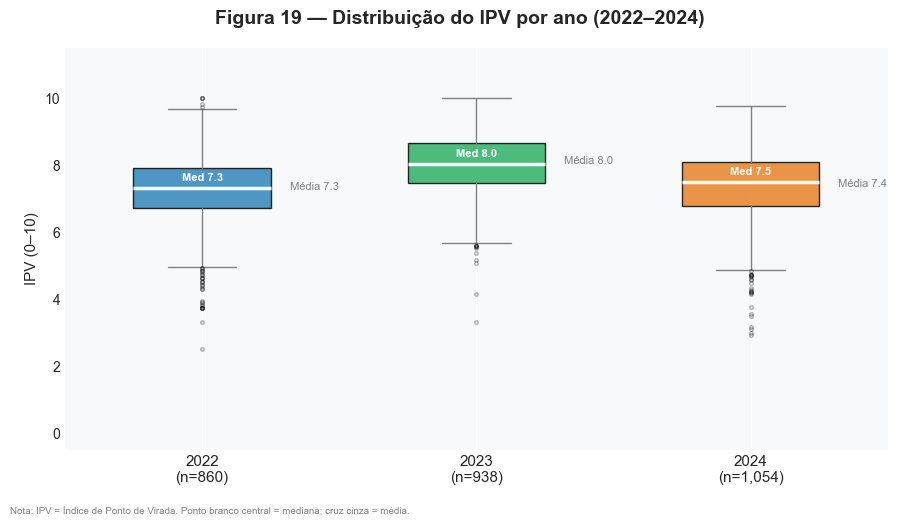

In [128]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figura 19 — Distribuição do IPV por ano (2022–2024)',
             fontsize=14, fontweight='bold')

labels_ipv = [f"{ano}\n(n={ipv_stats[ano]['n']:,})" for ano in ['2022', '2023', '2024']]
data_ipv   = [ipv_arrays[ano] for ano in ['2022', '2023', '2024']]

bp = ax.boxplot(
    data_ipv,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color='gray', linewidth=1),
    capprops=dict(color='gray', linewidth=1),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3),
)
for patch, cor in zip(bp['boxes'], cores_anos):
    patch.set_facecolor(cor)
    patch.set_alpha(0.82)
for flier, cor in zip(bp['fliers'], cores_anos):
    flier.set_color(cor)

# Anotar média e mediana
for i, ano in enumerate(['2022', '2023', '2024']):
    med = ipv_stats[ano]['mediana']
    mn  = ipv_stats[ano]['media']
    ax.text(i + 1, med + 0.20, f'Med {med:.1f}',
            ha='center', fontsize=8, color='white', fontweight='bold', zorder=5)
    ax.text(i + 1 + 0.32, mn, f'Média {mn:.1f}',
            ha='left', fontsize=8, color='gray')

ax.set_xticklabels(labels_ipv, fontsize=11)
ax.set_ylabel('IPV (0–10)', fontsize=11)
ax.set_ylim(-0.5, 11.5)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')
fig.text(0, -0.03,
         'Nota: IPV = Índice de Ponto de Virada. '
         'Ponto branco central = mediana; cruz cinza = média.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

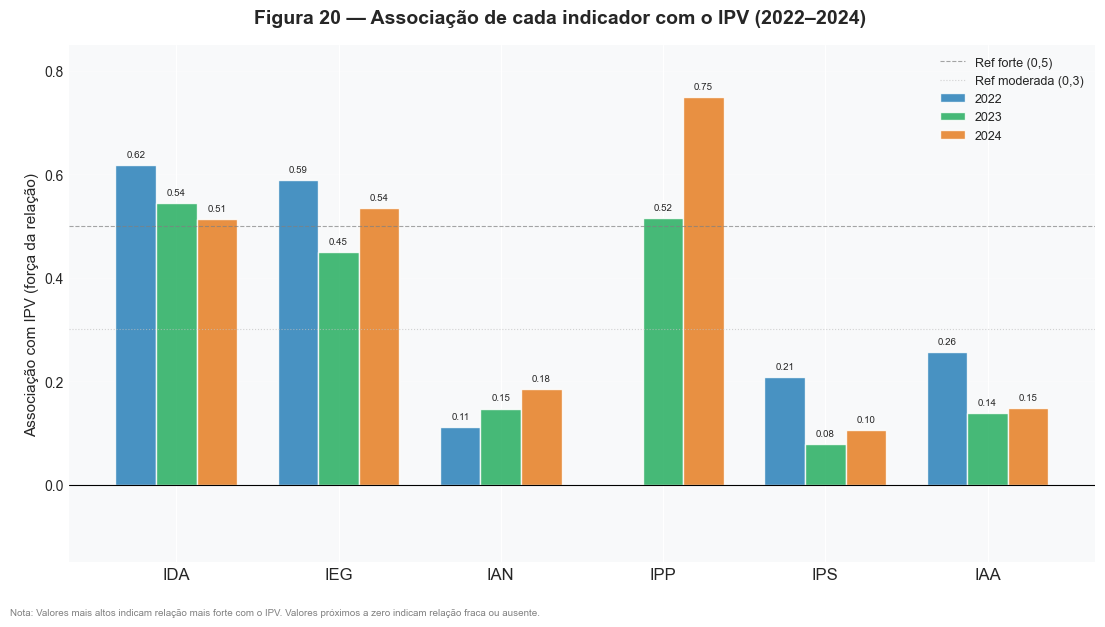

In [129]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Figura 20 — Associação de cada indicador com o IPV (2022–2024)',
             fontsize=14, fontweight='bold')

inds_plot = ['IDA', 'IEG', 'IAN', 'IPP', 'IPS', 'IAA']
x_pos  = np.arange(len(inds_plot))
width  = 0.25

for i, (ano, cor) in enumerate(zip(['2022', '2023', '2024'], cores_anos)):
    vals = [ipv_corr[ano].get(ind, np.nan) for ind in inds_plot]
    bars = ax.bar(x_pos + i * width, vals, width,
                  label=ano, color=cor, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            yoff = 0.012 if v >= 0 else -0.035
            va   = 'bottom' if v >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2, v + yoff,
                    f'{v:.2f}', ha='center', va=va, fontsize=7)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(inds_plot, fontsize=12)
ax.set_ylabel('Associação com IPV (força da relação)', fontsize=11)
ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline(0.5, color='gray',  linestyle='--', linewidth=0.8, alpha=0.7, label='Ref forte (0,5)')
ax.axhline(0.3, color='silver', linestyle=':', linewidth=0.8, alpha=0.7, label='Ref moderada (0,3)')
ax.set_ylim(-0.15, 0.85)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')

fig.text(0, -0.03,
         'Nota: Valores mais altos indicam relação mais forte com o IPV. '
         'Valores próximos a zero indicam relação fraca ou ausente.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

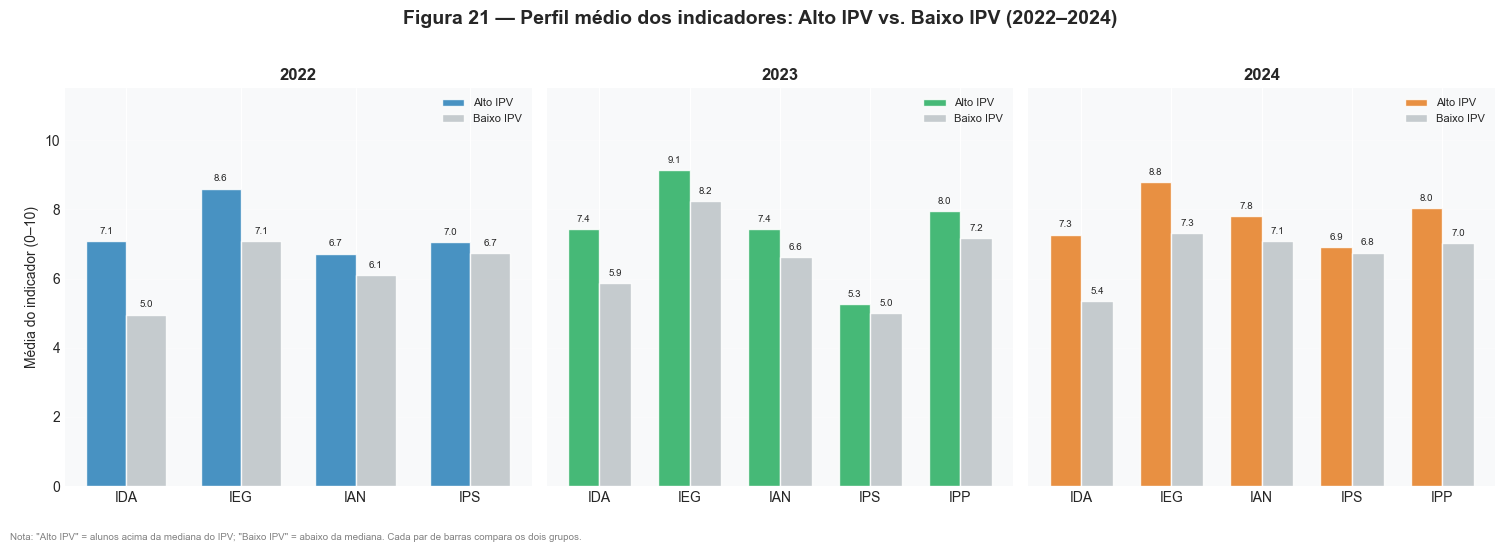

In [130]:
inds_perf = ['IDA', 'IEG', 'IAN', 'IPS', 'IPP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Figura 21 — Perfil médio dos indicadores: Alto IPV vs. Baixo IPV (2022–2024)',
             fontsize=14, fontweight='bold', y=1.02)

w = 0.35

for ax, ano, cor in zip(axes, ['2022', '2023', '2024'], cores_anos):
    perf = perfis_ipv[ano]
    cols_disp = [c for c in inds_perf if c in perf.columns]
    x_d = np.arange(len(cols_disp))

    alto = (perf.loc['Alto IPV',  cols_disp].values
            if 'Alto IPV'  in perf.index else np.full(len(cols_disp), np.nan))
    baix = (perf.loc['Baixo IPV', cols_disp].values
            if 'Baixo IPV' in perf.index else np.full(len(cols_disp), np.nan))

    b1 = ax.bar(x_d - w/2, alto, w, label='Alto IPV',
                color=cor, alpha=0.85, edgecolor='white')
    b2 = ax.bar(x_d + w/2, baix, w, label='Baixo IPV',
                color='#BDC3C7', alpha=0.85, edgecolor='white')

    ax.set_xticks(x_d)
    ax.set_xticklabels(cols_disp, fontsize=10)
    ax.set_title(ano, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 11.5)
    ax.set_ylabel('Média do indicador (0–10)' if ano == '2022' else '')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#F8F9FA')

    # Valores sobre as barras
    for bar, v in list(zip(b1, alto)) + list(zip(b2, baix)):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.15,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)

fig.text(0, -0.04,
         'Nota: "Alto IPV" = alunos acima da mediana do IPV; '
         '"Baixo IPV" = abaixo da mediana. Cada par de barras compara os dois grupos.',
         fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## Pergunta 8 — Multidimensionalidade dos Indicadores × INDE

In [131]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# ── Pergunta 8: Multidimensionalidade dos indicadores × INDE ──────────────────

def _find_inde(df):
    for cand in ['INDE 2024', 'INDE 2023', 'INDE 2022', 'INDE']:
        if cand in df.columns:
            return cand
    return None

_ORDER_Q8 = ['IDA', 'IEG', 'IPS', 'IPP']  # ordem preferida de exibição

# Base 2024 — mais completa (tem IPP)
inde24_col = _find_inde(df_2024)
inds24 = [i for i in _ORDER_Q8 if i in df_2024.columns]
d24 = df_2024[inds24 + [inde24_col]].copy().apply(pd.to_numeric, errors='coerce').dropna()

# Correlações de cada indicador com INDE  (2024)
corrs_q8 = {ind: round(d24[ind].corr(d24[inde24_col]), 3) for ind in inds24}

# Classificação Alto/Baixo pela mediana de cada indicador
for ind in inds24:
    d24[f'{ind}_G'] = (d24[ind] >= d24[ind].median()).astype(int)

d24['n_altos'] = d24[[f'{ind}_G' for ind in inds24]].sum(axis=1)

# INDE médio por nº de indicadores em alta (0–4)
inde_por_naltos = (
    d24.groupby('n_altos')[inde24_col]
       .agg(['mean', 'std', 'count'])
       .reset_index()
       .rename(columns={'mean': 'INDE_medio', 'std': 'INDE_dp', 'count': 'n'})
)

# Todas as combinações (2^4 = 16) — rótulo "IND+/−"
d24['COMBO'] = d24.apply(
    lambda r: '  '.join([f'{ind}{"+" if r[f"{ind}_G"] else "-"}' for ind in inds24]),
    axis=1
)
combo_inde = (
    d24.groupby('COMBO')
       .agg(INDE_medio=(inde24_col, 'mean'), n=('n_altos', 'count'))
       .reset_index()
       .query('n >= 5')
       .assign(n_altos_combo=lambda x: x['COMBO'].str.count(r'\+'))
       .sort_values('INDE_medio', ascending=False)
       .reset_index(drop=True)
)

inde24_med = d24[inde24_col].median()

print(f"INDE: {inde24_col}  |  n={len(d24)} alunos com dados completos (2024)")
print(f"Correlações com INDE: {corrs_q8}")
print(f"\nINDE por nº de indicadores acima da mediana:")
print(inde_por_naltos.to_string(index=False))
print(f"\nTop 5 combinações:")
print(combo_inde.head().to_string(index=False))
print(f"\nBottom 5:")
print(combo_inde.tail().to_string(index=False))


INDE: INDE 2024  |  n=1054 alunos com dados completos (2024)
Correlações com INDE: {'IDA': np.float64(0.802), 'IEG': np.float64(0.787), 'IPS': np.float64(0.225), 'IPP': np.float64(0.637)}

INDE por nº de indicadores acima da mediana:
 n_altos  INDE_medio  INDE_dp   n
       0    5.953451 0.782201 101
       1    6.557227 0.722508 214
       2    7.166857 0.673050 243
       3    8.013118 0.493968 303
       4    8.404355 0.466014 193

Top 5 combinações:
                 COMBO  INDE_medio   n  n_altos_combo
IDA+  IEG+  IPS+  IPP+    8.404355 193              4
IDA+  IEG+  IPS-  IPP+    8.320238 128              3
IDA+  IEG+  IPS+  IPP-    7.892325  26              3
IDA+  IEG-  IPS+  IPP+    7.816596  76              3
IDA-  IEG+  IPS+  IPP+    7.722226  73              3

Bottom 5:
                 COMBO  INDE_medio   n  n_altos_combo
IDA+  IEG-  IPS-  IPP-    6.842122  26              1
IDA-  IEG-  IPS+  IPP+    6.790010 100              2
IDA-  IEG-  IPS-  IPP+    6.509956  55       

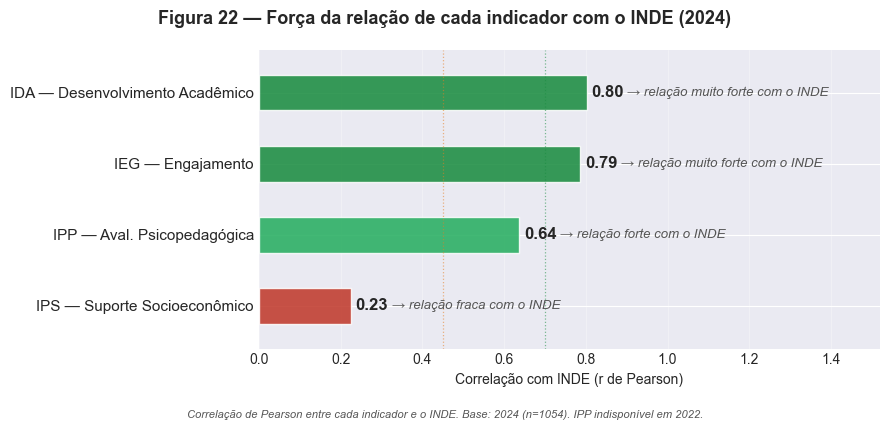

In [132]:

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Figura 22 — Força da relação de cada indicador com o INDE (2024)',
             fontsize=13, fontweight='bold')

# Ordenação decrescente por correlação
_ord22 = sorted(inds24, key=lambda x: corrs_q8[x], reverse=True)
vals22 = [corrs_q8[i] for i in _ord22]

nomes_full_q8 = {
    'IDA': 'IDA — Desenvolvimento Acadêmico',
    'IEG': 'IEG — Engajamento',
    'IPP': 'IPP — Aval. Psicopedagógica',
    'IPS': 'IPS — Suporte Socioeconômico',
}

def _cor22(r):
    if r >= 0.70: return '#1a8c40'
    if r >= 0.45: return '#27ae60'
    if r >= 0.25: return '#e67e22'
    return '#c0392b'

y22 = np.arange(len(_ord22))
ax.barh(y22, vals22, color=[_cor22(v) for v in vals22],
        alpha=0.87, height=0.50, edgecolor='white', linewidth=1)

for y, v, ind in zip(y22, vals22, _ord22):
    ax.text(v + 0.012, y, f'{v:.2f}', va='center', ha='left', fontsize=12, fontweight='bold')
    if v >= 0.70:   leg = 'relação muito forte com o INDE'
    elif v >= 0.45: leg = 'relação forte com o INDE'
    elif v >= 0.25: leg = 'relação moderada com o INDE'
    else:           leg = 'relação fraca com o INDE'
    ax.text(v + 0.10, y, f'→ {leg}', va='center', ha='left',
            fontsize=9.5, color='#555555', style='italic')

ax.set_yticks(y22)
ax.set_yticklabels([nomes_full_q8[i] for i in _ord22], fontsize=11)
ax.set_xlabel('Correlação com INDE (r de Pearson)', fontsize=10)
ax.set_xlim(0, 1.52)
ax.set_ylim(-0.6, len(_ord22) - 0.4)
ax.invert_yaxis()
ax.axvline(0.70, color='#1a8c40', lw=0.9, ls=':', alpha=0.55)
ax.axvline(0.45, color='#e67e22', lw=0.9, ls=':', alpha=0.55)
ax.xaxis.grid(True, alpha=0.30)
ax.set_axisbelow(True)

fig.text(0.5, -0.04,
         f'Correlação de Pearson entre cada indicador e o INDE. Base: 2024 (n={len(d24)}). IPP indisponível em 2022.',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()


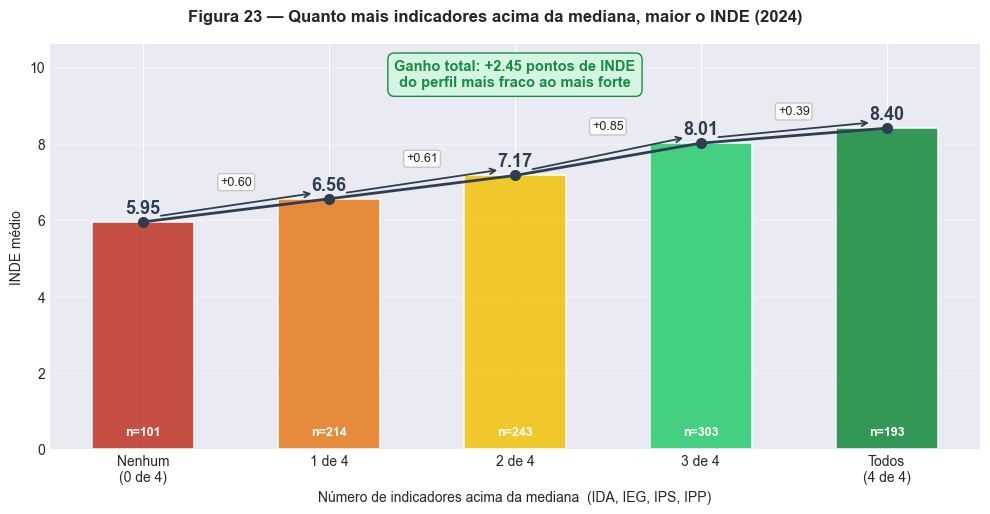

In [150]:

fig, ax = plt.subplots(figsize=(10, 5.2))
fig.suptitle('Figura 23 — Quanto mais indicadores acima da mediana, maior o INDE (2024)',
             fontsize=12, fontweight='bold')

pal23 = {0: '#c0392b', 1: '#e67e22', 2: '#f1c40f', 3: '#2ecc71', 4: '#1a8c40'}
xs23 = inde_por_naltos['n_altos'].astype(int).values
ys23 = inde_por_naltos['INDE_medio'].values
ns23 = inde_por_naltos['n'].astype(int).values

ax.bar(xs23, ys23, color=[pal23[x] for x in xs23],
       alpha=0.88, width=0.55, edgecolor='white', linewidth=1.2, zorder=3)

# Linha conectando os topos
ax.plot(xs23, ys23, 'o-', color='#2c3e50', lw=2, ms=7, zorder=5)

# INDE médio acima + n dentro
for x, y, n in zip(xs23, ys23, ns23):
    ax.text(x, y + 0.12, f'{y:.2f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='#2c3e50')
    ax.text(x, 0.30, f'n={n}', ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold')

# Ganho (+Δ) entre grupos consecutivos
for i in range(1, len(xs23)):
    delta = ys23[i] - ys23[i-1]
    mid_x = (xs23[i] + xs23[i-1]) / 2
    ax.annotate('', xy=(xs23[i] - 0.08, ys23[i] + 0.15),
                xytext=(xs23[i-1] + 0.08, ys23[i-1] + 0.15),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.3))
    ax.text(mid_x, max(ys23[i], ys23[i-1]) + 0.28, f'+{delta:.2f}',
            ha='center', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#fdfefe',
                      edgecolor='#bdc3c7', alpha=0.9))

ax.set_xticks(xs23)
ax.set_xticklabels(['Nenhum\n(0 de 4)', '1 de 4', '2 de 4', '3 de 4', 'Todos\n(4 de 4)'],
                   fontsize=10)
ax.set_xlabel('Número de indicadores acima da mediana  (IDA, IEG, IPS, IPP)', fontsize=10)
ax.set_ylabel('INDE médio', fontsize=10)
ax.set_ylim(0, max(ys23) + 2.2)
ax.yaxis.grid(True, alpha=0.35)
ax.set_axisbelow(True)

ganho23 = ys23[-1] - ys23[0]
ax.text(2, max(ys23) + 1.4,
        f'Ganho total: +{ganho23:.2f} pontos de INDE\ndo perfil mais fraco ao mais forte',
        ha='center', va='center', fontsize=10.5, color='#1a8c40', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#d5f5e3', edgecolor='#1a8c40'))

plt.tight_layout()
plt.show()


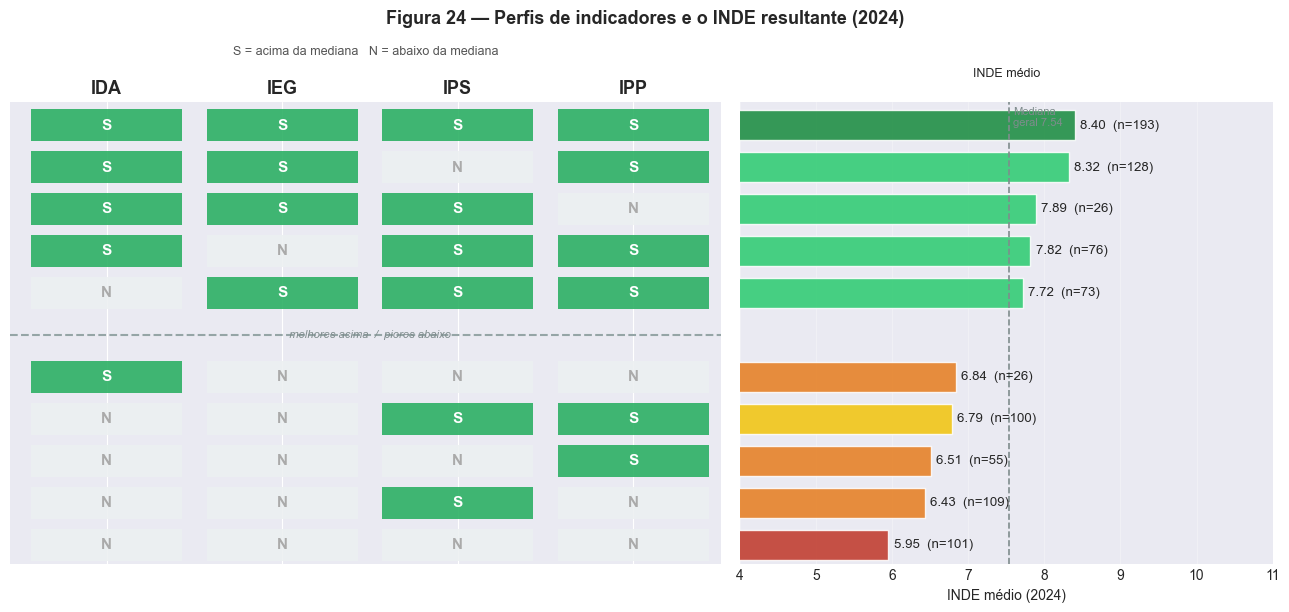

In [134]:

# ── Figura 24: Melhores e piores combinações ─────────────────────────────────
top5_24 = combo_inde.head(5).copy()
bot5_24 = combo_inde.tail(5).copy()

sep_row = pd.DataFrame({'COMBO': ['···'], 'INDE_medio': [np.nan],
                        'n': [np.nan], 'n_altos_combo': [-1]})
selected24 = pd.concat([top5_24, sep_row, bot5_24], ignore_index=True)
nrows24 = len(selected24)

inds_mat = ['IDA', 'IEG', 'IPS', 'IPP']

def _ind_on(combo, ind):
    return f'{ind}+' in combo

fig, (ax_m24, ax_b24) = plt.subplots(1, 2, figsize=(13, 6.2),
                                      gridspec_kw={'width_ratios': [2, 1.5]})
fig.suptitle('Figura 24 — Perfis de indicadores e o INDE resultante (2024)',
             fontsize=13, fontweight='bold')

# ── Painel esquerdo: Matriz ● / ○ ─────────────────────────────────────────────
for r, row in enumerate(selected24.itertuples()):
    if row.COMBO == '···':
        ax_m24.axhline(r, color='#95a5a6', lw=1.5, ls='--')
        ax_m24.text(len(inds_mat) / 2 - 0.5, r,
                    '  melhores acima  /  piores abaixo  ',
                    va='center', ha='center', fontsize=8,
                    color='#7f8c8d', style='italic')
        continue
    for c, ind in enumerate(inds_mat):
        active = _ind_on(row.COMBO, ind)
        bg = '#27ae60' if active else '#ecf0f1'
        fc = 'white' if active else '#aaaaaa'
        ax_m24.add_patch(Rectangle([c - 0.43, r - 0.38], 0.86, 0.76,
                                   color=bg, alpha=0.88, linewidth=0))
        ax_m24.text(c, r, 'S' if active else 'N',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold', color=fc)

ax_m24.set_xlim(-0.55, len(inds_mat) - 0.5)
ax_m24.set_ylim(nrows24 - 0.55, -0.55)
ax_m24.set_xticks(range(len(inds_mat)))
ax_m24.set_xticklabels(inds_mat, fontsize=13, fontweight='bold')
ax_m24.xaxis.set_ticks_position('top')
ax_m24.xaxis.set_label_position('top')
ax_m24.set_yticks([])
for sp in ax_m24.spines.values():
    sp.set_visible(False)
ax_m24.set_title('S = acima da mediana   N = abaixo da mediana',
                 fontsize=9, color='#555555', pad=18)

# ── Painel direito: Barra INDE ────────────────────────────────────────────────
pal24 = {0: '#c0392b', 1: '#e67e22', 2: '#f1c40f', 3: '#2ecc71', 4: '#1a8c40'}

for r, row in enumerate(selected24.itertuples()):
    if row.COMBO == '···' or (isinstance(row.INDE_medio, float) and np.isnan(row.INDE_medio)):
        continue
    n_alt = int(row.n_altos_combo)
    ax_b24.barh(r, row.INDE_medio, color=pal24.get(n_alt, '#aaaaaa'),
                alpha=0.87, height=0.72, edgecolor='white')
    ax_b24.text(row.INDE_medio + 0.07, r,
                f'{row.INDE_medio:.2f}  (n={int(row.n)})',
                va='center', ha='left', fontsize=9.5)

ax_b24.set_xlim(4.0, 11.0)
ax_b24.set_ylim(nrows24 - 0.55, -0.55)
ax_b24.set_yticks([])
ax_b24.axvline(inde24_med, color='#7f8c8d', lw=1.2, ls='--')
ax_b24.text(inde24_med + 0.05, -0.45,
            f'Mediana\ngeral {inde24_med:.2f}',
            fontsize=8, color='#7f8c8d', va='top')
ax_b24.set_xlabel('INDE médio (2024)', fontsize=10)
ax_b24.xaxis.grid(True, alpha=0.30)
ax_b24.set_axisbelow(True)
ax_b24.set_title('INDE médio', fontsize=9, pad=18)
for sp in ['top', 'left', 'right']:
    ax_b24.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()


## Pergunta 9 — Efetividade do Programa: Evolução por Fase (Quartzo → Topázio)

In [135]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── Pergunta 9 — Efetividade do programa por fase ────────────────────────────

FASES_ORD_Q9   = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
CORES_FASES_Q9 = {'Quartzo':'#e74c3c', 'Ágata':'#e67e22',
                  'Ametista':'#3498db', 'Topázio':'#27ae60'}

def _norm_fase(s):
    """Normaliza grafia das fases (Agata → Ágata; filtra INCLUIR)."""
    if pd.isna(s): return np.nan
    s = str(s).strip()
    m = {'Agata': 'Ágata', 'agata': 'Ágata', 'Ágata': 'Ágata',
         'Quartzo': 'Quartzo', 'Ametista': 'Ametista', 'Topázio': 'Topázio'}
    return m.get(s, np.nan)   # NaN filtra 'INCLUIR' e outros

# ── 1. INDE médio e distribuição por fase × ano ───────────────────────────────
config_anos = [
    ('2022', df_2022, 'Pedra 22',   'INDE 22'),
    ('2023', df_2023, 'Pedra 2023', 'INDE 2023'),
    ('2024', df_2024, 'Pedra 2024', 'INDE 2024'),
]

inde_fase_ano = {}   # {ano: {fase: media_inde}}
n_fase_ano    = {}   # {ano: {fase: n}}
dist_fases_q9 = {}   # {ano: {fase: pct}}

for ano, df, pcol, icol in config_anos:
    d = df[[pcol, icol]].copy()
    d['fase']  = d[pcol].apply(_norm_fase)
    d['inde']  = pd.to_numeric(d[icol], errors='coerce')
    d = d.dropna()
    grp = d.groupby('fase')['inde'].agg(['mean','count'])
    inde_fase_ano[ano] = grp['mean'].to_dict()
    n_fase_ano[ano]    = grp['count'].to_dict()
    total = d['fase'].value_counts().sum()
    dist_fases_q9[ano] = {f: d['fase'].value_counts().get(f, 0) / total * 100
                          for f in FASES_ORD_Q9}

# ── 2. Perfil de indicadores por fase (2024) ─────────────────────────────────
INDS_Q9 = ['IDA', 'IEG', 'IPS', 'IAA', 'IPP']
inds_disp_q9 = [i for i in INDS_Q9 if i in df_2024.columns]
d24_q9 = df_2024[['Pedra 2024'] + inds_disp_q9].copy()
d24_q9['fase'] = d24_q9['Pedra 2024'].apply(_norm_fase)
for c in inds_disp_q9:
    d24_q9[c] = pd.to_numeric(d24_q9[c], errors='coerce')
perfil_q9 = d24_q9.dropna(subset=['fase']).groupby('fase')[inds_disp_q9].mean().round(2)

# ── 3. Longitudinal: alunos com INDE em 2022 e 2024 (mesma base df_2024) ──────
nome_col_24 = 'Nome Anonimizado' if 'Nome Anonimizado' in df_2024.columns else 'NOME'
long_q9 = df_2024[[nome_col_24, 'Pedra 2024', 'INDE 2024', 'INDE 22']].copy()
long_q9.rename(columns={nome_col_24: 'NOME'}, inplace=True)
long_q9['fase24']   = long_q9['Pedra 2024'].apply(_norm_fase)
long_q9['inde24']   = pd.to_numeric(long_q9['INDE 2024'], errors='coerce')
long_q9['inde22']   = pd.to_numeric(long_q9['INDE 22'],   errors='coerce')
long_q9 = long_q9.dropna(subset=['fase24','inde24','inde22']).copy()
long_q9['delta']    = long_q9['inde24'] - long_q9['inde22']
long_q9['melhorou'] = (long_q9['delta'] > 0).astype(int)

# Resumo longitudinal por fase de destino
long_resumo = long_q9.groupby('fase24').agg(
    n         = ('delta', 'count'),
    inde22_med= ('inde22', 'mean'),
    inde24_med= ('inde24', 'mean'),
    delta_med = ('delta', 'mean'),
    pct_melhora= ('melhorou', 'mean'),
).round(3)
long_resumo['pct_melhora'] = (long_resumo['pct_melhora']*100).round(1)

# ── Impressão de diagnóstico ──────────────────────────────────────────────────
print("INDE médio por fase × ano:")
for ano in ['2022','2023','2024']:
    vals = {f: f'{inde_fase_ano[ano].get(f,"—"):.2f}' for f in FASES_ORD_Q9}
    print(f"  {ano}: {vals}")

print(f"\nPerfil de indicadores por fase (2024):")
print(perfil_q9.to_string())

print(f"\nAlunos rastreados 2022→2024: n={len(long_q9)}")
print(long_resumo.to_string())

print(f"\nDistribuição de fases por ano (%):")
for f in FASES_ORD_Q9:
    row = {a: f'{dist_fases_q9[a].get(f,0):.1f}%' for a in ['2022','2023','2024']}
    print(f"  {f}: {row}")


INDE médio por fase × ano:
  2022: {'Quartzo': '5.24', 'Ágata': '6.61', 'Ametista': '7.53', 'Topázio': '8.37'}
  2023: {'Quartzo': '5.55', 'Ágata': '6.57', 'Ametista': '7.51', 'Topázio': '8.44'}
  2024: {'Quartzo': '5.40', 'Ágata': '6.60', 'Ametista': '7.53', 'Topázio': '8.47'}

Perfil de indicadores por fase (2024):
           IDA   IEG   IPS   IAA   IPP
fase                                  
Ametista  6.57  8.46  6.94  8.71  7.58
Quartzo   3.11  5.04  5.96  7.22  6.47
Topázio   8.19  9.40  7.09  9.00  8.19
Ágata     4.92  7.07  6.70  8.24  7.11

Alunos rastreados 2022→2024: n=445
            n  inde22_med  inde24_med  delta_med  pct_melhora
fase24                                                       
Ametista  137       7.344       7.492      0.147         52.6
Quartzo    52       6.737       5.370     -1.366          7.7
Topázio   151       7.973       8.503      0.529         88.1
Ágata     105       6.878       6.607     -0.271         34.3

Distribuição de fases por ano (%):
  Q

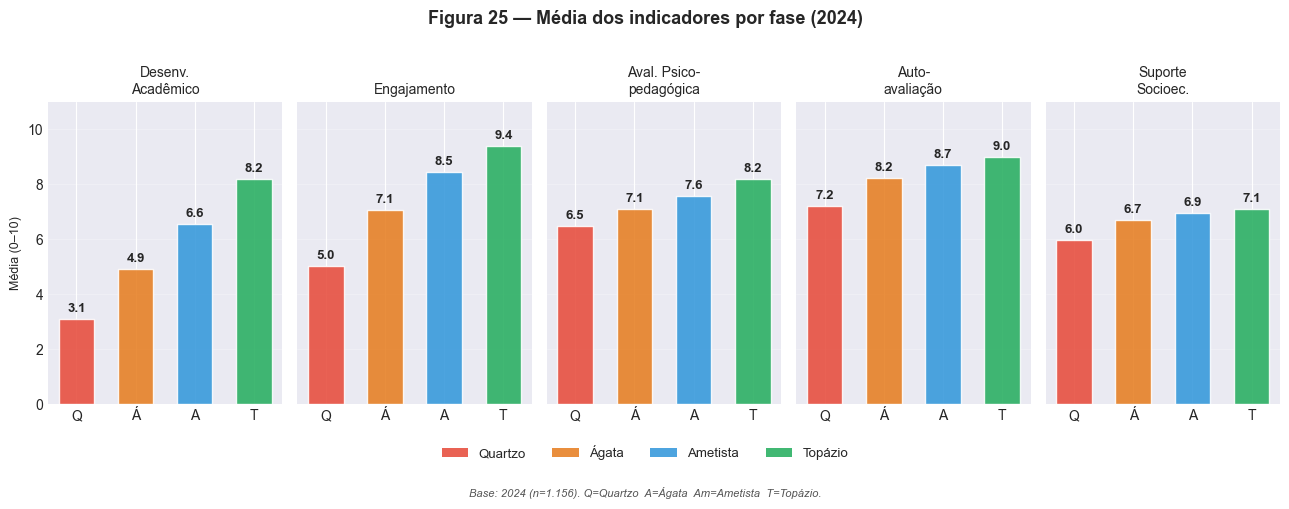

In [136]:

# Figura 25 — versão simplificada: 1 barra por fase, 1 painel por indicador
_inds_plot_q9 = ['IDA', 'IEG', 'IPP', 'IAA', 'IPS']
_nomes_q9 = {'IDA':'Desenv.\nAcadêmico', 'IEG':'Engajamento',
             'IPP':'Aval. Psico-\npedagógica', 'IAA':'Auto-\navaliação',
             'IPS':'Suporte\nSocioec.'}

fig, axes = plt.subplots(1, len(_inds_plot_q9), figsize=(13, 4.2), sharey=True)
fig.suptitle('Figura 25 — Média dos indicadores por fase (2024)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, ind in zip(axes, _inds_plot_q9):
    vals = [perfil_q9.loc[f, ind] if f in perfil_q9.index else 0 for f in FASES_ORD_Q9]
    bars = ax.bar(range(4), vals,
                  color=[CORES_FASES_Q9[f] for f in FASES_ORD_Q9],
                  alpha=0.88, width=0.6, edgecolor='white')
    for xi, v in enumerate(vals):
        ax.text(xi, v + 0.15, f'{v:.1f}', ha='center', va='bottom',
                fontsize=9.5, fontweight='bold')
    ax.set_title(_nomes_q9[ind], fontsize=10, pad=6)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f[0] for f in FASES_ORD_Q9], fontsize=10)  # Q A Am T
    ax.set_ylim(0, 11)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

axes[0].set_ylabel('Média (0–10)', fontsize=9)

from matplotlib.patches import Patch as _P25
leg_handles = [_P25(facecolor=CORES_FASES_Q9[f], label=f, alpha=0.88) for f in FASES_ORD_Q9]
fig.legend(handles=leg_handles, loc='lower center', ncol=4,
           fontsize=9.5, framealpha=0.85, bbox_to_anchor=(0.5, -0.08))
fig.text(0.5, -0.14, 'Base: 2024 (n=1.156). Q=Quartzo  A=Ágata  Am=Ametista  T=Topázio.',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()


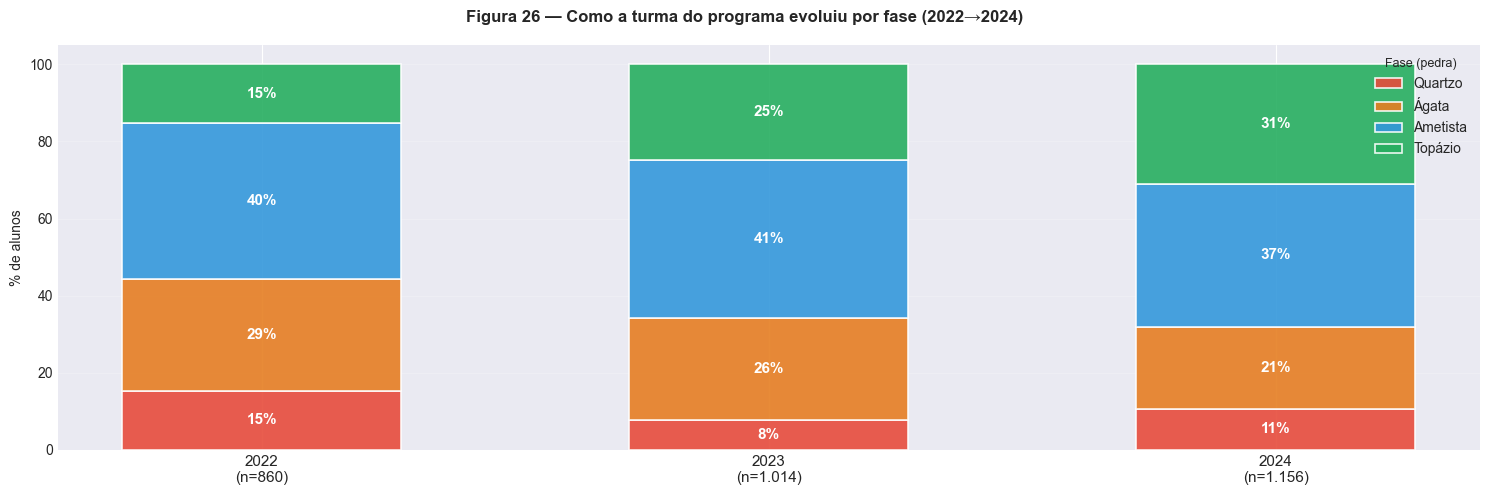

In [137]:

# Figura 26 — barras 100% empilhadas: 3 barras (anos), cada divida nas 4 fases
fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle('Figura 26 — Como a turma do programa evoluiu por fase (2022→2024)',
             fontsize=12, fontweight='bold')

anos_q9 = ['2022', '2023', '2024']
bottom26 = np.zeros(3)

for fase in FASES_ORD_Q9:          # Quartzo → Topázio (de baixo p/ cima = vermelho p/ verde)
    vals = [dist_fases_q9[a].get(fase, 0) for a in anos_q9]
    bars = ax.bar(range(3), vals, bottom=bottom26,
                  color=CORES_FASES_Q9[fase], alpha=0.90,
                  width=0.55, edgecolor='white', linewidth=1.2, label=fase)
    # Rótulo dentro da fatia (só se larga o suficiente)
    for xi, (v, b) in enumerate(zip(vals, bottom26)):
        if v >= 5:
            ax.text(xi, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white')
    bottom26 += vals

ax.set_xticks(range(3))
ax.set_xticklabels(['2022\n(n=860)', '2023\n(n=1.014)', '2024\n(n=1.156)'], fontsize=11)
ax.set_ylabel('% de alunos', fontsize=10)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=10, framealpha=0.85,
          title='Fase (pedra)', title_fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.yaxis.grid(True, alpha=0.20)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


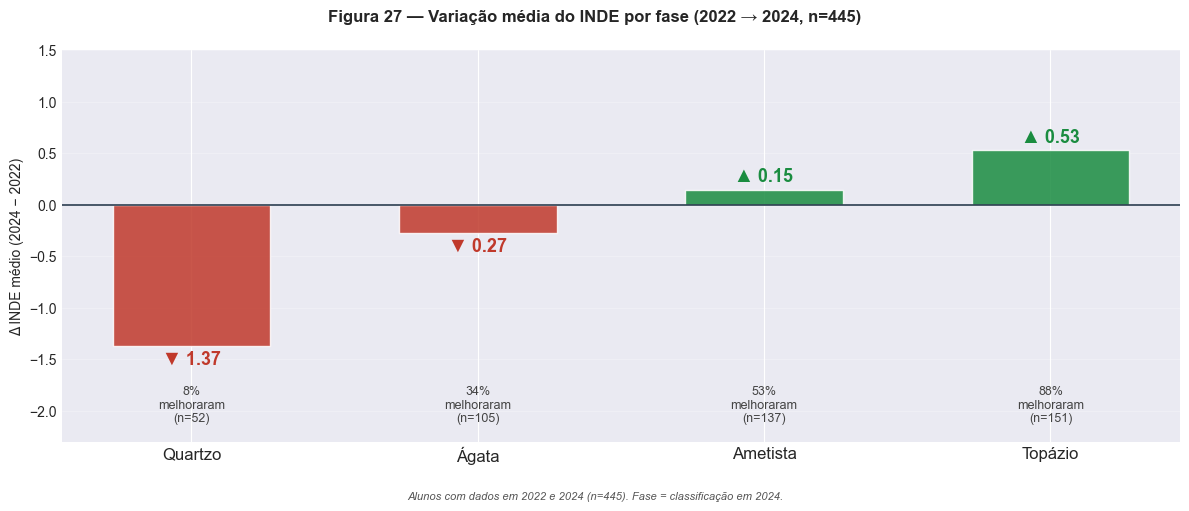

In [138]:

# Figura 27 — variação de INDE por fase (ganho/perda em 2 anos)
fig, ax = plt.subplots(figsize=(12, 4.8))
fig.suptitle('Figura 27 — Variação média do INDE por fase (2022 → 2024, n=445)',
             fontsize=12, fontweight='bold')

for fi, fase in enumerate(FASES_ORD_Q9):
    if fase not in long_resumo.index: continue
    row = long_resumo.loc[fase]
    delta27 = row['delta_med']
    pct27   = row['pct_melhora']
    n27     = int(row['n'])
    cor27   = '#1a8c40' if delta27 > 0 else '#c0392b'

    bar = ax.bar(fi, delta27, color=cor27, alpha=0.85,
                 width=0.55, edgecolor='white', linewidth=1)

    # Valor dentro/fora da barra
    ytext = delta27 + 0.04 if delta27 >= 0 else delta27 - 0.04
    va    = 'bottom' if delta27 >= 0 else 'top'
    sym27 = '▲' if delta27 > 0 else '▼'
    ax.text(fi, ytext, f'{sym27} {abs(delta27):.2f}',
            ha='center', va=va, fontsize=13, fontweight='bold', color=cor27)

    # % que melhorou abaixo do eixo
    ax.text(fi, -1.75, f'{pct27:.0f}%\nmelhoraram\n(n={n27})',
            ha='center', va='top', fontsize=9, color='#444444')

ax.axhline(0, color='#2c3e50', lw=1.2)
ax.set_xticks(range(4))
ax.set_xticklabels(FASES_ORD_Q9, fontsize=12)
ax.set_ylabel('Δ INDE médio (2024 − 2022)', fontsize=10)
ax.set_ylim(-2.3, 1.5)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.text(0.5, -0.04,
         'Alunos com dados em 2022 e 2024 (n=445). Fase = classificação em 2024.',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()


## Pergunta 10 — Insights e Criatividade

**Sugestões estratégicas baseadas em padrões não explorados nas perguntas anteriores**

Três análises complementares revelam dinâmicas que ampliam a compreensão do programa e apontam para ações práticas de alto impacto.


In [139]:

# ── Pergunta 10 — Insights e Criatividade ─────────────────────────────────────
# Variáveis reutilizadas de Q9: FASES_ORD_Q9, CORES_FASES_Q9, _norm_fase,
#   long_q9 (com colunas: fase24, inde22, inde24, delta)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Insight A: INDE médio por fase 2024 (escada) ─────────────────────────────
_d28 = df_2024[['Pedra 2024', 'INDE 2024']].copy()
_d28['fase'] = _d28['Pedra 2024'].apply(_norm_fase)
_d28['inde'] = pd.to_numeric(_d28['INDE 2024'], errors='coerce')
_d28 = _d28.dropna(subset=['fase', 'inde'])
_inde_fase = _d28.groupby('fase')['inde'].mean().reindex(FASES_ORD_Q9)
_n_fase    = _d28.groupby('fase')['inde'].count().reindex(FASES_ORD_Q9)

# ── Insight B: trajetória individual 2022→2024 ───────────────────────────────
_bins_dlt = [-np.inf, -1, 0, 1, np.inf]
_labs_dlt = ['Queda expressiva\n(< −1 pt)', 'Queda leve\n(−1 a 0)',
             'Melhora leve\n(0 a +1 pt)', 'Melhora expressiva\n(> +1 pt)']
_cors_dlt = ['#c0392b', '#e67e22', '#3498db', '#1a8c40']

long_q9['traj'] = pd.cut(long_q9['delta'], bins=_bins_dlt, labels=_labs_dlt)
_traj_cnt  = long_q9['traj'].value_counts().reindex(_labs_dlt)
_traj_inde = long_q9.groupby('traj', observed=False)[['inde22', 'inde24']].mean().reindex(_labs_dlt)

# ── Diagnóstico ───────────────────────────────────────────────────────────────
print("INDE médio por fase (2024):")
for f in FASES_ORD_Q9:
    print(f"  {f}: {_inde_fase.get(f, float('nan')):.2f}  (n={int(_n_fase.get(f, 0))})")

_v28 = _inde_fase.values.astype(float)
_deltas28 = [_v28[i+1] - _v28[i] for i in range(3)]
for i, d in enumerate(_deltas28):
    print(f"  Δ {FASES_ORD_Q9[i]} → {FASES_ORD_Q9[i+1]}: +{d:.2f}")

print(f"\nTrajetória 2022→2024 (n={len(long_q9)} alunos rastreados):")
for lbl, n in _traj_cnt.items():
    pct = n / len(long_q9) * 100
    print(f"  {lbl.replace(chr(10),' ')}: {int(n)} ({pct:.0f}%)")

print(f"\nINDE médio 2022 e 2024 por trajetória:")
print(_traj_inde.round(2).to_string())


INDE médio por fase (2024):
  Quartzo: 5.40  (n=112)
  Ágata: 6.60  (n=225)
  Ametista: 7.53  (n=391)
  Topázio: 8.47  (n=326)
  Δ Quartzo → Ágata: +1.20
  Δ Ágata → Ametista: +0.93
  Δ Ametista → Topázio: +0.93

Trajetória 2022→2024 (n=445 alunos rastreados):
  Queda expressiva (< −1 pt): 58 (13%)
  Queda leve (−1 a 0): 142 (32%)
  Melhora leve (0 a +1 pt): 202 (45%)
  Melhora expressiva (> +1 pt): 43 (10%)

INDE médio 2022 e 2024 por trajetória:
                               inde22  inde24
traj                                         
Queda expressiva\n(< −1 pt)      7.46    5.81
Queda leve\n(−1 a 0)             7.51    7.10
Melhora leve\n(0 a +1 pt)        7.46    7.91
Melhora expressiva\n(> +1 pt)    6.44    7.90


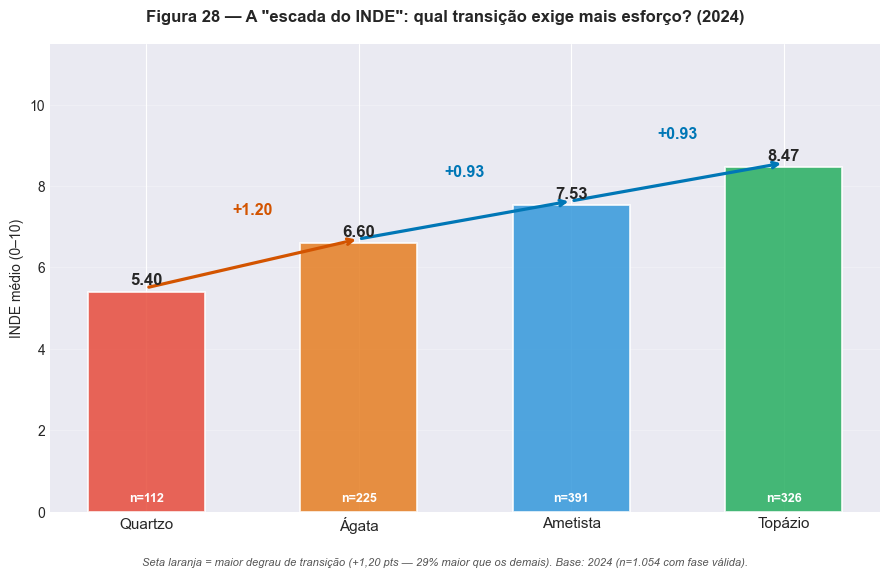

In [140]:

# Figura 28 — A "escada do INDE": qual degrau exige mais esforço?

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.suptitle('Figura 28 — A "escada do INDE": qual transição exige mais esforço? (2024)',
             fontsize=12, fontweight='bold')

_xs28 = np.arange(len(FASES_ORD_Q9))
_v28  = [float(_inde_fase.get(f, np.nan)) for f in FASES_ORD_Q9]
_c28  = [CORES_FASES_Q9[f] for f in FASES_ORD_Q9]
_n28  = [int(_n_fase.get(f, 0)) for f in FASES_ORD_Q9]

ax.bar(_xs28, _v28, color=_c28, alpha=0.85, width=0.55,
       edgecolor='white', linewidth=1.3, zorder=3)

# valor + n dentro/acima de cada barra
for xi, (v, n) in enumerate(zip(_v28, _n28)):
    ax.text(xi, v + 0.17, f'{v:.2f}', ha='center', fontsize=12,
            fontweight='bold', zorder=4)
    ax.text(xi, 0.25, f'n={n}', ha='center', fontsize=9,
            color='white', fontweight='bold', zorder=4)

# setas com Δ entre fases consecutivas
_deltas28 = [_v28[i+1] - _v28[i] for i in range(3)]
_max_d = max(_deltas28)
for i, d in enumerate(_deltas28):
    cor_seta = '#d35400' if d == _max_d else '#0077b6'
    mid_y = max(_v28[i], _v28[i+1]) + 0.7
    ax.annotate('',
                xy=(_xs28[i+1], _v28[i+1] + 0.1),
                xytext=(_xs28[i], _v28[i] + 0.1),
                arrowprops=dict(arrowstyle='->', color=cor_seta, lw=2.3))
    ax.text((_xs28[i] + _xs28[i+1]) / 2, mid_y,
            f'+{d:.2f}', ha='center', fontsize=11.5,
            color=cor_seta, fontweight='bold')

ax.set_xticks(_xs28)
ax.set_xticklabels(FASES_ORD_Q9, fontsize=11)
ax.set_ylabel('INDE médio (0–10)', fontsize=10)
ax.set_ylim(0, 11.5)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

fig.text(0.5, -0.03,
         'Seta laranja = maior degrau de transição (+1,20 pts — 29% maior que os demais). '
         'Base: 2024 (n=1.054 com fase válida).',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()


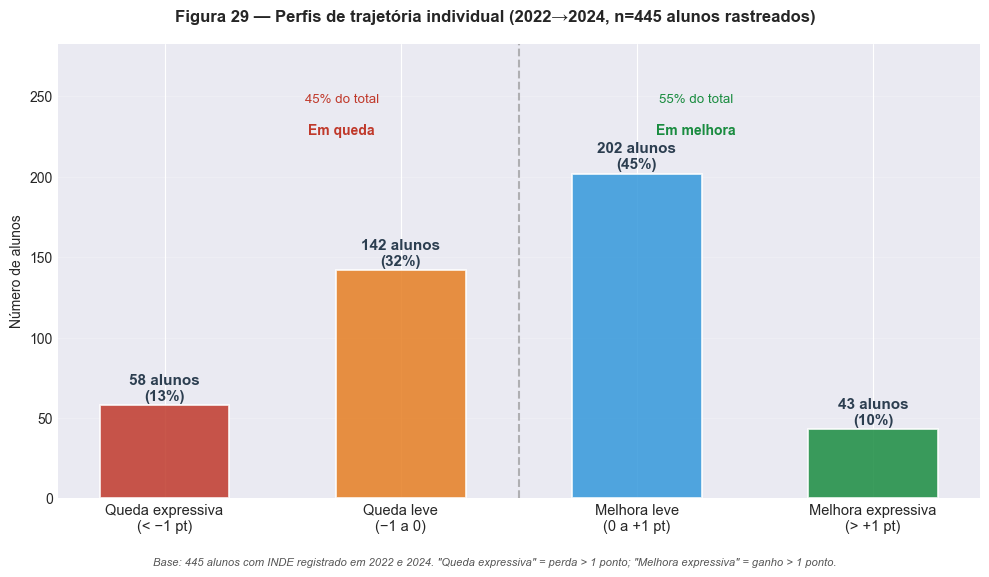

In [141]:

# Figura 29 — Quatro perfis de trajetória: quem avançou, quem recuou?

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.suptitle(f'Figura 29 — Perfis de trajetória individual (2022→2024, n={len(long_q9)} alunos rastreados)',
             fontsize=12, fontweight='bold')

_x29  = np.arange(len(_labs_dlt))
_v29  = _traj_cnt.values.astype(float)
_tot  = _v29.sum()

bars = ax.bar(_x29, _v29, color=_cors_dlt, alpha=0.85,
              width=0.55, edgecolor='white', linewidth=1.3)

for xi, v in enumerate(_v29):
    pct = v / _tot * 100
    ax.text(xi, v + 3, f'{int(v)} alunos\n({pct:.0f}%)',
            ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

# Linha divisória entre queda e melhora
ax.axvline(1.5, color='#888', lw=1.5, linestyle='--', alpha=0.6)
ax.text(0.75, max(_v29) * 1.12, 'Em queda', ha='center', fontsize=10,
        color='#c0392b', fontweight='bold')
ax.text(2.25, max(_v29) * 1.12, 'Em melhora', ha='center', fontsize=10,
        color='#1a8c40', fontweight='bold')

# Percentual total de cada grupo
_pct_queda   = (_v29[0] + _v29[1]) / _tot * 100
_pct_melhora = (_v29[2] + _v29[3]) / _tot * 100
ax.text(0.75, max(_v29) * 1.22, f'{_pct_queda:.0f}% do total',
        ha='center', fontsize=9.5, color='#c0392b')
ax.text(2.25, max(_v29) * 1.22, f'{_pct_melhora:.0f}% do total',
        ha='center', fontsize=9.5, color='#1a8c40')

ax.set_xticks(_x29)
ax.set_xticklabels(_labs_dlt, fontsize=10.5)
ax.set_ylabel('Número de alunos', fontsize=10)
ax.set_ylim(0, max(_v29) * 1.40)
ax.yaxis.grid(True, alpha=0.22)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

fig.text(0.5, -0.03,
         f'Base: {int(_tot)} alunos com INDE registrado em 2022 e 2024. '
         '"Queda expressiva" = perda > 1 ponto; "Melhora expressiva" = ganho > 1 ponto.',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()


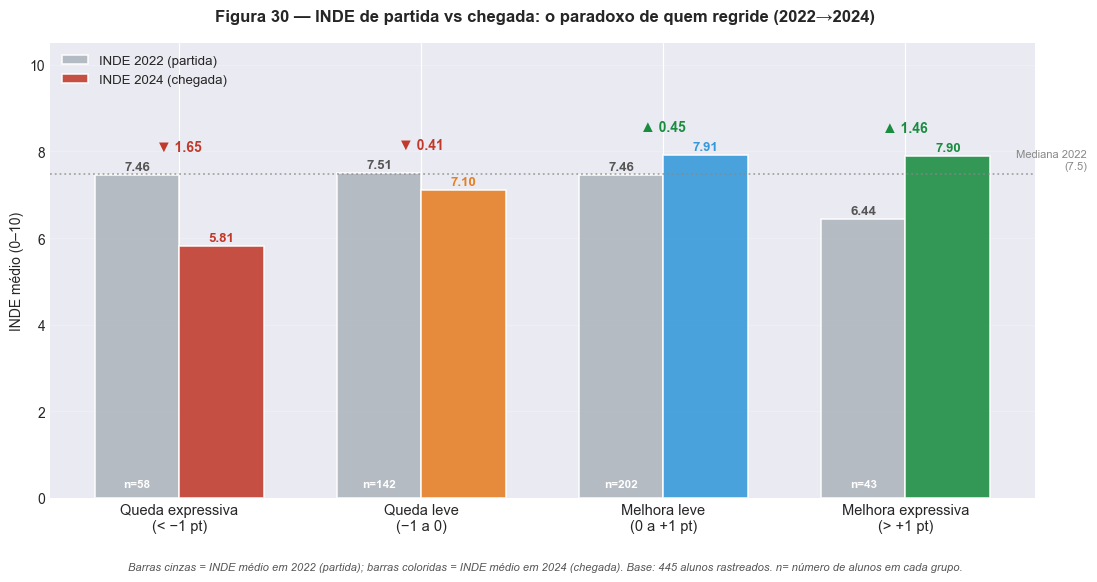

In [142]:

# Figura 30 — O paradoxo da queda: quem regride partiu de onde?

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.suptitle('Figura 30 — INDE de partida vs chegada: o paradoxo de quem regride (2022→2024)',
             fontsize=12, fontweight='bold')

_x30 = np.arange(len(_labs_dlt))
_w30 = 0.35
_v22 = _traj_inde['inde22'].values.astype(float)
_v24 = _traj_inde['inde24'].values.astype(float)
_ns  = _traj_cnt.values.astype(int)

b22 = ax.bar(_x30 - _w30/2, _v22, width=_w30, color='#adb5bd', alpha=0.88,
             edgecolor='white', linewidth=1.2, label='INDE 2022 (partida)')
b24 = ax.bar(_x30 + _w30/2, _v24, width=_w30, color=_cors_dlt, alpha=0.88,
             edgecolor='white', linewidth=1.2, label='INDE 2024 (chegada)')

for xi, (va, vb, n) in enumerate(zip(_v22, _v24, _ns)):
    ax.text(xi - _w30/2, va + 0.12, f'{va:.2f}',
            ha='center', fontsize=9.5, fontweight='bold', color='#555555')
    ax.text(xi + _w30/2, vb + 0.12, f'{vb:.2f}',
            ha='center', fontsize=9.5, fontweight='bold', color=_cors_dlt[xi])
    # delta acima das barras
    delta_v = vb - va
    sym = '▲' if delta_v > 0 else '▼'
    cor_sym = '#1a8c40' if delta_v > 0 else '#c0392b'
    ax.text(xi, max(va, vb) + 0.55, f'{sym} {abs(delta_v):.2f}',
            ha='center', fontsize=10, fontweight='bold', color=cor_sym)
    # n dentro da barra 2022 (cinza)
    ax.text(xi - _w30/2, 0.25, f'n={n}',
            ha='center', fontsize=8.5, color='white', fontweight='bold')

# Linha de referência: mediana 2022
_med_ref = float(long_q9['inde22'].median())
ax.axhline(_med_ref, color='#888', lw=1.3, linestyle=':', alpha=0.7)
ax.text(3.75, _med_ref + 0.08, f'Mediana 2022\n({_med_ref:.1f})',
        fontsize=8, color='#888', va='bottom', ha='right')

ax.set_xticks(_x30)
ax.set_xticklabels(_labs_dlt, fontsize=10.5)
ax.set_ylabel('INDE médio (0–10)', fontsize=10)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=9.5, framealpha=0.85, loc='upper left')
ax.yaxis.grid(True, alpha=0.22)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

fig.text(0.5, -0.04,
         'Barras cinzas = INDE médio em 2022 (partida); barras coloridas = INDE médio em 2024 (chegada). '
         f'Base: {len(long_q9)} alunos rastreados. n= número de alunos em cada grupo.',
         ha='center', fontsize=8, color='#555555', style='italic')
plt.tight_layout()
plt.show()
